# Example-19: Effects of BPM calibration errors on twiss parameters

In [1]:
# In this example effects of BPM (linear) calibration errors on observed twiss parameters (BPM frame) are investigated
# With BPM calibration errors, observed transverse coordinates are 
# qx_bpm = gxx qx + gxy qy
# qy_bpm = gyy qy + gyx gx
# gxx and gyy are scale errors
# gxy and gyx are crosstalk erros
# Effect of calibration errors can be described by a symplectic matrix
# It can be used to transform beam frame twiss parameters to BPM frame twiss parameters (or observed twiss parameters)
# In coupled case phase advance between BPMs is also effected by BPM calibration errors
# In this example twiss parameters (and invarinats) are estimated by several methods
# Estimated parameters are compared with corresponding bpm and beam frame parameters
# TbT data without noise is used for illustration
# Calibration errors are assumed to be IID with <gxx> = <gyy> = 1 and <gxy> = <gyx> = 0

## Import & definitions

In [2]:
# Import

import sys
sys.path.append('..')

from torch import Tensor
from numpy import ndarray as Array

import numpy
import torch

from harmonica.util import mod

from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.decomposition import Decomposition
from harmonica.model import Model
from harmonica.table import Table
from harmonica.twiss import Twiss

from harmonica.parameterization import twiss_phase_advance
from harmonica.parameterization import normal_to_wolski
from harmonica.parameterization import wolski_to_cs
from harmonica.parameterization import invariant
from harmonica.parameterization import parametric_normal

from harmonica.statistics import root_mean_square

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

In [3]:
# Set data type and device

dtype = torch.float64
device = 'cpu'

In [4]:
# Phase advance computation

def rotation_block(angle:Tensor) -> Tensor:
    c, s = angle.cos(), angle.sin()
    return torch.stack([*map(torch.stack, [[c, +s], [-s, c]])])

def rotation(*angles:Tensor) -> Tensor:
    return torch.block_diag(*torch.func.vmap(rotation_block)(torch.stack(angles)))

def advance(n:Tensor, m:Tensor) -> tuple[Tensor, Tensor]:
    d = len(n) // 2
    i = torch.arange(d, dtype=torch.int64, device=n.device)
    k = m @ n
    f = torch.arctan2(k[2*i, 2*i + 1], k[2*i, 2*i])
    return f, k @ rotation(*(-f))

In [5]:
# BPM calibration matrix

# M12 -> G2 @ M12 @ G1^-1

# x = gxx x + gxy y
# y = gyy y + gyx y

def calibration(gxx:Tensor, gxy:Tensor, gyx:Tensor, gyy:Tensor) -> Tensor:
    
    i = torch.tensor(1.0, dtype=dtype, device=device)    
    o = torch.tensor(0.0, dtype=dtype, device=device)
    
    return torch.stack([torch.stack([gxx,                       o, gxy,                       o]),
                        torch.stack([  o, gyy/(gxx*gyy - gxy*gyx),   o, gyx/(gxy*gyx - gxx*gyy)]),
                        torch.stack([gyx,                       o, gyy,                       o]),
                        torch.stack([  o, gxy/(gxy*gyx - gxx*gyy),   o, gxx/(gxx*gyy - gxy*gyx)])])

## Model setup

In [6]:
# Load lodel

model = Model(path='../config/skif.yaml', model='uncoupled', dtype=dtype, device=device)

# Number of monitor and virtual locations
# Calibration errors are added to monitor locations, normal and skew quadrupole errors are added to virtual locations

print(model.monitor_count)
print(model.virtual_count)

224
753


In [7]:
# Set full TbT length (full length is used for frequency estimation)

length:int = 2*2**10

In [8]:
# Set window function (frequency estimation) 

window:Window = Window.from_cosine(length, 2.0, dtype=dtype, device=device)

In [9]:
# Set data containers

tbt_x:Data = Data(model.monitor_count, window)
tbt_y:Data = Data(model.monitor_count, window)

In [10]:
# Set frequency containers

f_x:Frequency = Frequency(tbt_x)
f_y:Frequency = Frequency(tbt_y)

In [11]:
# Set decomposition containers

d_x:Decomposition = Decomposition(tbt_x)
d_y:Decomposition = Decomposition(tbt_y)

In [12]:
# Initialize zero focusing errors for all locations

kn:Tensor = torch.zeros(model.size, dtype=dtype, device=device)
ks:Tensor = torch.zeros(model.size, dtype=dtype, device=device)

In [13]:
# Set weak focusing errors at all virtual locations

kn[model.virtual_index] = 0.5E-3*torch.randn(model.virtual_count, dtype=dtype, device=device)
ks[model.virtual_index] = 0.5E-3*torch.randn(model.virtual_count, dtype=dtype, device=device)

In [14]:
# Compute twiss parametes with quadrupole errors (beam frame twiss parameters)

model.make_error(kn, ks, length=0.0)
model.make_transport(error=True, exact=False)
model.make_twiss()

True

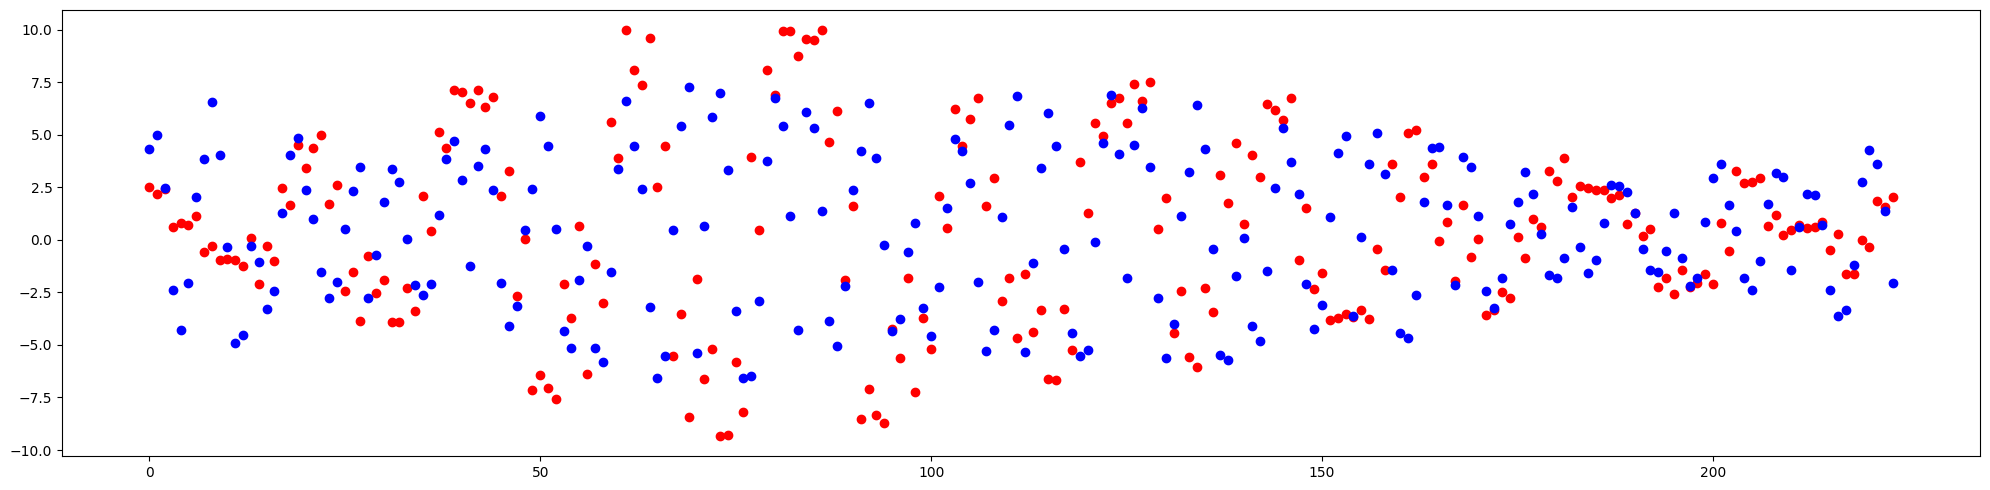

4.36
3.52


In [15]:
# Compare with model

_, bx, _, by = model.out_cs[model.monitor_index].T

plt.figure(figsize=(20, 5))
plt.scatter(range(model.monitor_count), 100*(((model.bx[model.monitor_index] - bx)/model.bx[model.monitor_index])).cpu().numpy(), color='red')
plt.scatter(range(model.monitor_count), 100*(((model.by[model.monitor_index] - by)/model.by[model.monitor_index])).cpu().numpy(), color='blue')
plt.tight_layout()
plt.show()

print(f'{100*root_mean_square((model.bx[model.monitor_index] - bx)/model.bx[model.monitor_index]).item():.2f}')
print(f'{100*root_mean_square((model.by[model.monitor_index] - by)/model.by[model.monitor_index]).item():.2f}')

In [16]:
# Compute phase advanced between monitors  (beam frame twiss parameters)

nux, nuy = model.out_tune_fractional
mux, muy = mod(model.out_advance.roll(1, 0).cumsum(0)[model.monitor_index].T, 2.0*numpy.pi)
mux, _ = Decomposition.phase_adjacent(nux, mux)
muy, _ = Decomposition.phase_adjacent(nuy, muy)

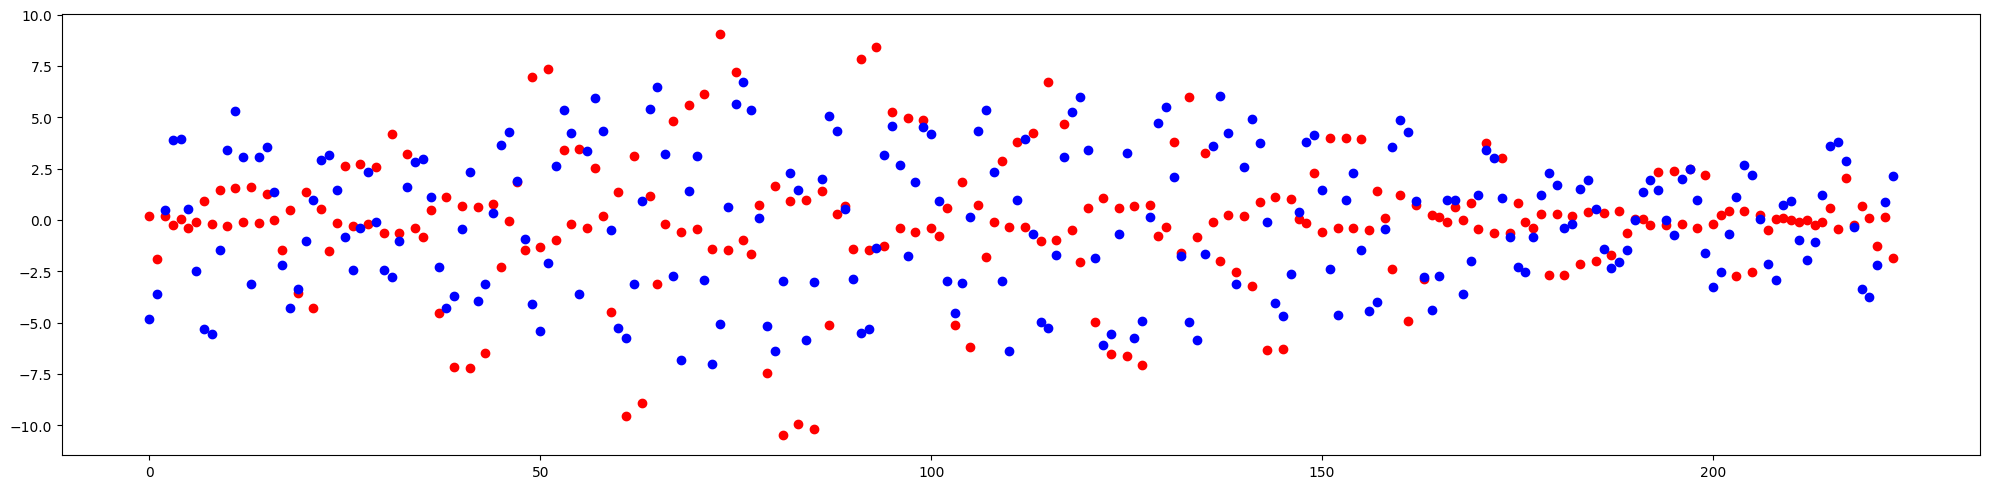

3.13
3.34


In [17]:
# Compare with model

plt.figure(figsize=(20, 5))
plt.scatter(range(model.monitor_count), 100*((model.monitor_phase_x - mux)/model.monitor_phase_x).cpu().numpy(), color='red')
plt.scatter(range(model.monitor_count), 100*((model.monitor_phase_y - muy)/model.monitor_phase_y).cpu().numpy(), color='blue')
plt.tight_layout()
plt.show()

print(f'{100*root_mean_square((model.monitor_phase_x - mux)/model.monitor_phase_x).item():.2f}')
print(f'{100*root_mean_square((model.monitor_phase_y - muy)/model.monitor_phase_y).item():.2f}')

In [18]:
# Set calibration errors

g_xx = 1.0 + 2.5E-2*torch.randn(model.monitor_count, dtype=dtype, device=device)
g_xy = 0.0 + 5.0E-3*torch.randn(model.monitor_count, dtype=dtype, device=device)
g_yx = 0.0 + 5.0E-3*torch.randn(model.monitor_count, dtype=dtype, device=device)
g_yy = 1.0 + 2.5E-2*torch.randn(model.monitor_count, dtype=dtype, device=device)

In [19]:
# Compute calibration matrices ((gxx, gxy), (gyx, gyy)) for each bpm (qx, px, qy, py)

bpm = torch.vmap(calibration)(g_xx, g_xy, g_yx, g_yy)

print(bpm.shape)

torch.Size([224, 4, 4])


## Twiss parameters

In [20]:
# Compute transformed twiss parameters

# Given a normalization matrix in beam frame N and a transformation matrix to bpm frame M_bpm
# Normalizaton matrix N_bpm in bpm frame and phase advance can be computed from M_bpm @ N

normal = model.out_normal[model.monitor_index]
advance_bpm, normal_bpm = torch.vmap(advance)(normal, bpm)

In [21]:
# Set normalization matrix elements

n11 = normal[:, 0, 0]
n12 = normal[:, 0, 1]
n13 = normal[:, 0, 2]
n14 = normal[:, 0, 3]

n21 = normal[:, 1, 0]
n22 = normal[:, 1, 1]
n23 = normal[:, 1, 2]
n24 = normal[:, 1, 3]

n31 = normal[:, 2, 0]
n32 = normal[:, 2, 1]
n33 = normal[:, 2, 2]
n34 = normal[:, 2, 3]

n41 = normal[:, 3, 0]
n42 = normal[:, 3, 1]
n43 = normal[:, 3, 2]
n44 = normal[:, 3, 3]

n11_bpm = normal_bpm[:, 0, 0]
n12_bpm = normal_bpm[:, 0, 1]
n13_bpm = normal_bpm[:, 0, 2]
n14_bpm = normal_bpm[:, 0, 3]

n21_bpm = normal_bpm[:, 1, 0]
n22_bpm = normal_bpm[:, 1, 1]
n23_bpm = normal_bpm[:, 1, 2]
n24_bpm = normal_bpm[:, 1, 3]

n31_bpm = normal_bpm[:, 2, 0]
n32_bpm = normal_bpm[:, 2, 1]
n33_bpm = normal_bpm[:, 2, 2]
n34_bpm = normal_bpm[:, 2, 3]

n41_bpm = normal_bpm[:, 3, 0]
n42_bpm = normal_bpm[:, 3, 1]
n43_bpm = normal_bpm[:, 3, 2]
n44_bpm = normal_bpm[:, 3, 3]

In [22]:
# Transform back to beam frame and compare with initial values

advance_test, normal_test = torch.vmap(advance)(normal_bpm, bpm.inverse())

print(torch.allclose(advance_test, -advance_bpm))
print(torch.allclose(normal_test, normal))

True
True


In [23]:
# Beta beating (beam and bpm frames)

_, bx_bpm, _, by_bpm = torch.stack([wolski_to_cs(matrix) for matrix in normal_to_wolski(normal_bpm)]).T

print(f'{100*root_mean_square((model.bx[model.monitor_index] - bx)/model.bx[model.monitor_index]).item():.2f}')
print(f'{100*root_mean_square((model.by[model.monitor_index] - by)/model.by[model.monitor_index]).item():.2f}')
print()

print(f'{100*root_mean_square((model.bx[model.monitor_index] - bx_bpm)/model.bx[model.monitor_index]).item():.2f}')
print(f'{100*root_mean_square((model.by[model.monitor_index] - by_bpm)/model.by[model.monitor_index]).item():.2f}')
print()

4.36
3.52

5.98
6.26



In [24]:
# Phase beating (beam and bpm frames)

mux_bpm, muy_bpm = mod(-advance_bpm  + torch.stack([mux, muy]).T + advance_bpm.roll(-1, 0), 2*numpy.pi).T

print(f'{100*root_mean_square((model.monitor_phase_x - mux)/model.monitor_phase_x).item():.2f}')
print(f'{100*root_mean_square((model.monitor_phase_y - muy)/model.monitor_phase_y).item():.2f}')
print()

print(f'{100*root_mean_square((model.monitor_phase_x - mux_bpm)/model.monitor_phase_x).item():.2f}')
print(f'{100*root_mean_square((model.monitor_phase_y - muy_bpm)/model.monitor_phase_y).item():.2f}')
print()

3.13
3.34

3.12
3.33



In [25]:
# Compute phase advance using full transport matrices

probe = model.monitor_index
first, *other = model.monitor_index
other.append(first + model.size)

mijs = torch.stack([model.matrix_transport(i, j) for i, j in zip(probe, other)])
mijs_bpms = torch.vmap(lambda gi, mij, gj: gj @ mij @ gi.inverse())(bpm, mijs, bpm.roll(-1, 0))

advance_other, normal_other = torch.vmap(advance)(normal_bpm, mijs_bpms)

print(torch.allclose(torch.stack([mux_bpm, muy_bpm]).T, advance_other))
print(torch.allclose(normal_bpm, normal_other.roll(1, 0)))

True
True


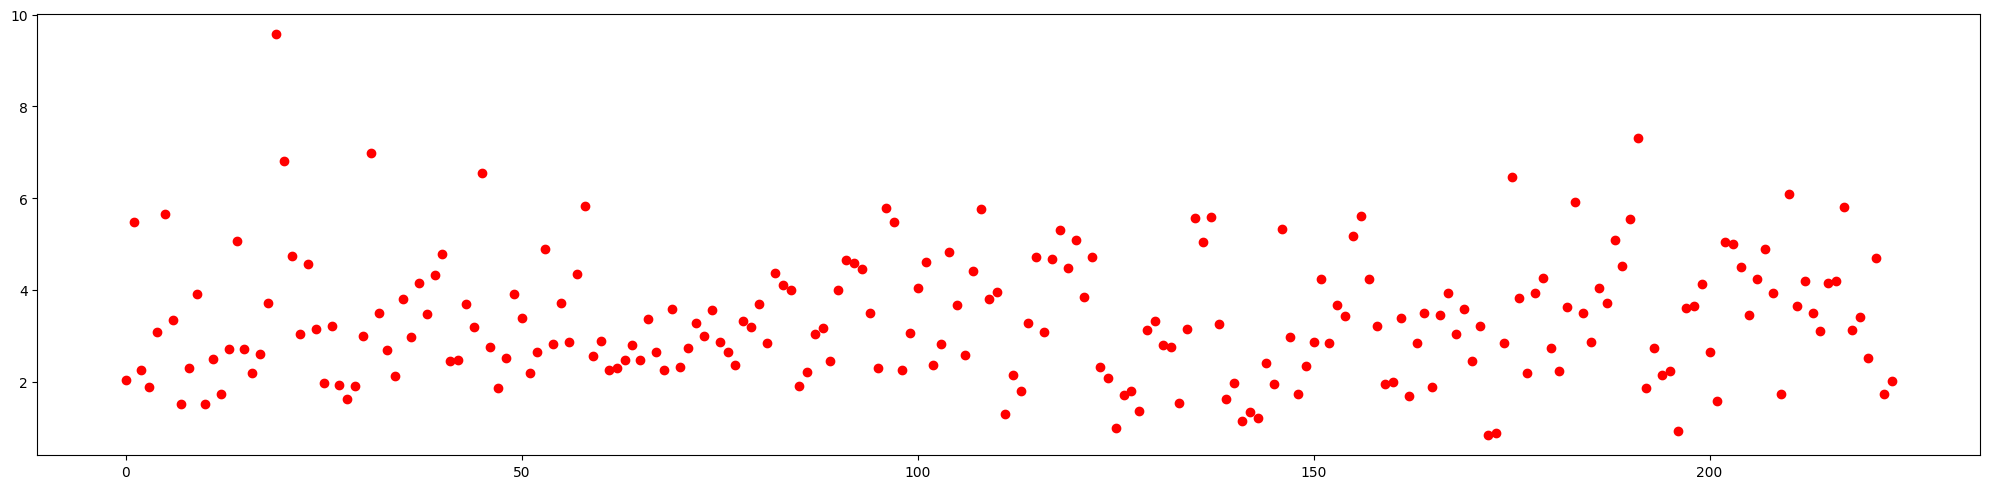

In [26]:
# Compare transport norm change of transport matrices

plt.figure(figsize=(20, 5))
plt.scatter(range(model.monitor_count), 100*torch.linalg.matrix_norm(mijs - mijs_bpms)/torch.linalg.matrix_norm(mijs).cpu().numpy(), color='red')
plt.tight_layout()
plt.show()

In [27]:
# While there is an observable phase advance change due to interaction of coupling with calibration errors
# Frequencies are expected to remain invariant

print(model.out_tune_fractional)
print(mod(torch.stack([mux, muy]).sum(-1)/(2*torch.pi), 1))
print(mod(torch.stack([mux_bpm, muy_bpm]).sum(-1)/(2*torch.pi), 1))

tensor([0.7944, 0.8414], dtype=torch.float64)
tensor([0.7944, 0.8414], dtype=torch.float64)
tensor([0.7944, 0.8414], dtype=torch.float64)


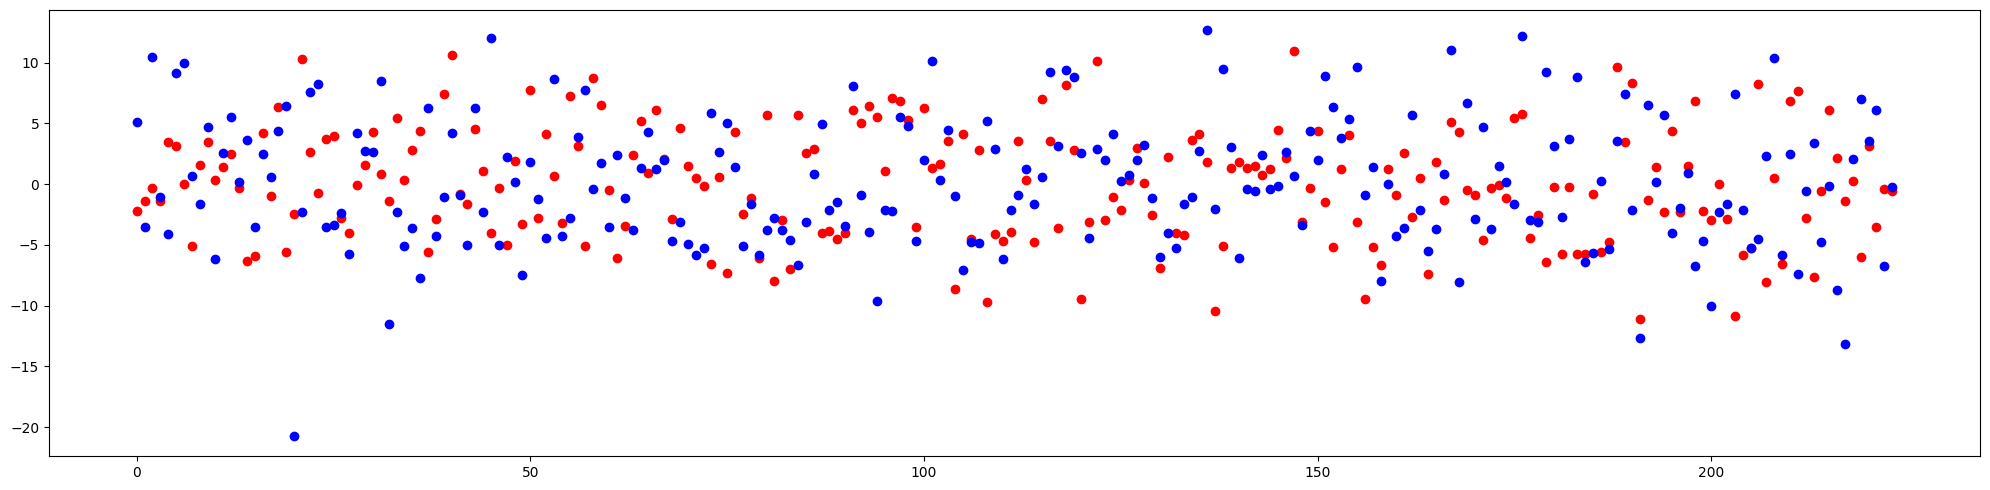

4.63
5.32



In [28]:
# Plot beta function difference (bmp vs beam frames)

plt.figure(figsize=(20, 5))
plt.scatter(range(model.monitor_count), 100*((bx - bx_bpm)/bx).cpu().numpy(), color='red')
plt.scatter(range(model.monitor_count), 100*((by - by_bpm)/by).cpu().numpy(), color='blue')
plt.tight_layout()
plt.show()

print(f'{100*root_mean_square((bx - bx_bpm)/bx).item():.2f}')
print(f'{100*root_mean_square((by - by_bpm)/by).item():.2f}')
print()

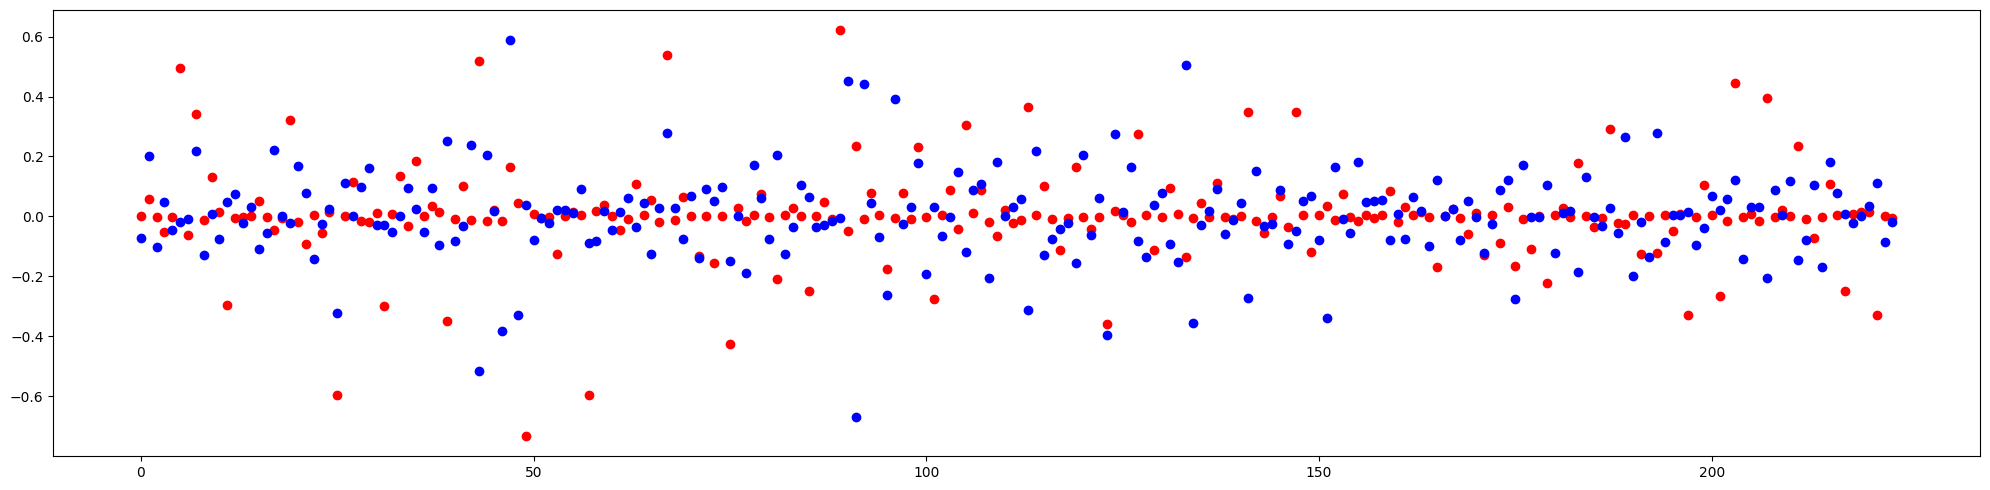

0.16
0.15



In [29]:
# Plot phase advance difference (bmp vs beam frames)

plt.figure(figsize=(20, 5))
plt.scatter(range(model.monitor_count), 100*((mux - mux_bpm)/mux).cpu().numpy(), color='red')
plt.scatter(range(model.monitor_count), 100*((muy - muy_bpm)/muy).cpu().numpy(), color='blue')
plt.tight_layout()
plt.show()

print(f'{100*root_mean_square((mux - mux_bpm)/mux).item():.2f}')
print(f'{100*root_mean_square((muy - muy_bpm)/muy).item():.2f}')
print()

In [30]:
# Transformation of normalization matrix elements from beam to bpm frame

def transform(n, gxx, gxy, gyx, gyy):
    m = torch.zeros_like(n)
    m[0, 0] = (gxx * n[0, 0] + gxy * n[2, 0]) * torch.sqrt(1 + (gxy**2 * n[2, 1]**2) / (gxx * n[0, 0] + gxy * n[2, 0])**2)
    m[0, 2] = (gxx * gyx * (n[0, 2]**2 + n[0, 3]**2) + (gxy * gyx + gxx * gyy) * n[0, 2] * n[2, 2] + gxy * gyy * n[2, 2]**2) / ((gyx * n[0, 2] + gyy * n[2, 2]) * torch.sqrt(1 + (gyx**2 * n[0, 3]**2) / (gyx * n[0, 2] + gyy * n[2, 2])**2))
    m[0, 3] = ((-gxy * gyx + gxx * gyy) * n[0, 3] * n[2, 2]) / ((gyx * n[0, 2] + gyy * n[2, 2]) * torch.sqrt(1 + (gyx**2 * n[0, 3]**2) / (gyx * n[0, 2] + gyy * n[2, 2])**2))
    m[1, 0] = (gxx * n[0, 0] * (gyy * n[1, 0] - gyx * n[3, 0]) + gxy * (gyy * (n[1, 0] * n[2, 0] + n[1, 1] * n[2, 1]) - gyx * (n[2, 0] * n[3, 0] + n[2, 1] * n[3, 1]))) / ((-gxy * gyx + gxx * gyy) * (gxx * n[0, 0] + gxy * n[2, 0]) * torch.sqrt(1 + (gxy**2 * n[2, 1]**2) / (gxx * n[0, 0] + gxy * n[2, 0])**2))
    m[1, 1] = (gxx * n[0, 0] * (gyy * n[1, 1] - gyx * n[3, 1]) + gxy * (gyy * (n[1, 1] * n[2, 0] - n[1, 0] * n[2, 1]) + gyx * (n[2, 1] * n[3, 0] - n[2, 0] * n[3, 1]))) / ((-gxy * gyx + gxx * gyy) * (gxx * n[0, 0] + gxy * n[2, 0]) * torch.sqrt(1 + (gxy**2 * n[2, 1]**2) / (gxx * n[0, 0] + gxy * n[2, 0])**2))
    m[1, 2] = (-gyy**2 * n[1, 2] * n[2, 2] - gyx * gyy * (n[0, 2] * n[1, 2] + n[0, 3] * n[1, 3] - n[2, 2] * n[3, 2]) + gyx**2 * (n[0, 2] * n[3, 2] + n[0, 3] * n[3, 3])) / ((gxy * gyx - gxx * gyy) * (gyx * n[0, 2] + gyy * n[2, 2]) * torch.sqrt(1 + (gyx**2 * n[0, 3]**2) / (gyx * n[0, 2] + gyy * n[2, 2])**2))
    m[1, 3] = (-gyy**2 * n[1, 3] * n[2, 2] + gyx**2 * (-n[0, 3] * n[3, 2] + n[0, 2] * n[3, 3]) + gyx * gyy * (n[0, 3] * n[1, 2] - n[0, 2] * n[1, 3] + n[2, 2] * n[3, 3])) / ((gxy * gyx - gxx * gyy) * (gyx * n[0, 2] + gyy * n[2, 2]) * torch.sqrt(1 + (gyx**2 * n[0, 3]**2) / (gyx * n[0, 2] + gyy * n[2, 2])**2))
    m[2, 0] = ((gxx * n[0, 0] + gxy * n[2, 0]) * (gyx * n[0, 0] + gyy * n[2, 0]) + gxy * gyy * n[2, 1]**2) / ((gxx * n[0, 0] + gxy * n[2, 0]) * torch.sqrt(1 + (gxy**2 * n[2, 1]**2) / (gxx * n[0, 0] + gxy * n[2, 0])**2))
    m[2, 1] = ((-gxy * gyx + gxx * gyy) * n[0, 0] * n[2, 1]) / ((gxx * n[0, 0] + gxy * n[2, 0]) * torch.sqrt(1 + (gxy**2 * n[2, 1]**2) / (gxx * n[0, 0] + gxy * n[2, 0])**2))
    m[2, 2] = (gyx * n[0, 2] + gyy * n[2, 2]) * torch.sqrt(1 + (gyx**2 * n[0, 3]**2) / (gyx * n[0, 2] + gyy * n[2, 2])**2)
    m[3, 0] = (-gxy**2 * (n[1, 0] * n[2, 0] + n[1, 1] * n[2, 1]) + gxx**2 * n[0, 0] * n[3, 0] + gxx * gxy * (-n[0, 0] * n[1, 0] + n[2, 0] * n[3, 0] + n[2, 1] * n[3, 1])) / ((-gxy * gyx + gxx * gyy) * (gxx * n[0, 0] + gxy * n[2, 0]) * torch.sqrt(1 + (gxy**2 * n[2, 1]**2) / (gxx * n[0, 0] + gxy * n[2, 0])**2))
    m[3, 1] = (-gxy * (gxy * (n[1, 1] * n[2, 0] - n[1, 0] * n[2, 1]) + gxx * (n[0, 0] * n[1, 1] + n[2, 1] * n[3, 0])) + gxx * (gxx * n[0, 0] + gxy * n[2, 0]) * n[3, 1]) / ((-gxy * gyx + gxx * gyy) * (gxx * n[0, 0] + gxy * n[2, 0]) * torch.sqrt(1 + (gxy**2 * n[2, 1]**2) / (gxx * n[0, 0] + gxy * n[2, 0])**2))
    m[3, 2] = (gxy * (gyx * (n[0, 2] * n[1, 2] + n[0, 3] * n[1, 3]) + gyy * n[1, 2] * n[2, 2]) - gxx * ((gyx * n[0, 2] + gyy * n[2, 2]) * n[3, 2] + gyx * n[0, 3] * n[3, 3])) / ((gxy * gyx - gxx * gyy) * (gyx * n[0, 2] + gyy * n[2, 2]) * torch.sqrt(1 + (gyx**2 * n[0, 3]**2) / (gyx * n[0, 2] + gyy * n[2, 2])**2))
    m[3, 3] = (gxy * (gyx * (-n[0, 3] * n[1, 2] + n[0, 2] * n[1, 3]) + gyy * n[1, 3] * n[2, 2]) + gxx * (gyx * n[0, 3] * n[3, 2] - (gyx * n[0, 2] + gyy * n[2, 2]) * n[3, 3])) / ((gxy * gyx - gxx * gyy) * (gyx * n[0, 2] + gyy * n[2, 2]) * torch.sqrt(1 + (gyx**2 * n[0, 3]**2) / (gyx * n[0, 2] + gyy * n[2, 2])**2))
    return m

In [31]:
# Compare normalization matrices with analytical expression 

print((normal_bpm - torch.vmap(transform)(normal, g_xx, g_xy, g_yx, g_yy)).norm().max())
print(torch.allclose(normal_bpm, torch.vmap(transform)(normal, g_xx, g_xy, g_yx, g_yy)))

tensor(1.2232e-14, dtype=torch.float64)
True


In [32]:
# Transformation of phase advance

def transform(n, gxx, gxy, gyx, gyy):
    fx = torch.atan2((gxy*n[2, 1]), (gxx*n[0, 0] + gxy*n[2, 0]))
    fy = torch.atan2((gyx*n[0, 3]), (gyx*n[0, 2] + gyy*n[2, 2]))
    return torch.stack([fx, fy])

In [33]:
# Compare phase advances with analytical expressions

print((advance_bpm - torch.vmap(transform)(normal, g_xx, g_xy, g_yx, g_yy)).norm().max())
print(torch.allclose(advance_bpm, torch.vmap(transform)(normal, g_xx, g_xy, g_yx, g_yy)))

tensor(5.9945e-15, dtype=torch.float64)
True


## Harmonic decomposition

In [34]:
# Generate TbT signals at monitors (beam frame)

point = torch.tensor([0.00075, 0.0, 0.000375, 0.0], dtype=dtype, device=device)
qx, px, qy, py =  model.make_trajectory(point, length, error=True, transport=True)[model.monitor_index].permute(-1, 0, 1)

print(qx.shape)
print(px.shape)
print(qy.shape)
print(py.shape)

torch.Size([224, 2048])
torch.Size([224, 2048])
torch.Size([224, 2048])
torch.Size([224, 2048])


In [35]:
# Generate TbT signals at monitors (bpm frame)
# Note, if noise is used, it should be add to bpm frame coordinates

qx_bpm, px_bpm, qy_bpm, py_bpm = (bpm @ torch.stack([qx, px, qy, py]).permute(1, 0, -1)).permute(1, 0, -1)

print(qx_bpm.shape)
print(px_bpm.shape)
print(qy_bpm.shape)
print(py_bpm.shape)

torch.Size([224, 2048])
torch.Size([224, 2048])
torch.Size([224, 2048])
torch.Size([224, 2048])


In [36]:
# Compare invariants (beam vs bpm frames)
# Note, invariants are expected to be the same

ix, iy = torch.vmap(invariant)(normal, torch.stack([qx, px, qy, py]).permute(1, -1, 0)).swapaxes(0, 1).mean(-1)
ix_bpm, iy_bpm = torch.vmap(invariant)(normal_bpm, torch.stack([qx_bpm, px_bpm, qy_bpm, py_bpm]).permute(1, -1, 0)).swapaxes(0, 1).mean(-1)

print(torch.allclose(ix, ix_bpm))
print(torch.allclose(iy, iy_bpm))

True
True


In [37]:
# Perform harmonic decmposition of TbT data without calibration errors

In [38]:
# Set data containers

tbt_x.data = qx.clone()
tbt_x.work = qx.clone()
tbt_x.reset()

tbt_y.data = qy.clone()
tbt_y.work = qy.clone()
tbt_y.reset()

In [39]:
# Compute frequencies (horizontal and vertical)

tbt_x.window_remove_mean()
tbt_x.window_apply()
f_x('parabola')
tbt_x.reset()

tbt_y.window_remove_mean()
tbt_y.window_apply()
f_y('parabola')
tbt_y.reset()

nux, sigma_nux = 1.0 - f_x.frequency.mean(),  f_x.frequency.std()
nuy, sigma_nuy = 1.0 - f_y.frequency.mean(),  f_y.frequency.std()

In [40]:
# Compute amplitudes and phases (horizontal and vertical)

axx, _, _ = d_x.harmonic_amplitude(nux, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fxx, _, _ = d_x.harmonic_phase(nux, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
axy, _, _ = d_x.harmonic_amplitude(nuy, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fxy, _, _ = d_x.harmonic_phase(nuy, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
ayy, _, _ = d_y.harmonic_amplitude(nuy, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fyy, _, _ = d_y.harmonic_phase(nuy, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
ayx, _, _ = d_y.harmonic_amplitude(nux, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fyx, _, _ = d_y.harmonic_phase(nux, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)

In [41]:
# Check reconstruction

# qx(n) = axx cos(2 pi nux n + fxx) + axy cos(2 pi nuy n + fxy)
# qy(n) = ayy cos(2 pi nuy n + fyy) + ayx cos(2 pi nux n + fyx)

t = torch.linspace(0, length - 1, length, dtype=dtype, device=device)

print(torch.allclose(qx, axx.reshape(-1, 1)*(2*torch.pi*nux*t + fxx.reshape(-1, 1)).cos() + axy.reshape(-1, 1)*(2*torch.pi*nuy*t + fxy.reshape(-1, 1)).cos()))
print(torch.allclose(qy, ayy.reshape(-1, 1)*(2*torch.pi*nuy*t + fyy.reshape(-1, 1)).cos() + ayx.reshape(-1, 1)*(2*torch.pi*nux*t + fyx.reshape(-1, 1)).cos()))

True
True


In [42]:
# Set table

table = Table(model.monitor_name,
              nux, nuy,
              axx, ayy, fxx, fyy,
              x=qx,
              y=qy,
              dtype=dtype,
              device=device)

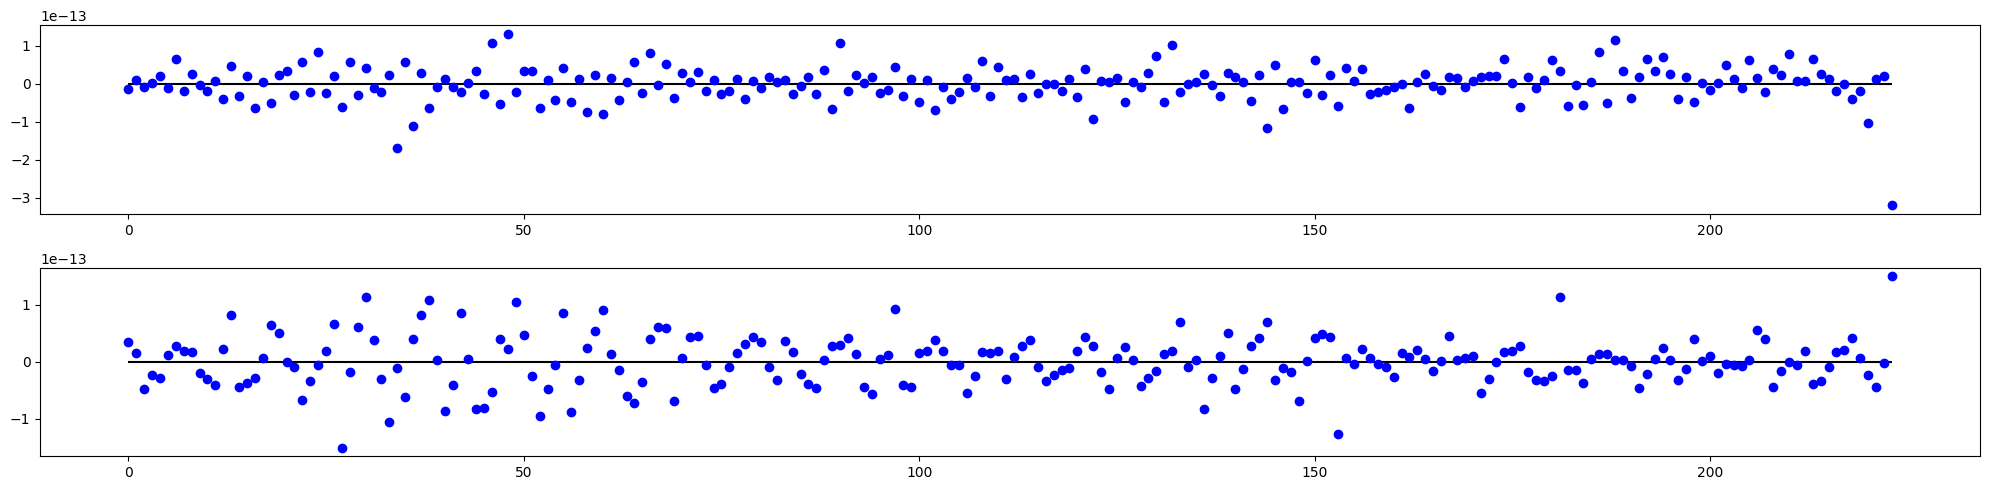

In [43]:
# Compare phase advance

plt.figure(figsize=(20, 5))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), (mux - table.phase_x.cpu().numpy()), fmt=' ', marker='o', color='blue')
ax.hlines(0, 0, model.monitor_count - 1, colors='black')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), (muy - table.phase_y.cpu().numpy()), fmt=' ', marker='o', color='blue')
ax.hlines(0, 0, model.monitor_count - 1, colors='black')
plt.tight_layout()
plt.show()

In [44]:
# Perform harmonic decmposition of TbT data wit calibration errors

In [45]:
# Set data containers

tbt_x.data = qx_bpm.clone()
tbt_x.work = qx_bpm.clone()
tbt_x.reset()

tbt_y.data = qy_bpm.clone()
tbt_y.work = qy_bpm.clone()
tbt_y.reset()

In [46]:
# Compute frequencies (horizontal and vertical)

tbt_x.window_remove_mean()
tbt_x.window_apply()
f_x('parabola')
tbt_x.reset()

tbt_y.window_remove_mean()
tbt_y.window_apply()
f_y('parabola')
tbt_y.reset()

nux_bpm, sigma_nux = 1.0 - f_x.frequency.mean(),  f_x.frequency.std()
nuy_bpm, sigma_nuy = 1.0 - f_y.frequency.mean(),  f_y.frequency.std()

print(torch.allclose(nux, nux_bpm))
print(torch.allclose(nuy, nuy_bpm))

True
True


In [47]:
# Compute amplitudes and phases (horizontal and vertical)

axx_bpm, sigma_ax, _ = d_x.harmonic_amplitude(nux_bpm, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fxx_bpm, sigma_fx, _ = d_x.harmonic_phase(nux_bpm, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
axy_bpm, _, _ = d_x.harmonic_amplitude(nuy_bpm, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fxy_bpm, _, _ = d_x.harmonic_phase(nuy_bpm, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
ayy_bpm, sigma_ay, _ = d_y.harmonic_amplitude(nuy_bpm, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fyy_bpm, sigma_fy, _ = d_y.harmonic_phase(nuy_bpm, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
ayx_bpm, _, _ = d_y.harmonic_amplitude(nux_bpm, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)
fyx_bpm, _, _ = d_y.harmonic_phase(nux_bpm, length=2**10, order=2.0, error=True, sigma_frequency=sigma_nux, shift=True, count=128, step=4)

In [48]:
# Check reconstruction

# qx(n) = axx cos(2 pi nux n + fxx) + axy cos(2 pi nuy n + fxy)
# qy(n) = ayy cos(2 pi nuy n + fyy) + ayx cos(2 pi nux n + fyx)

t = torch.linspace(0, length - 1, length, dtype=dtype, device=device)

print(torch.allclose(qx_bpm, axx_bpm.reshape(-1, 1)*(2*torch.pi*nux_bpm*t + fxx_bpm.reshape(-1, 1)).cos() + axy_bpm.reshape(-1, 1)*(2*torch.pi*nuy_bpm*t + fxy_bpm.reshape(-1, 1)).cos()))
print(torch.allclose(qy_bpm, ayy_bpm.reshape(-1, 1)*(2*torch.pi*nuy_bpm*t + fyy_bpm.reshape(-1, 1)).cos() + ayx_bpm.reshape(-1, 1)*(2*torch.pi*nux_bpm*t + fyx_bpm.reshape(-1, 1)).cos()))

True
True


In [49]:
# Set table

table_bpm = Table(model.monitor_name,
                  nux_bpm, nuy_bpm,
                  axx_bpm, ayy_bpm, fxx_bpm, fyy_bpm, 
                  sigma_nux, sigma_nuy,
                  sigma_ax, sigma_ay,
                  sigma_fx, sigma_fy,
                  x=qx_bpm,
                  y=qy_bpm,
                  dtype=dtype,
                  device=device)

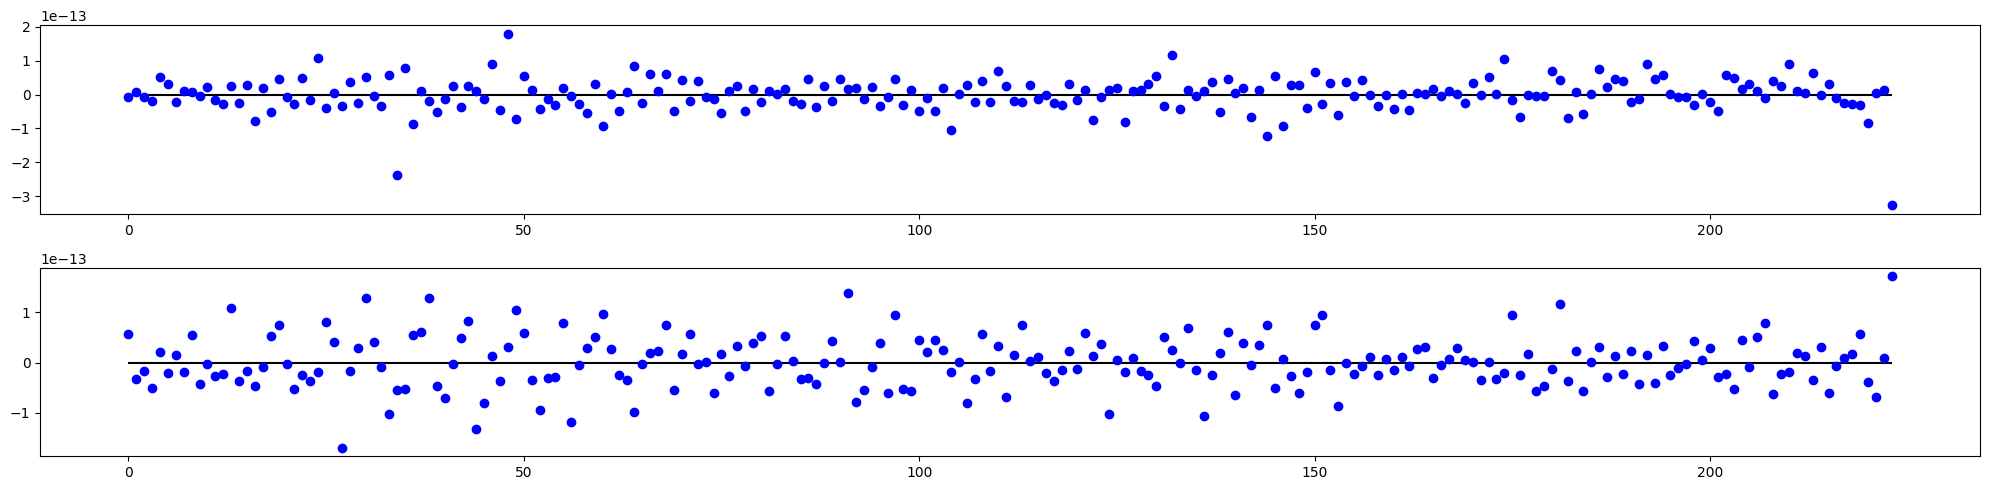

In [50]:
# Compare phase advance

plt.figure(figsize=(20, 5))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), (mux_bpm - table_bpm.phase_x.cpu().numpy()), fmt=' ', marker='o', color='blue')
ax.hlines(0, 0, model.monitor_count - 1, colors='black')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), (muy_bpm - table_bpm.phase_y.cpu().numpy()), fmt=' ', marker='o', color='blue')
ax.hlines(0, 0, model.monitor_count - 1, colors='black')
plt.tight_layout()
plt.show()

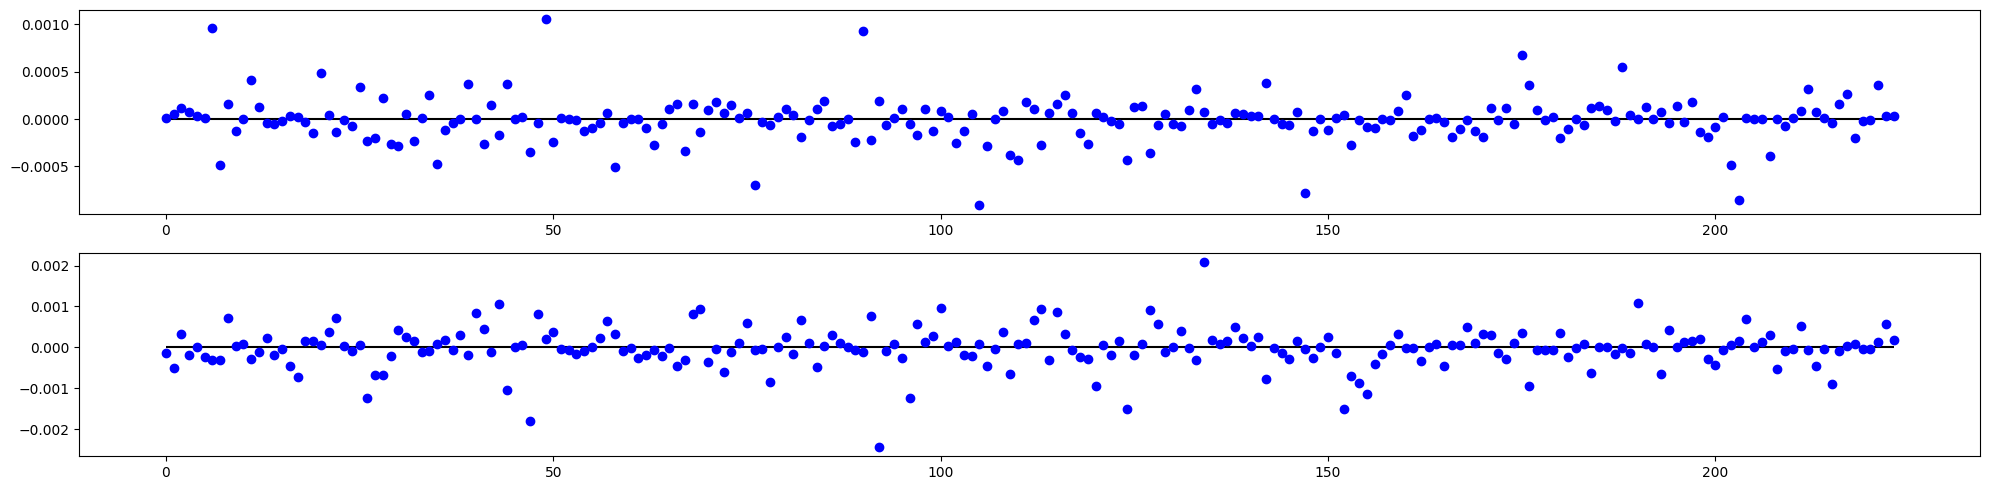

In [51]:
# Compare phases without calibration errors vs with calibration errors
# Note, without bpm rolls, phases are equal

plt.figure(figsize=(20, 5))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), (fxx - fxx_bpm).cpu().numpy(), fmt=' ', marker='o', color='blue')
ax.hlines(0, 0, model.monitor_count - 1, colors='black')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), (fyy - fyy_bpm).cpu().numpy(), fmt=' ', marker='o', color='blue')
ax.hlines(0, 0, model.monitor_count - 1, colors='black')
plt.tight_layout()
plt.show()

In [52]:
# Check relation between phases in beam and bpm frames

# qx(n) = axx cos(2 pi nux n + fxx) + axy cos(2 pi nuy n + fxy)
# qy(n) = ayy cos(2 pi nuy n + fyy) + ayx cos(2 pi nux n + fyx)

def transform(n, gxx, gxy, gyx, gyy, fxx, fyy):
    return torch.stack(
        [
            torch.atan2((fxx.sin()*(gxx*n[0, 0] + gxy*n[2, 0]) + fxx.cos()*gxy*n[2, 1]), (fxx.cos()*(gxx*n[0, 0] + gxy*n[2, 0]) - gxy*fxx.sin()*n[2, 1])),  # fxx
            torch.atan2((fyy.cos()*gxx*n[0, 3] + fyy.sin()*(gxx*n[0, 2] + gxy*n[2, 2])), (-gxx*fyy.sin()*n[0, 3] + fyy.cos()*(gxx*n[0, 2] + gxy*n[2, 2]))), # fxy
            torch.atan2((fxx.sin()*(gyx*n[0, 0] + gyy*n[2, 0]) + fxx.cos()*gyy*n[2, 1]), (fxx.cos()*(gyx*n[0, 0] + gyy*n[2, 0]) - gyy*fxx.sin()*n[2, 1])),  # fyx
            torch.atan2((fyy.cos()*gyx*n[0, 3] + fyy.sin()*(gyx*n[0, 2] + gyy*n[2, 2])), (-gyx*fyy.sin()*n[0, 3] + fyy.cos()*(gyx*n[0, 2] + gyy*n[2, 2])))  # fyy
        ]
    )

print(torch.allclose(torch.vmap(transform)(normal, g_xx, g_xy, g_yx, g_yy, fxx, fyy), torch.stack([fxx_bpm, fxy_bpm, fyx_bpm, fyy_bpm]).T, atol=1.0E-06, rtol=1.0E-6))

True


## Twiss from amplitude & phase

In [53]:
# Set twiss

twiss = Twiss(model, table_bpm, limit=4)

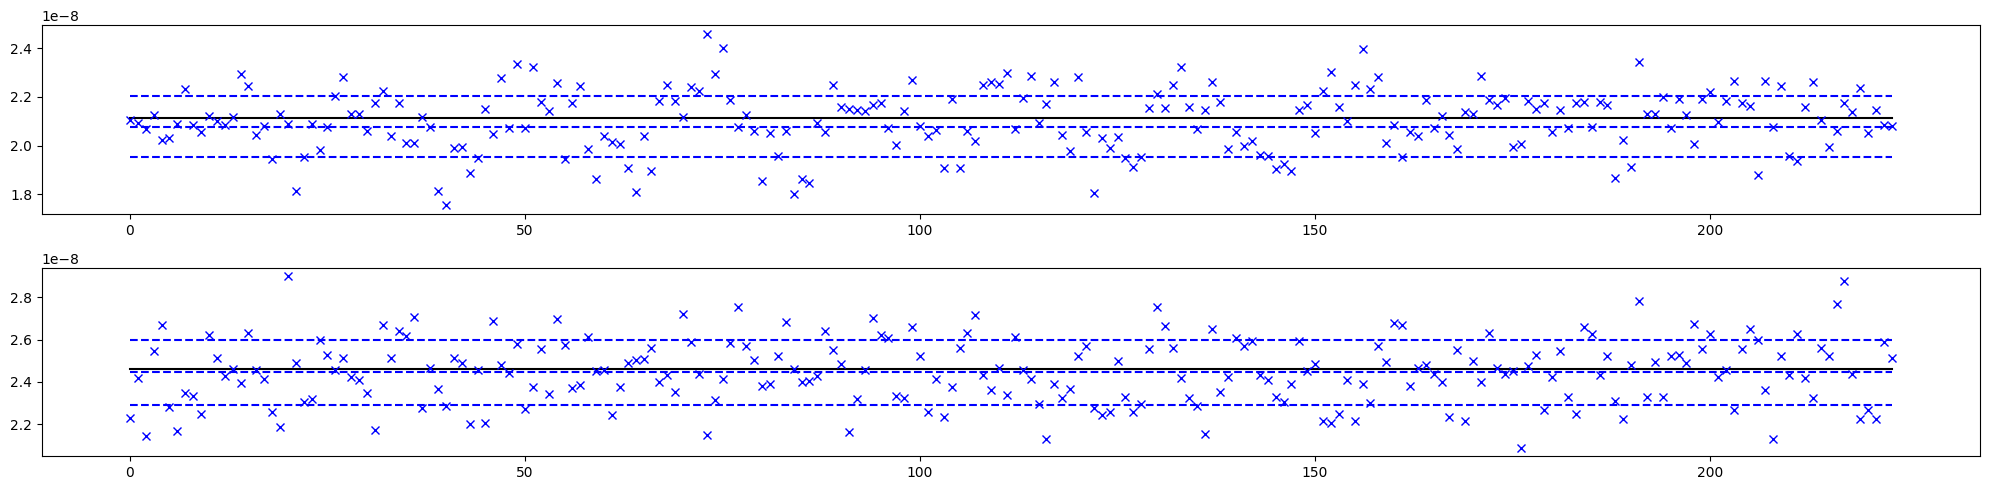

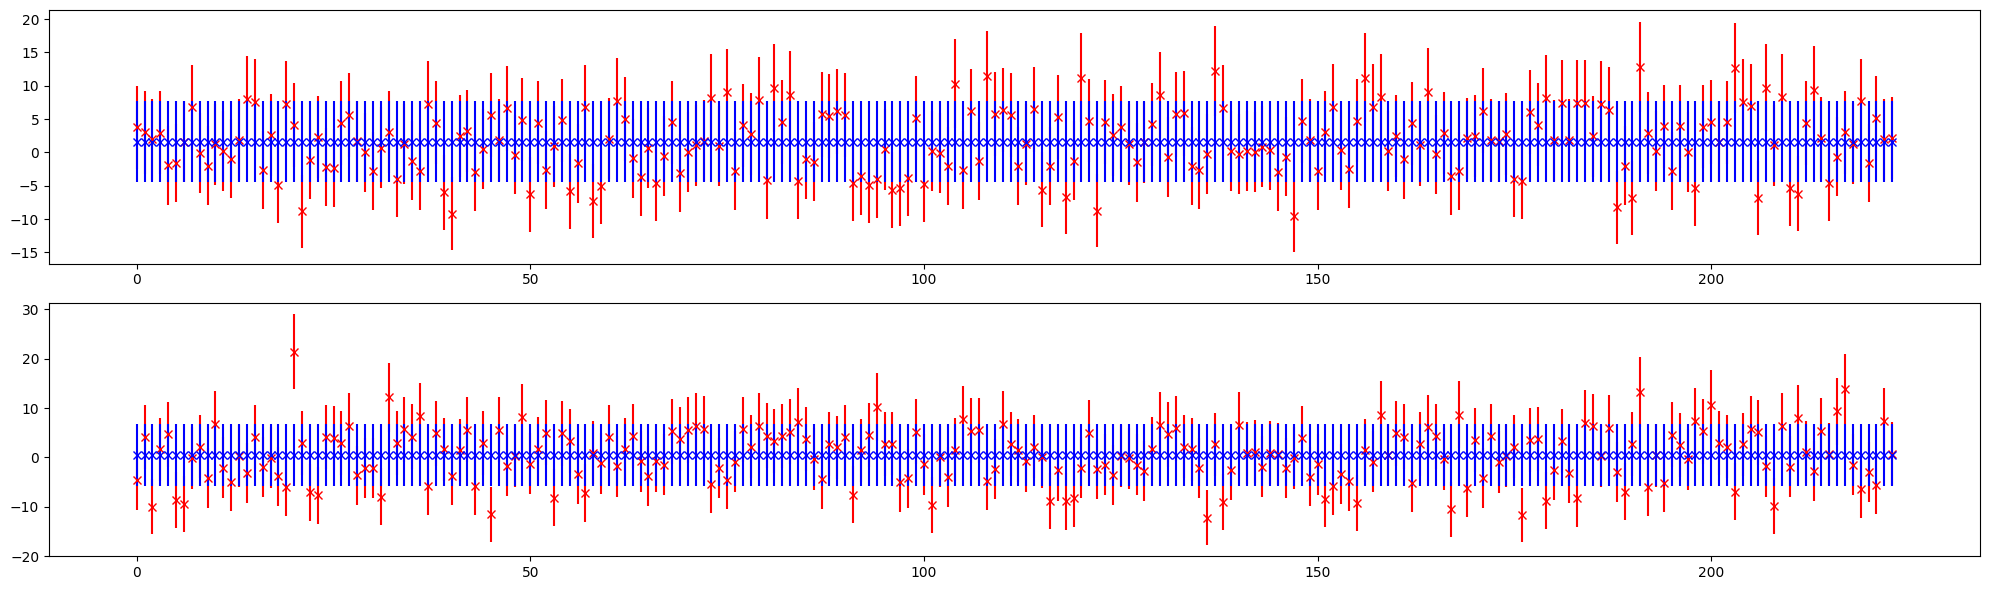

tensor(4.9747, dtype=torch.float64)
tensor(5.3680, dtype=torch.float64)

tensor(1.5896, dtype=torch.float64)
tensor(0.5721, dtype=torch.float64)



In [54]:
# Estimate twiss from amplitude (invariants are estimated from model twiss)

twiss = Twiss(model, table_bpm, limit=1)
twiss.get_action()
twiss.get_twiss_from_amplitude()

# Compare estimated invariants

plt.figure(figsize=(20, 5))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), ix.cpu().numpy(), fmt='-', color='black')
ax.errorbar(range(model.monitor_count), twiss.action['jx'].cpu().numpy(), yerr=twiss.action['sigma_jx'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.hlines([(twiss.action['center_jx'] - twiss.action['spread_jx']).cpu().numpy(), twiss.action['center_jx'].cpu().numpy(), (twiss.action['center_jx'] + twiss.action['spread_jx']).cpu().numpy()], 0, model.monitor_count - 1, color='blue', linestyle='dashed')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), iy.cpu().numpy(), fmt='-', color='black')
ax.errorbar(range(model.monitor_count), twiss.action['jy'].cpu().numpy(), yerr=twiss.action['sigma_jy'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.hlines([(twiss.action['center_jy'] - twiss.action['spread_jy']).cpu().numpy(), twiss.action['center_jy'].cpu().numpy(), (twiss.action['center_jy'] + twiss.action['spread_jy']).cpu().numpy()], 0, model.monitor_count - 1, color='blue', linestyle='dashed')
plt.tight_layout()
plt.show()

# Compare estimated twiss
# Note, large error bars are due to invariant estimation spread

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx)/bx).cpu().numpy(), yerr=100/bx*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx_bpm)/bx_bpm).cpu().numpy(), yerr=100/bx_bpm*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by)/by).cpu().numpy(), yerr=100/by*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by_bpm)/by_bpm).cpu().numpy(), yerr=100/by_bpm*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

# Note, using amplitude, twiss in bpm frame is estimated, but crude estimation of invariants lead to systematic shift

print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx)/bx)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by)/by)))
print()

print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx_bpm)/bx_bpm)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by_bpm)/by_bpm)))
print()

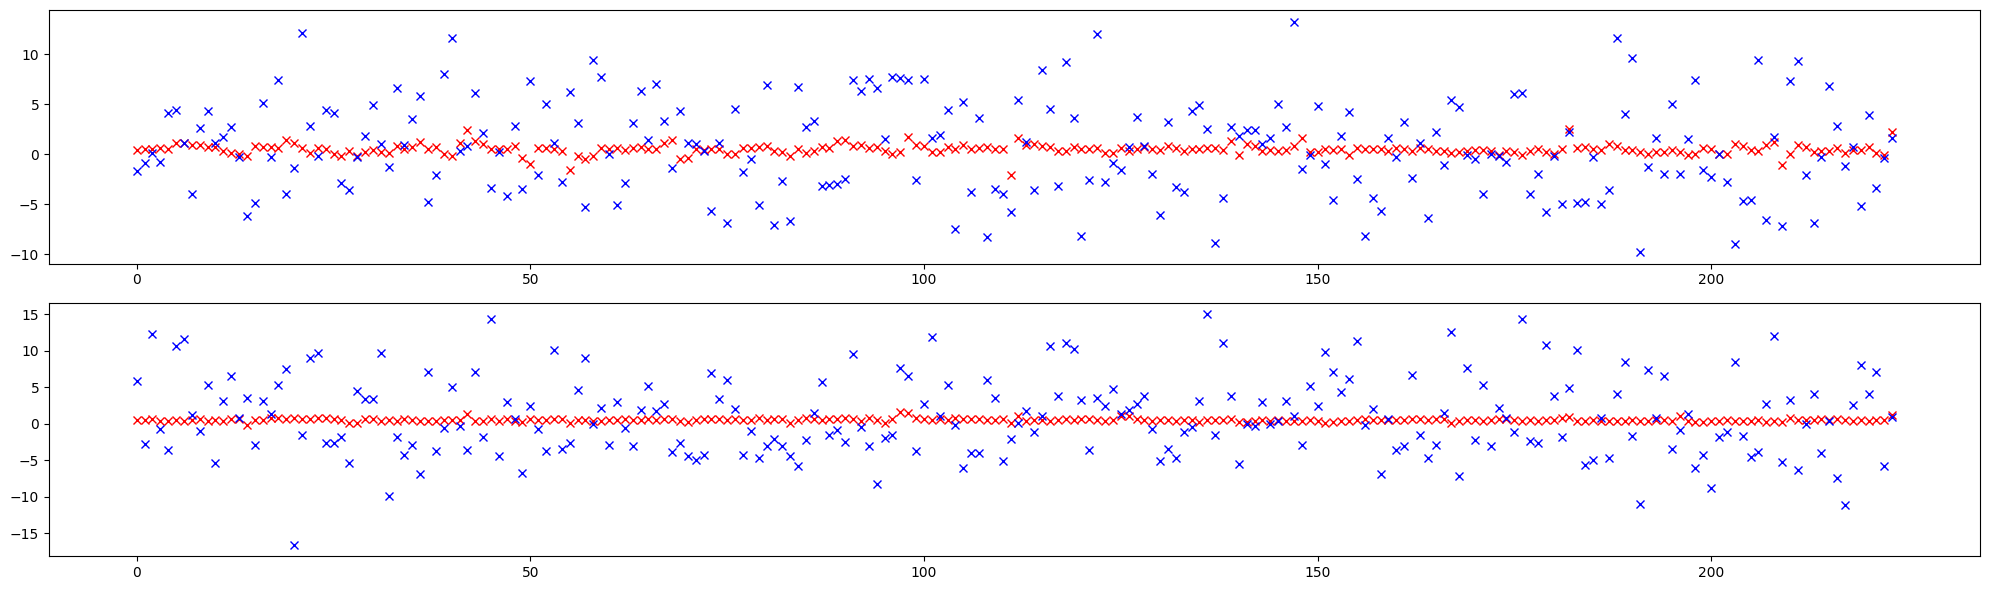

tensor(0.7013, dtype=torch.float64)
tensor(0.5539, dtype=torch.float64)

tensor(4.7409, dtype=torch.float64)
tensor(5.4839, dtype=torch.float64)



In [55]:
# Estimate twiss from phase

twiss.phase_virtual()
twiss.get_twiss_from_phase()
mask_x = twiss.filter_twiss(plane='x', phase={'use': True, 'threshold': 10.0}, model={'use': False, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
mask_y = twiss.filter_twiss(plane='y', phase={'use': True, 'threshold': 10.0}, model={'use': False, 'threshold': 0.5}, value={'use': False, 'threshold': 0.5}, sigma={'use': False, 'threshold': 0.25}, limit={'use': True, 'threshold': 5.0})
_ = twiss.process_twiss(plane='x', mask=mask_x, weight=True)
_ = twiss.process_twiss(plane='y', mask=mask_y, weight=True)

# Note, (uncoupled) invariants can be computed for given coordinates and momenta

# Compare estimated twiss

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((twiss.bx[model.monitor_index] - bx)/bx).cpu().numpy(), yerr=100/bx*twiss.sigma_bx[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.bx[model.monitor_index] - bx_bpm)/bx_bpm).cpu().numpy(), yerr=100/bx_bpm*twiss.sigma_bx[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((twiss.by[model.monitor_index] - by)/by).cpu().numpy(), yerr=100/by*twiss.sigma_by[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.by[model.monitor_index] - by_bpm)/by_bpm).cpu().numpy(), yerr=100/by_bpm*twiss.sigma_by[model.monitor_index].cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((twiss.bx[model.monitor_index] - bx)/bx)))
print(root_mean_square(100*((twiss.by[model.monitor_index] - by)/by)))
print()

print(root_mean_square(100*((twiss.bx[model.monitor_index] - bx_bpm)/bx_bpm)))
print(root_mean_square(100*((twiss.by[model.monitor_index] - by_bpm)/by_bpm)))
print()

# Note, estimated twiss parameters are closer to beam frame ones

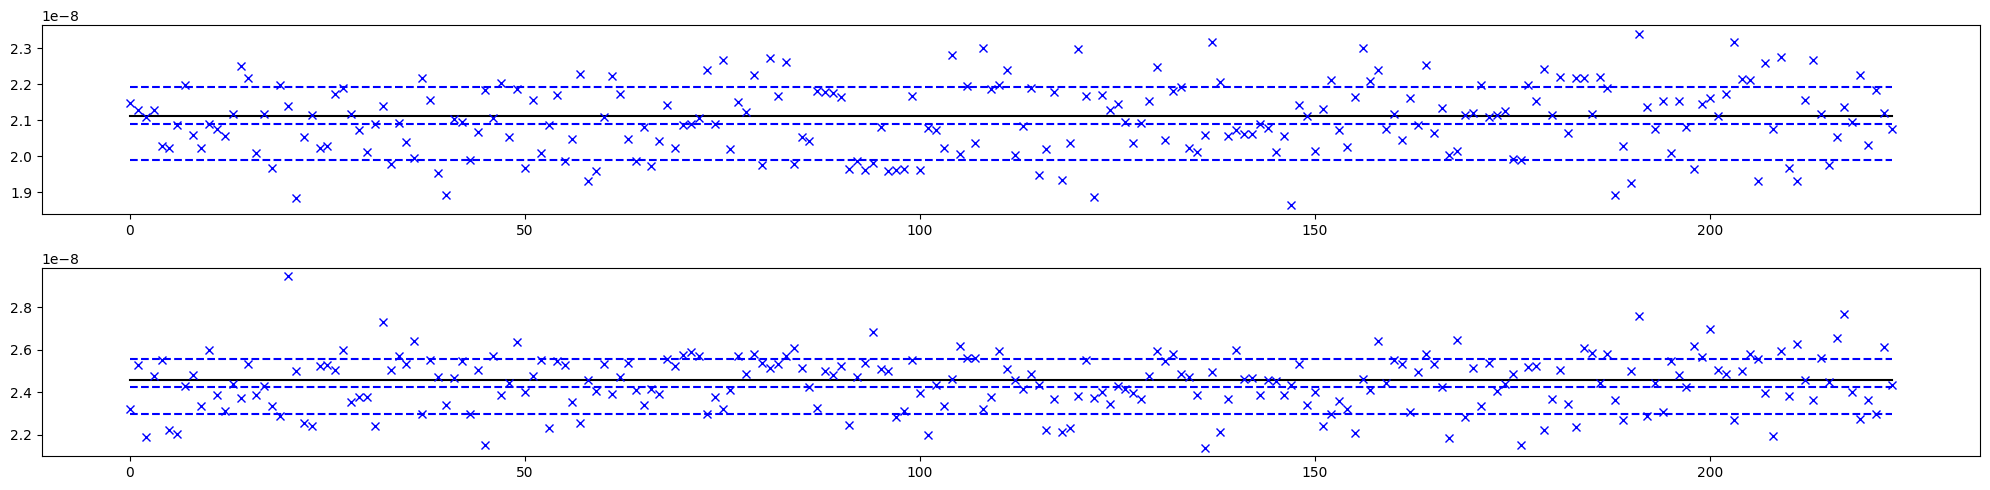

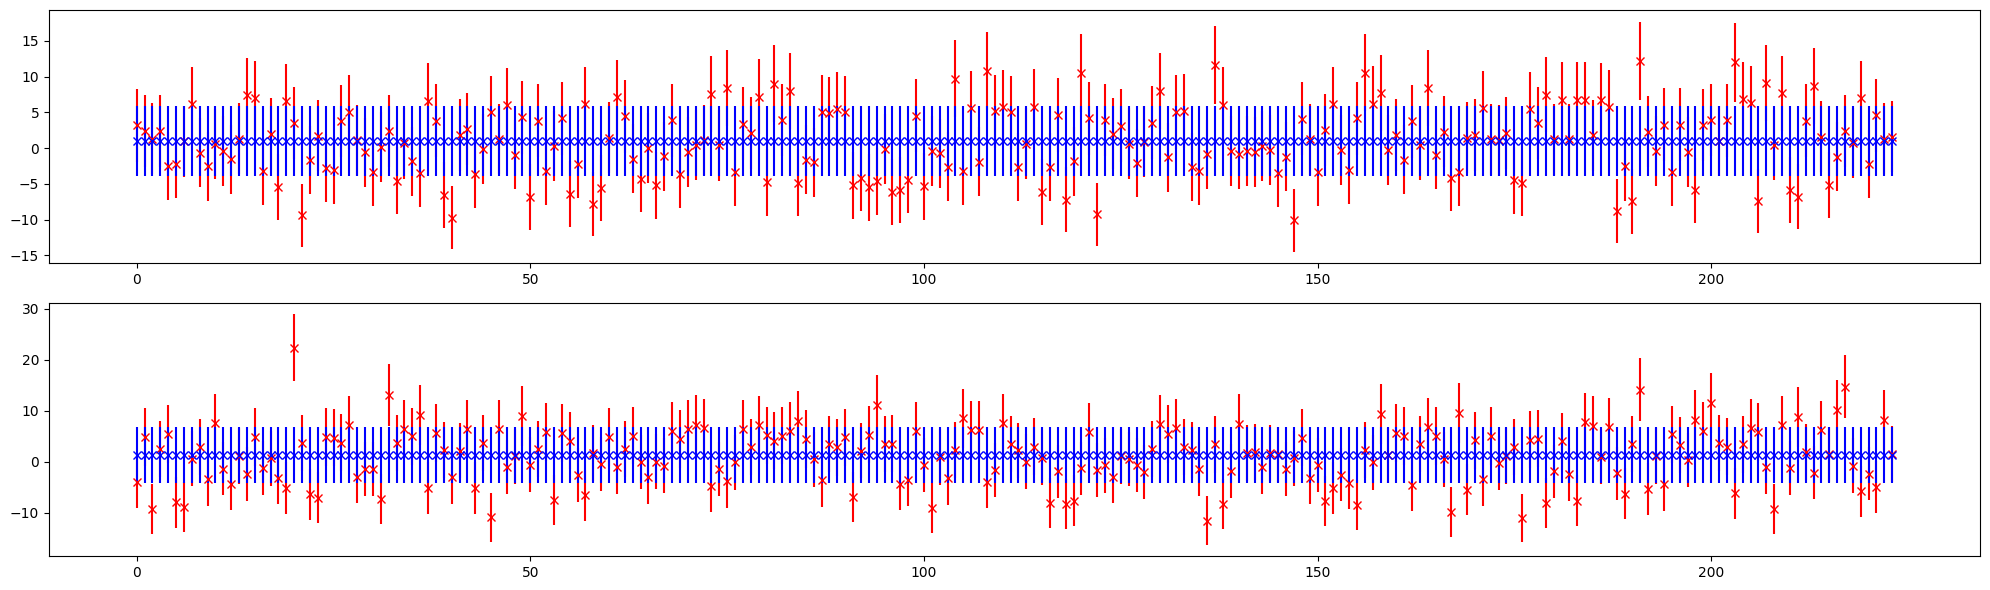

tensor(4.7827, dtype=torch.float64)
tensor(5.5207, dtype=torch.float64)

tensor(0.9722, dtype=torch.float64)
tensor(1.3173, dtype=torch.float64)



In [56]:
# Estimate twiss from amplitude (use twiss from phase for invariants estimation)

twiss.get_action(bx=twiss.bx[model.monitor_index], by=twiss.by[model.monitor_index], sigma_bx=twiss.sigma_bx[model.monitor_index], sigma_by=twiss.sigma_by[model.monitor_index])
twiss.get_twiss_from_amplitude()

# Compare estimated invariants

plt.figure(figsize=(20, 5))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), ix.cpu().numpy(), fmt='-', color='black')
ax.errorbar(range(model.monitor_count), twiss.action['jx'].cpu().numpy(), yerr=twiss.action['sigma_jx'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.hlines([(twiss.action['center_jx'] - twiss.action['spread_jx']).cpu().numpy(), twiss.action['center_jx'].cpu().numpy(), (twiss.action['center_jx'] + twiss.action['spread_jx']).cpu().numpy()], 0, model.monitor_count - 1, color='blue', linestyle='dashed')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), iy.cpu().numpy(), fmt='-', color='black')
ax.errorbar(range(model.monitor_count), twiss.action['jy'].cpu().numpy(), yerr=twiss.action['sigma_jy'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.hlines([(twiss.action['center_jy'] - twiss.action['spread_jy']).cpu().numpy(), twiss.action['center_jy'].cpu().numpy(), (twiss.action['center_jy'] + twiss.action['spread_jy']).cpu().numpy()], 0, model.monitor_count - 1, color='blue', linestyle='dashed')
plt.tight_layout()
plt.show()

# Compare estimated twiss
# Note, large error bars are due to invariant estimation spread

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx)/bx).cpu().numpy(), yerr=100/bx*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx_bpm)/bx_bpm).cpu().numpy(), yerr=100/bx_bpm*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by)/by).cpu().numpy(), yerr=100/by*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by_bpm)/by_bpm).cpu().numpy(), yerr=100/by_bpm*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

# Note, using amplitude, twiss in bpm frame is estimated, but crude estimation of invariants lead to systematic shift

print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx)/bx)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by)/by)))
print()

print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx_bpm)/bx_bpm)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by_bpm)/by_bpm)))
print()

# Note, while using exact invariant values give much better results, using estimated twiss instead of model one generaly reduces systematic shift in action estimation
# Strong coupling migh reduce accuracy (introduce systematic shift in estimated invariants)

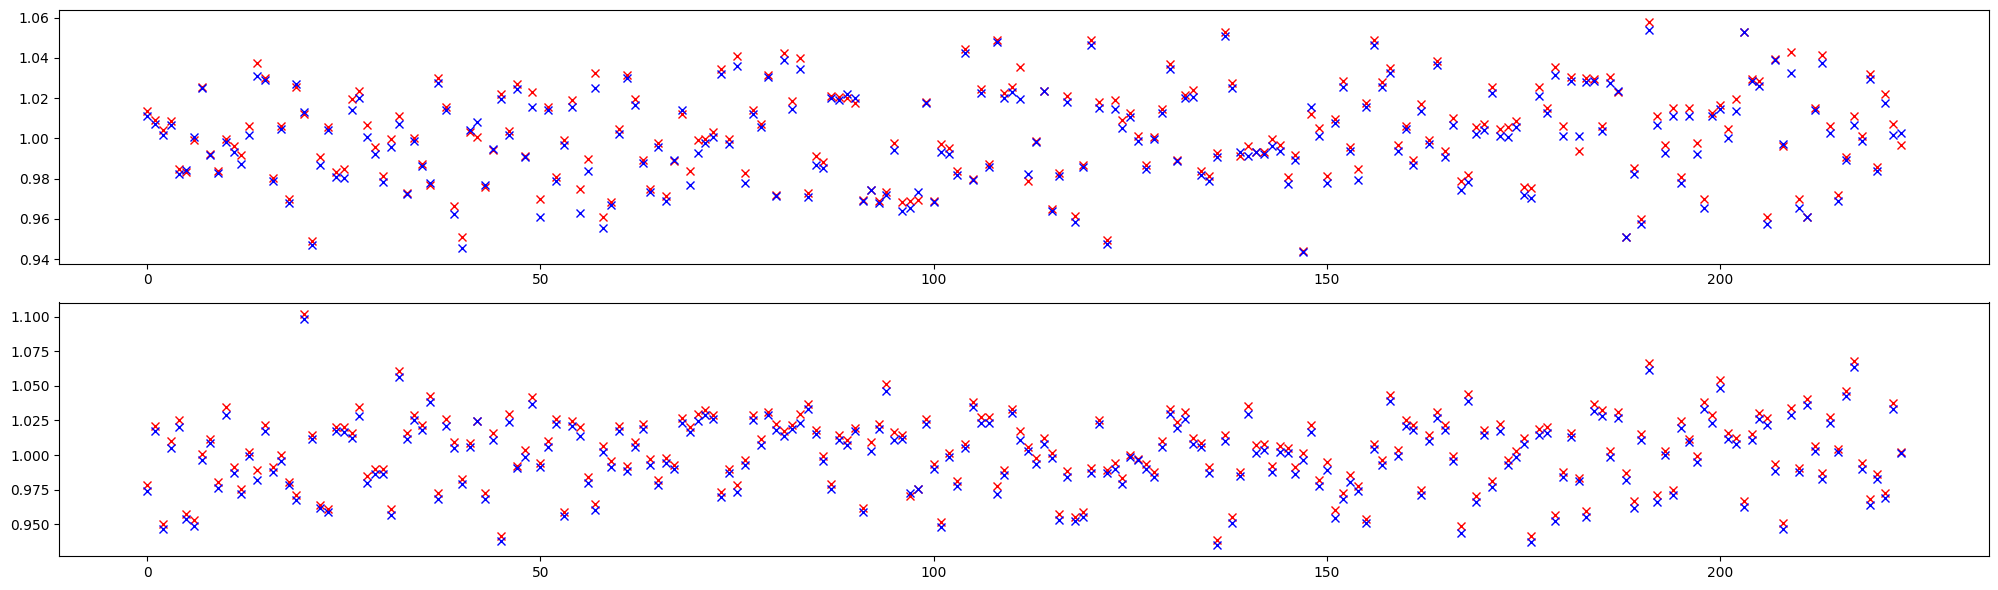

tensor(0.3516, dtype=torch.float64)
tensor(0.4120, dtype=torch.float64)



In [57]:
# Estimate scale calibration errors from ratioof estimated twiss parameters
# Note, without bpm rolls and assuming zero mean of scale bpm errors, the ratio of beta functions give a good estimate of scale calibrations

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), (twiss.data_amplitude['bx']/twiss.bx[model.monitor_index]).sqrt().cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), g_xx.cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), (twiss.data_amplitude['by']/twiss.by[model.monitor_index]).sqrt().cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), g_yy.cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

print(root_mean_square(100*(((twiss.data_amplitude['bx']/twiss.bx[model.monitor_index]).sqrt() - g_xx)/g_xx)))
print(root_mean_square(100*(((twiss.data_amplitude['by']/twiss.by[model.monitor_index]).sqrt() - g_yy)/g_yy)))
print()

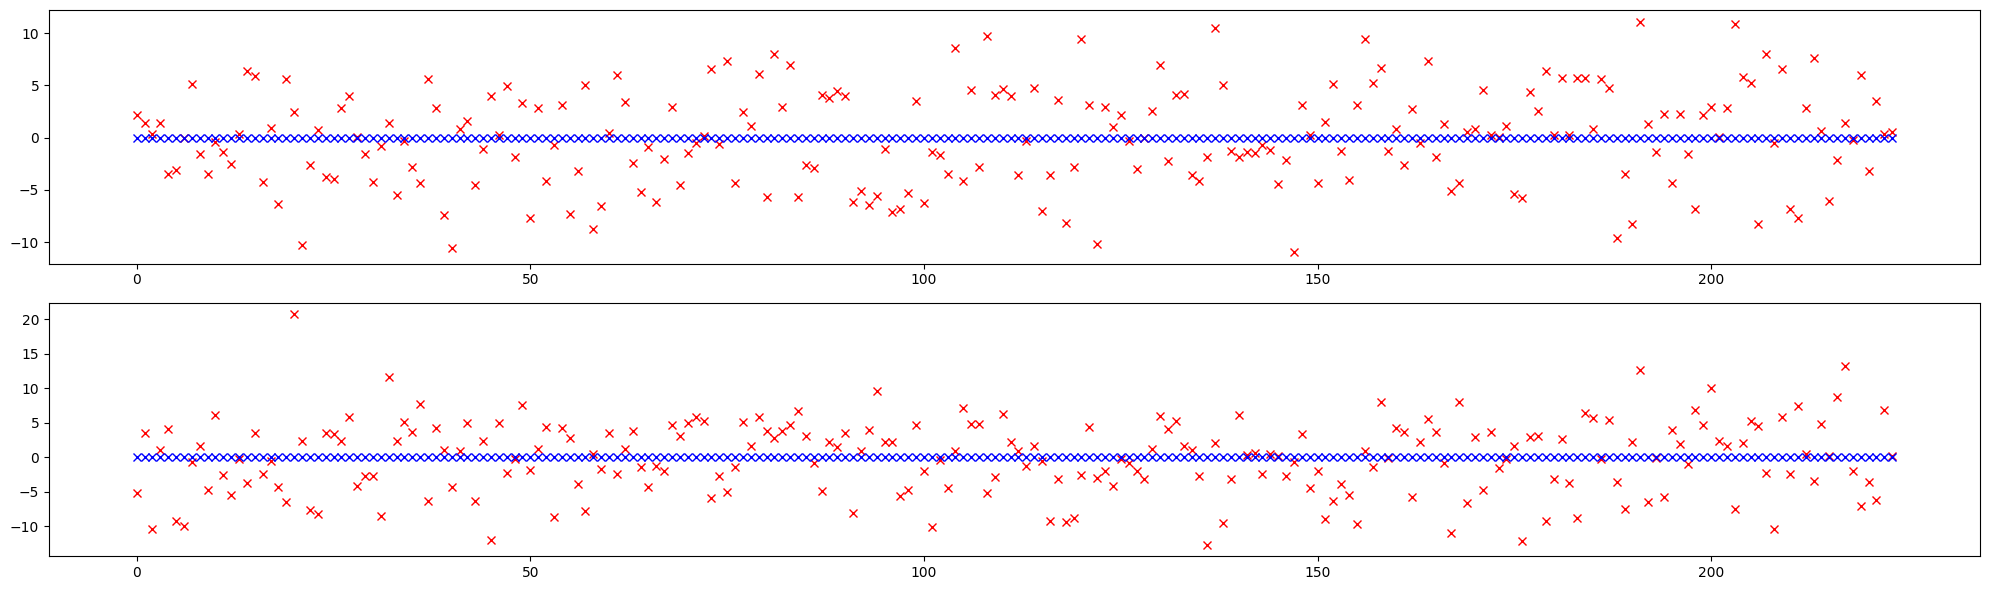

tensor(4.6339, dtype=torch.float64)
tensor(5.3192, dtype=torch.float64)

tensor(3.7296e-11, dtype=torch.float64)
tensor(2.0879e-10, dtype=torch.float64)



In [58]:
# Estimate twiss from amplitude (exact invariants)

twiss.get_action(jx=ix, jy=iy, sigma_jx=ix.std(), sigma_jy=iy.std())
twiss.get_twiss_from_amplitude()

# Compare estimated twiss

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx)/bx).cpu().numpy(), yerr=100/bx*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx_bpm)/bx_bpm).cpu().numpy(), yerr=100/bx_bpm*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by)/by).cpu().numpy(), yerr=100/by*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by_bpm)/by_bpm).cpu().numpy(), yerr=100/by_bpm*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx)/bx)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by)/by)))
print()

print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx_bpm)/bx_bpm)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by_bpm)/by_bpm)))
print()

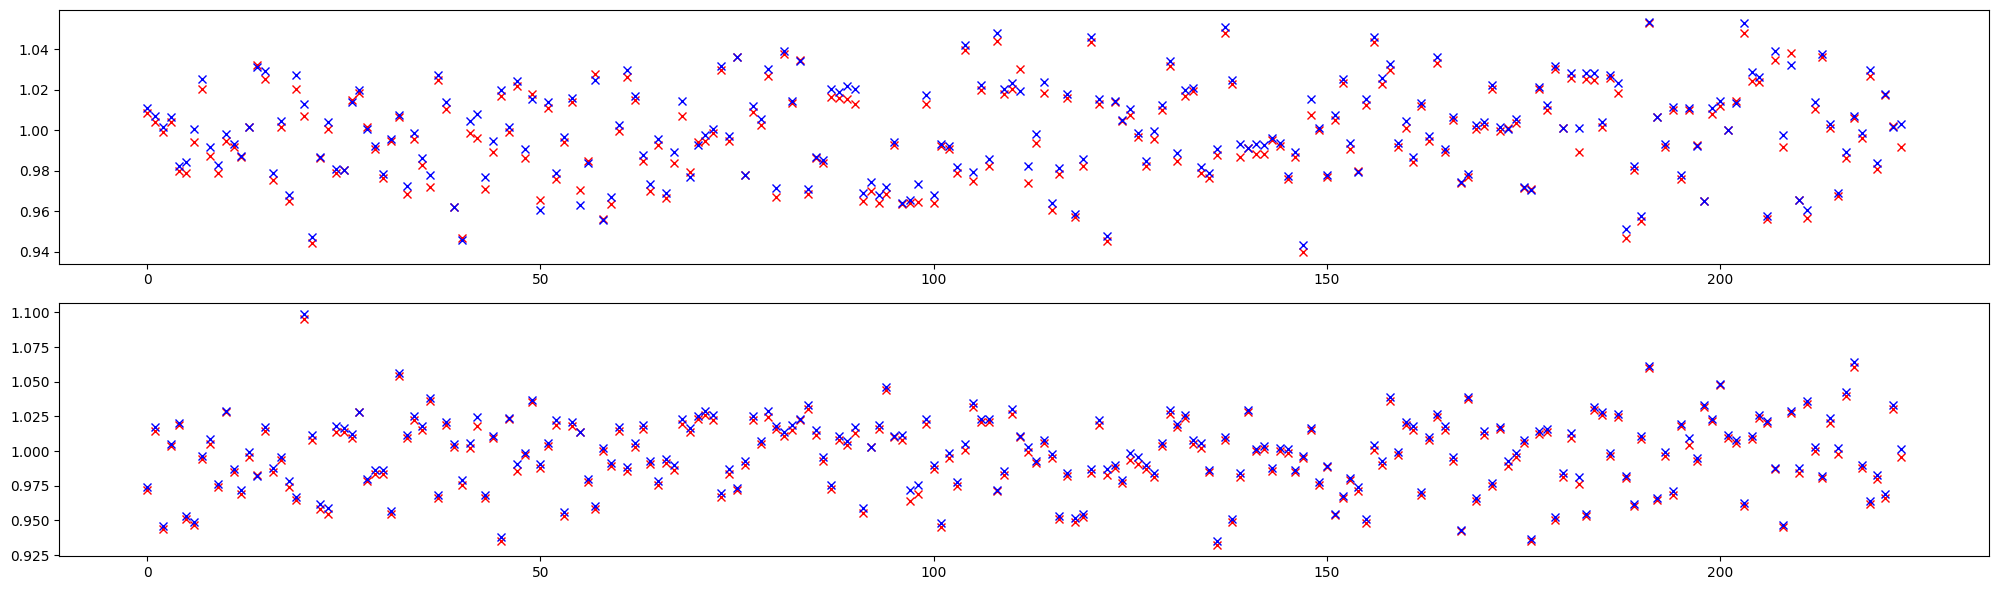

tensor(0.3519, dtype=torch.float64)
tensor(0.2793, dtype=torch.float64)



In [59]:
# Estimate scale calibration errors from ratio of estimated twiss parameters

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), (twiss.data_amplitude['bx']/twiss.bx[model.monitor_index]).sqrt().cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), g_xx.cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), (twiss.data_amplitude['by']/twiss.by[model.monitor_index]).sqrt().cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), g_yy.cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

print(root_mean_square(100*(((twiss.data_amplitude['bx']/twiss.bx[model.monitor_index]).sqrt() - g_xx)/g_xx)))
print(root_mean_square(100*(((twiss.data_amplitude['by']/twiss.by[model.monitor_index]).sqrt() - g_yy)/g_yy)))
print()

## Twiss from invariant fit

In [60]:
%%time

# Estimate twiss from invariant fit

count = 8

data = twiss.get_twiss_from_data(1,                # -- first turn
                                 256,              # -- total number of turns, orbits are computed for (start, start + total)
                                 parametric_normal,# -- normalization
                                 model.matrix,     # -- transport matrix generator
                                 twiss=None,       # -- initial twiss for each location or None (use model values)
                                 method='lstsq',   # -- momenta computation method
                                 limit=2,          # -- range limit or direction/shift
                                 product=True,     # -- flag to use product objective
                                 jacobian=False,   # -- flag to use objective jacobian
                                 count=count,      # -- number of samples
                                 fraction=0.75,    # -- sample length fraction
                                 ix=None,          # -- ix invariant value
                                 iy=None,          # -- iy invariant value  (both should present for fixed fit)
                                 n_jobs=4,         # -- number of parallel jobs (loop over samples)
                                 verbose=False)    # -- verbose flag

CPU times: user 8min 34s, sys: 1min 24s, total: 9min 58s
Wall time: 11min 57s


In [61]:
# Process fitted invariants

ix_out = data[:, 0, 0]
iy_out = data[:, 0, 1]

sigma_ix = data[:, 1, 0]
sigma_iy = data[:, 1, 1]

invariant = twiss.get_invariant(ix_out, iy_out, sigma_ix, sigma_iy)

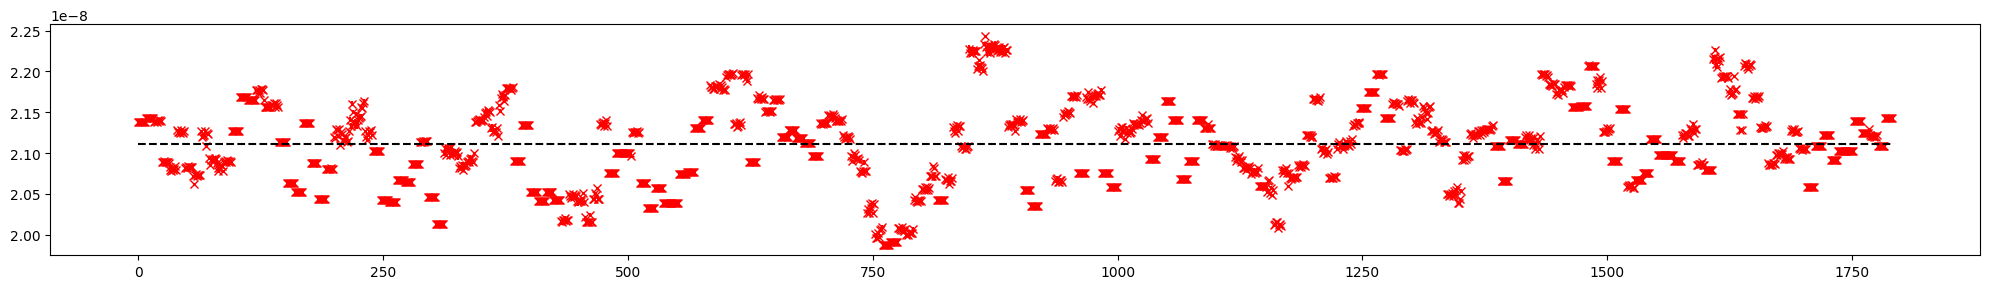

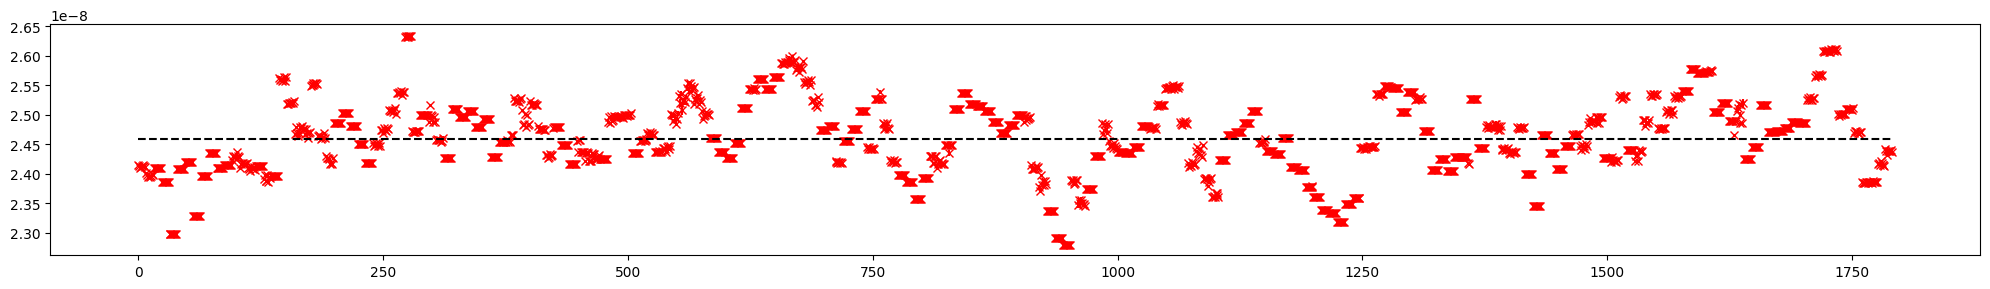

In [62]:
# Plot invariants for each sample in each signal

plt.figure(figsize=(20, 3))
plt.errorbar(range(count*model.monitor_count), ix_out.flatten().cpu().numpy(), yerr=sigma_ix.flatten().cpu().numpy(), fmt=' ', color='red', marker='x', zorder=0)
plt.hlines(ix.mean(), 0, count*model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(count*model.monitor_count), iy_out.flatten().cpu().numpy(), yerr=sigma_iy.flatten().cpu().numpy(), fmt=' ', color='red', marker='x', zorder=0)
plt.hlines(iy.mean(), 0, count*model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.tight_layout()
plt.show()

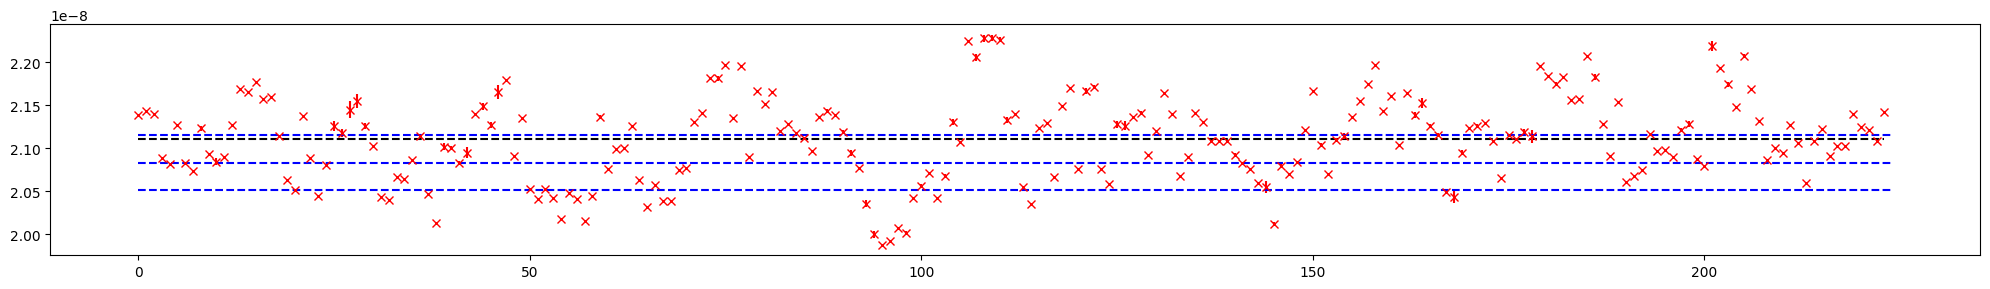

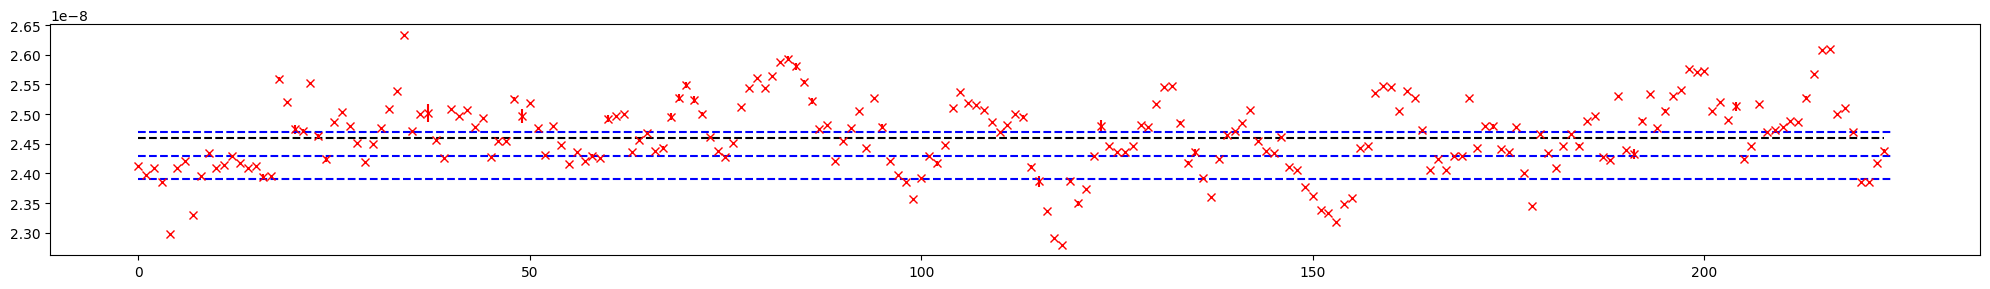

tensor(2.1113e-08, dtype=torch.float64)
tensor(2.1113e-08, dtype=torch.float64)
tensor(2.0833e-08, dtype=torch.float64)
tensor(2.1106e-08, dtype=torch.float64)

tensor(2.4590e-08, dtype=torch.float64)
tensor(2.4590e-08, dtype=torch.float64)
tensor(2.4301e-08, dtype=torch.float64)
tensor(2.4624e-08, dtype=torch.float64)



In [63]:
# Plot invariants for each monitor

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), invariant['ix_center'].flatten().cpu().numpy(), yerr=invariant['ix_spread'].flatten().cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(ix.mean(), 0, model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.hlines([invariant['ix_value'] - invariant['ix_error'], invariant['ix_value'], invariant['ix_value'] + invariant['ix_error']], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), invariant['iy_center'].flatten().cpu().numpy(), yerr=invariant['iy_spread'].flatten().cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(iy.mean(), 0, model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.hlines([invariant['iy_value'] - invariant['iy_error'], invariant['iy_value'], invariant['iy_value'] + invariant['iy_error']], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.tight_layout()
plt.show()

print(ix.mean())
print(twiss.action['center_jx'])
print(invariant['ix_value'])
print(ix_out.mean())
print()

print(iy.mean())
print(twiss.action['center_jy'])
print(invariant['iy_value'])
print(iy_out.mean())
print()

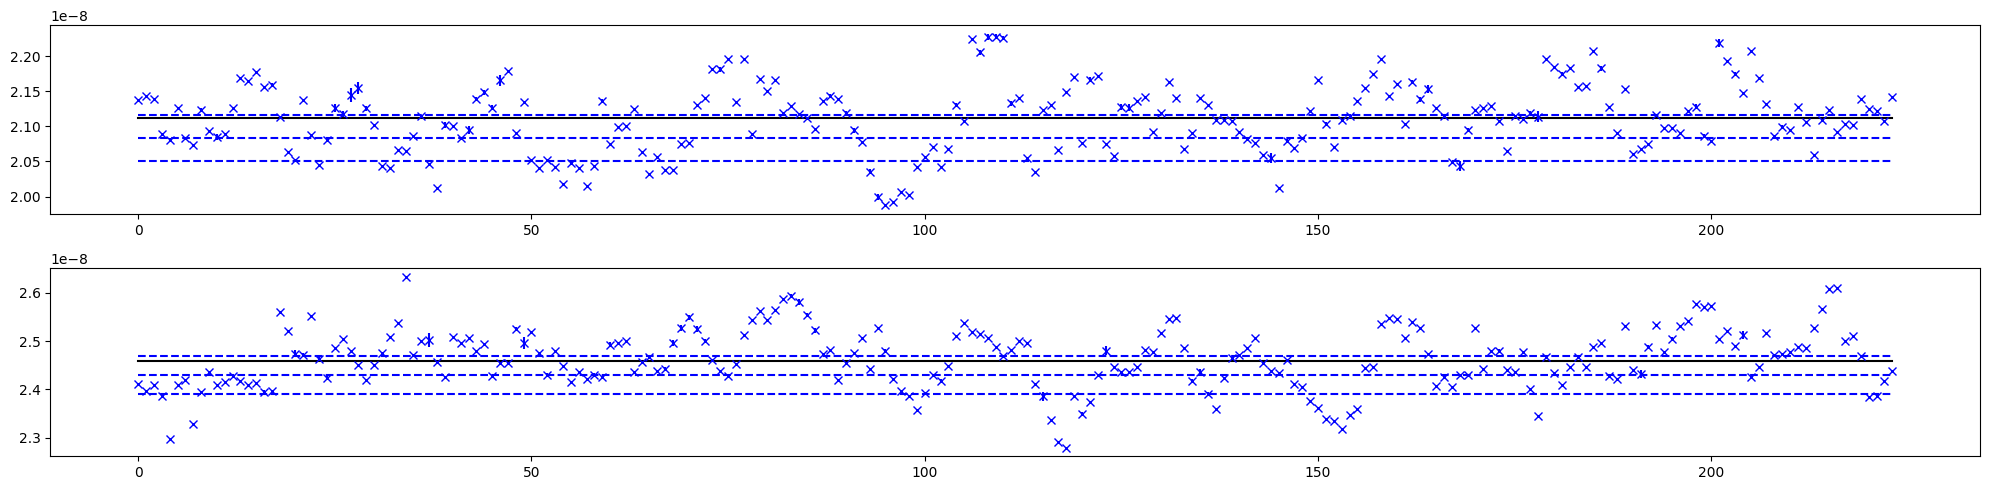

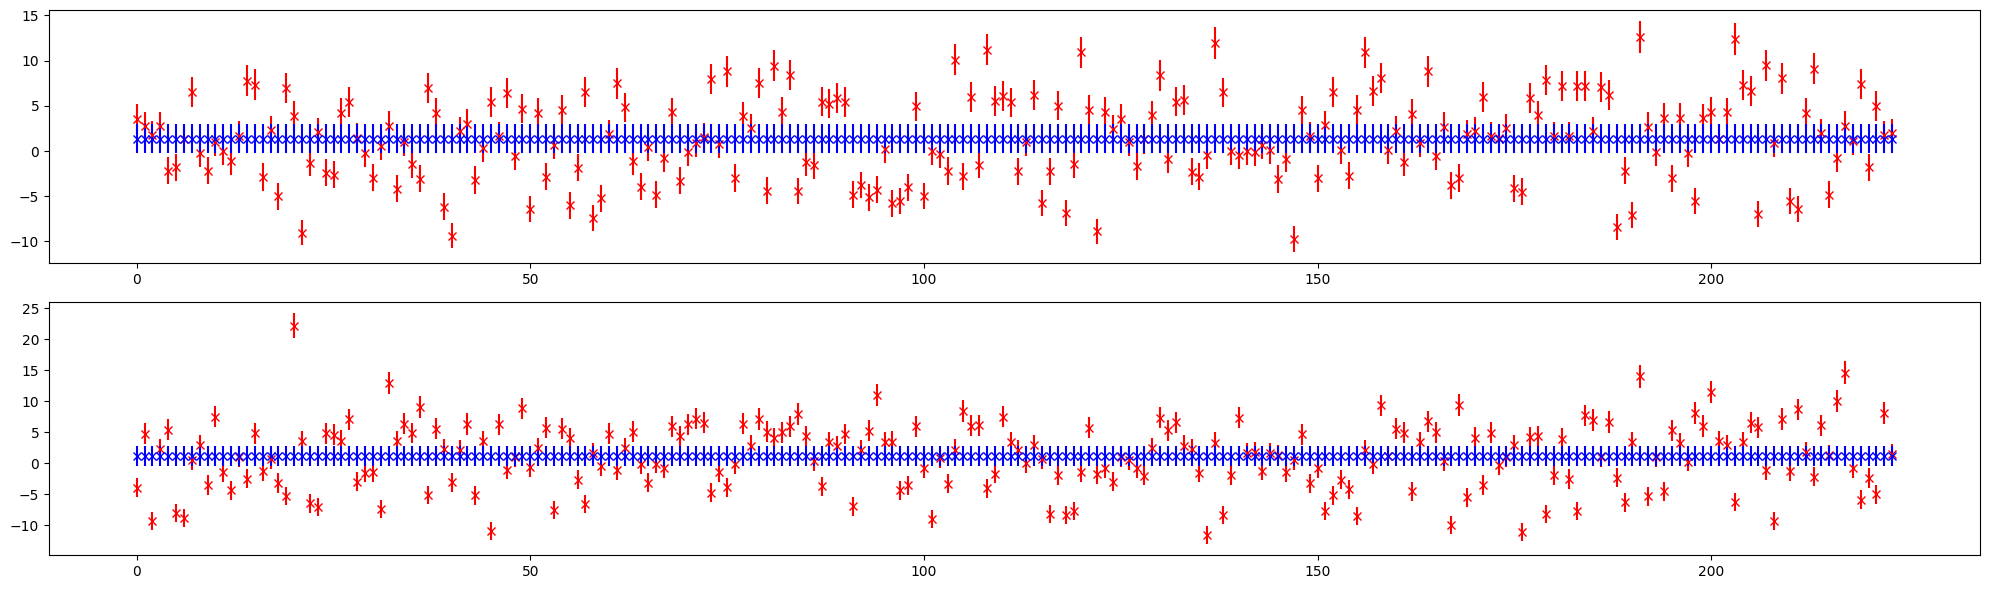

tensor(4.8896, dtype=torch.float64)
tensor(5.4868, dtype=torch.float64)

tensor(1.3433, dtype=torch.float64)
tensor(1.1861, dtype=torch.float64)



In [64]:
# Estimate twiss from amplitude (use fitted invariant)

twiss.get_action(jx=invariant['ix_center'], jy=invariant['iy_center'], sigma_jx=invariant['ix_spread'], sigma_jy=invariant['iy_spread'])
twiss.get_twiss_from_amplitude()

# Compare estimated invariants

plt.figure(figsize=(20, 5))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), ix.cpu().numpy(), fmt='-', color='black')
ax.errorbar(range(model.monitor_count), twiss.action['jx'].cpu().numpy(), yerr=twiss.action['sigma_jx'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.hlines([(twiss.action['center_jx'] - twiss.action['spread_jx']).cpu().numpy(), twiss.action['center_jx'].cpu().numpy(), (twiss.action['center_jx'] + twiss.action['spread_jx']).cpu().numpy()], 0, model.monitor_count - 1, color='blue', linestyle='dashed')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), iy.cpu().numpy(), fmt='-', color='black')
ax.errorbar(range(model.monitor_count), twiss.action['jy'].cpu().numpy(), yerr=twiss.action['sigma_jy'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.hlines([(twiss.action['center_jy'] - twiss.action['spread_jy']).cpu().numpy(), twiss.action['center_jy'].cpu().numpy(), (twiss.action['center_jy'] + twiss.action['spread_jy']).cpu().numpy()], 0, model.monitor_count - 1, color='blue', linestyle='dashed')
plt.tight_layout()
plt.show()

# Compare estimated twiss

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx)/bx).cpu().numpy(), yerr=100/bx*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx_bpm)/bx_bpm).cpu().numpy(), yerr=100/bx_bpm*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by)/by).cpu().numpy(), yerr=100/by*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by_bpm)/by_bpm).cpu().numpy(), yerr=100/by_bpm*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx)/bx)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by)/by)))
print()

print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx_bpm)/bx_bpm)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by_bpm)/by_bpm)))
print()

In [65]:
# Process twiss

value_n11 = data[:, 0, 2]
error_n11 = data[:, 1, 2]

value_n33 = data[:, 0, 3]
error_n33 = data[:, 1, 3]

value_n21 = data[:, 0, 4]
error_n21 = data[:, 1, 4]

value_n43 = data[:, 0, 5]
error_n43 = data[:, 1, 5]

value_n13 = data[:, 0, 6]
error_n13 = data[:, 1, 6]

value_n31 = data[:, 0, 7]
error_n31 = data[:, 1, 7]

value_n14 = data[:, 0, 8]
error_n14 = data[:, 1, 8]

value_n41 = data[:, 0, 9]
error_n41 = data[:, 1, 9]

value_n11, error_n11 = twiss.process(value_n11, error_n11)
value_n33, error_n33 = twiss.process(value_n33, error_n33)
value_n21, error_n21 = twiss.process(value_n21, error_n21)
value_n43, error_n43 = twiss.process(value_n43, error_n43)
value_n13, error_n13 = twiss.process(value_n13, error_n13)
value_n31, error_n31 = twiss.process(value_n31, error_n31)
value_n14, error_n14 = twiss.process(value_n14, error_n14)
value_n41, error_n41 = twiss.process(value_n41, error_n41)

value = torch.stack([value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41]).T
error = torch.stack([error_n11, error_n33, error_n21, error_n43, error_n13, error_n31, error_n14, error_n41]).T

cs_value, cs_error = [], []

for value_loc, error_loc in zip(value, error):
    table = value_loc.reshape(-1, 1) + error_loc.reshape(-1, 1)*torch.randn(1024, dtype=dtype, device=device)
    table = torch.stack([parametric_normal(*free) for free in table.T])
    table = normal_to_wolski(table)
    table = torch.stack([wolski_to_cs(w) for w in table]).T
    cs_value.append(table.mean(-1))
    cs_error.append(table.std(-1))
    
cs_value = torch.stack(cs_value)
cs_error = torch.stack(cs_error)

value_ax, value_bx, value_ay, value_by = cs_value.T
error_ax, error_bx, error_ay, error_by = cs_error.T

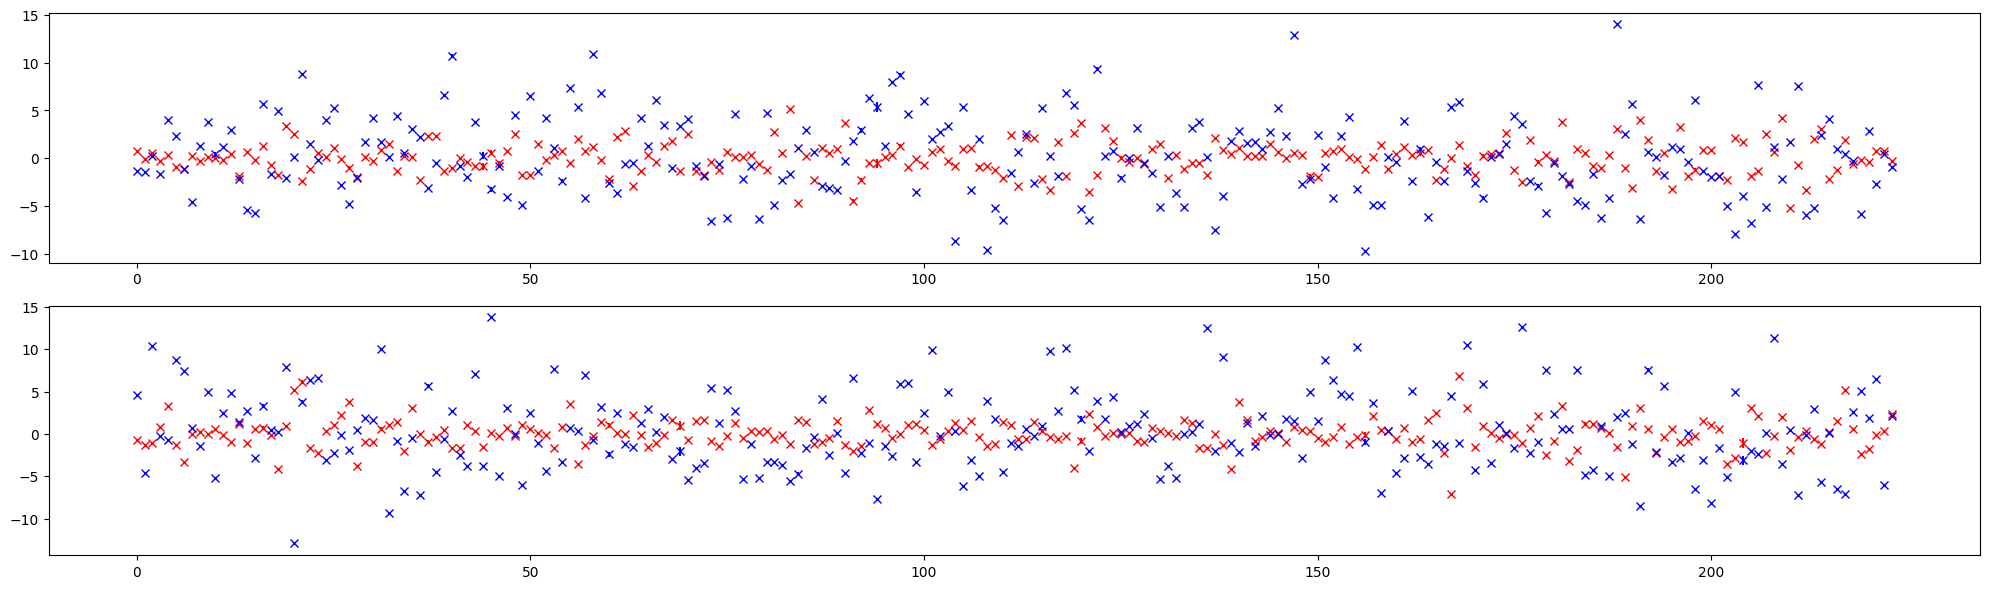

tensor(1.6742, dtype=torch.float64)
tensor(1.7526, dtype=torch.float64)

tensor(4.2188, dtype=torch.float64)
tensor(4.6564, dtype=torch.float64)



In [66]:
# Compare beta function values

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((value_bx - bx)/bx).cpu().numpy(), yerr=100/bx*error_bx.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((value_bx - bx_bpm)/bx_bpm).cpu().numpy(), yerr=100/bx_bpm*error_bx.cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((value_by - by)/by).cpu().numpy(), yerr=100/by*error_by.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((value_by - by_bpm)/by_bpm).cpu().numpy(), yerr=100/by_bpm*error_by.cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((value_bx - bx)/bx)))
print(root_mean_square(100*((value_by - by)/by)))
print()

print(root_mean_square(100*((value_bx - bx_bpm)/bx_bpm)))
print(root_mean_square(100*((value_by - by_bpm)/by_bpm)))
print()

# Note, the results is closer to beam frame beta functions

In [67]:
# Compare estimated normalization matrix elements

tensor(0.0256, dtype=torch.float64)
tensor(0.0596, dtype=torch.float64)

tensor(0.0194, dtype=torch.float64)
tensor(0.0434, dtype=torch.float64)

tensor(0.0139, dtype=torch.float64)
tensor(0.0415, dtype=torch.float64)

tensor(0.0170, dtype=torch.float64)
tensor(0.0350, dtype=torch.float64)

tensor(0.0066, dtype=torch.float64)
tensor(0.0108, dtype=torch.float64)

tensor(0.0088, dtype=torch.float64)
tensor(0.0134, dtype=torch.float64)

tensor(0.0043, dtype=torch.float64)
tensor(0.0055, dtype=torch.float64)

tensor(0.0045, dtype=torch.float64)
tensor(0.0090, dtype=torch.float64)



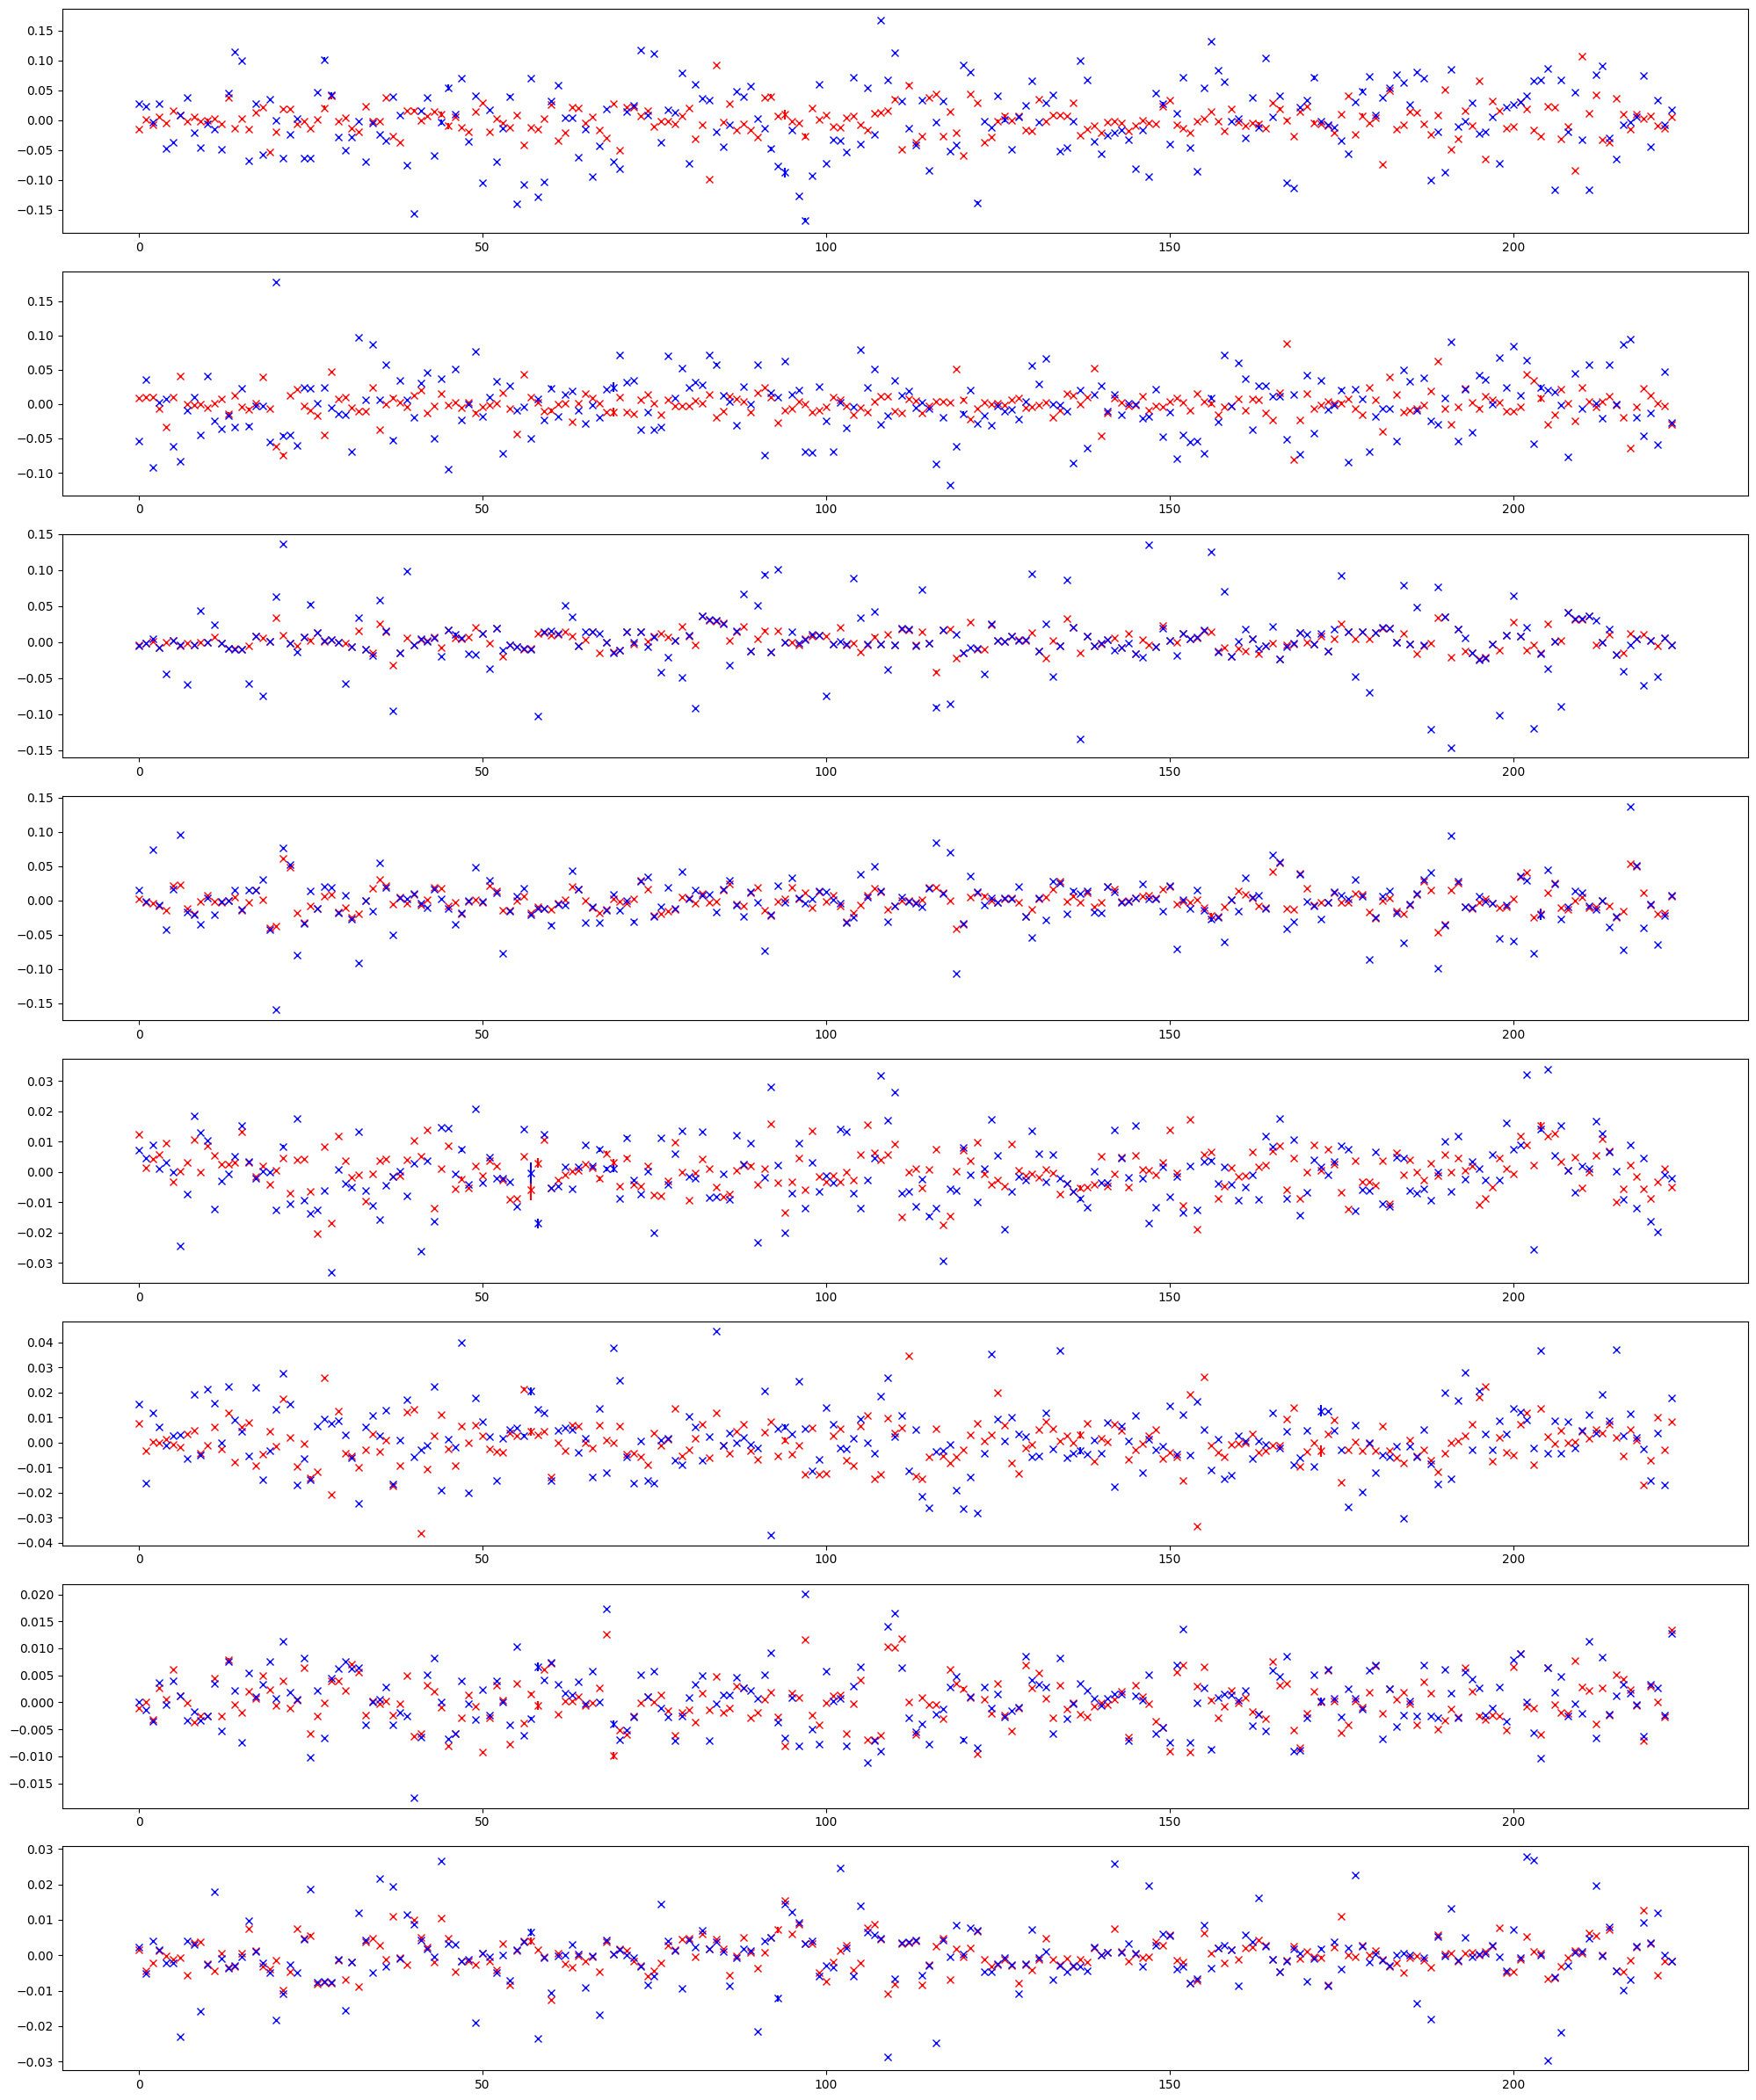

In [68]:
plt.figure(figsize=(20, 3*8))

ax = plt.subplot(811)
ax.errorbar(range(model.monitor_count), (n11 - value_n11).cpu().numpy(), yerr=error_n11.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n11_bpm - value_n11).cpu().numpy(), yerr=error_n11.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n11 - value_n11))
print(root_mean_square(n11_bpm - value_n11))
print()

ax = plt.subplot(812)
ax.errorbar(range(model.monitor_count), (n33 - value_n33).cpu().numpy(), yerr=error_n33.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n33_bpm - value_n33).cpu().numpy(), yerr=error_n33.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n33 - value_n33))
print(root_mean_square(n33_bpm - value_n33))
print()

ax = plt.subplot(813)
ax.errorbar(range(model.monitor_count), (n21 - value_n21).cpu().numpy(), yerr=error_n21.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n21_bpm - value_n21).cpu().numpy(), yerr=error_n21.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n21 - value_n21))
print(root_mean_square(n21_bpm - value_n21))
print()

ax = plt.subplot(814)
ax.errorbar(range(model.monitor_count), (n43 - value_n43).cpu().numpy(), yerr=error_n43.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n43_bpm - value_n43).cpu().numpy(), yerr=error_n43.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n43 - value_n43))
print(root_mean_square(n43_bpm - value_n43))
print()

ax = plt.subplot(815)
ax.errorbar(range(model.monitor_count), (n13 - value_n13).cpu().numpy(), yerr=error_n13.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n13_bpm - value_n13).cpu().numpy(), yerr=error_n13.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n13 - value_n13))
print(root_mean_square(n13_bpm - value_n13))
print()

ax = plt.subplot(816)
ax.errorbar(range(model.monitor_count), (n31 - value_n31).cpu().numpy(), yerr=error_n31.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n31_bpm - value_n31).cpu().numpy(), yerr=error_n31.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n31 - value_n31))
print(root_mean_square(n31_bpm - value_n31))
print()

ax = plt.subplot(817)
ax.errorbar(range(model.monitor_count), (n14 - value_n14).cpu().numpy(), yerr=error_n14.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n14_bpm - value_n14).cpu().numpy(), yerr=error_n14.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n14 - value_n14))
print(root_mean_square(n14_bpm - value_n14))
print()

ax = plt.subplot(818)
ax.errorbar(range(model.monitor_count), (n41 - value_n41).cpu().numpy(), yerr=error_n41.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n41_bpm - value_n41).cpu().numpy(), yerr=error_n41.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n41 - value_n41))
print(root_mean_square(n41_bpm - value_n41))
print()

plt.tight_layout()
plt.show()

In [69]:
# Estimate momenta at each monitor location

orbit = []
for location in range(model.monitor_count):
    orbit.append(twiss.get_momenta_lstsq(1, 256, location, 2, model.matrix))
orbit = torch.stack(orbit)
print(orbit.shape)

torch.Size([224, 4, 256])


In [70]:
# Use measured twiss to estimate invariants

s11, s33, s21, s43, s13, s31, s14, s41 = value.T
e11, e33, e21, e43, e13, e31, e14, e41 = error.T

BAG_IX = []
BAG_IY = []

for location in range(model.monitor_count):
    
    BAG_IX_MONITOR = []
    BAG_IY_MONITOR = []
    
    for _ in range(128):
        
        m11 = s11[location] + e11[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m33 = s33[location] + e33[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m21 = s21[location] + e21[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m43 = s43[location] + e43[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m13 = s13[location] + e13[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m31 = s31[location] + e31[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m14 = s14[location] + e14[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m41 = s41[location] + e41[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        
        normal = parametric_normal(m11, m33, m21, m43, m13, m31, m14, m41)
        
        QX, PX, QY, PY = normal.inverse() @ orbit[location]
        IX, IY = 0.5*(QX**2 + PX**2), 0.5*(QY**2 + PY**2)
        
        BAG_IX_MONITOR.append(IX)
        BAG_IY_MONITOR.append(IY)
        
    BAG_IX.append(BAG_IX_MONITOR)
    BAG_IY.append(BAG_IY_MONITOR)

BAG_IX = torch.stack([torch.stack(IX) for IX in BAG_IX]).reshape(model.monitor_count, -1)
BAG_IY = torch.stack([torch.stack(IY) for IY in BAG_IY]).reshape(model.monitor_count, -1)

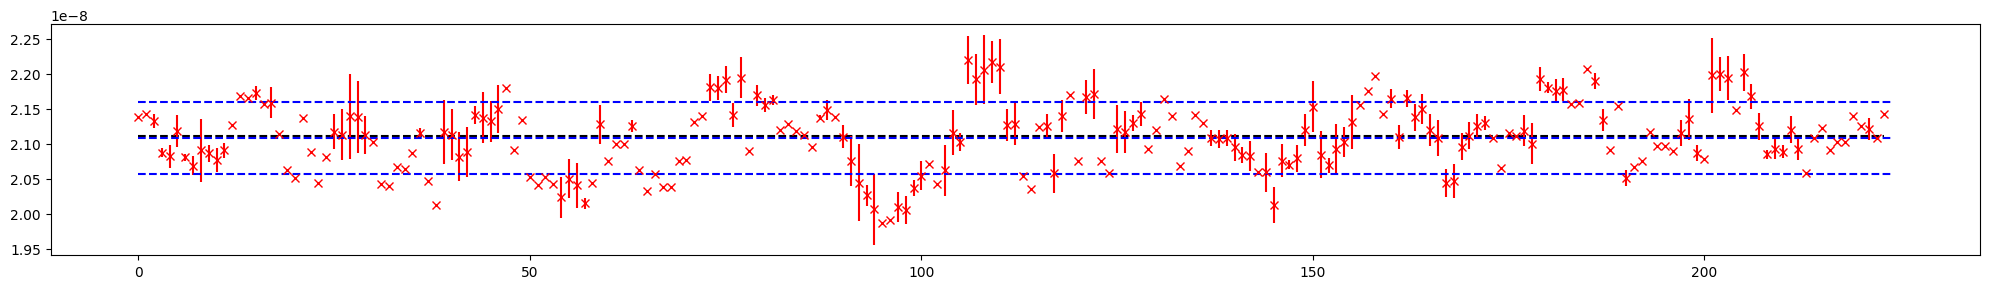

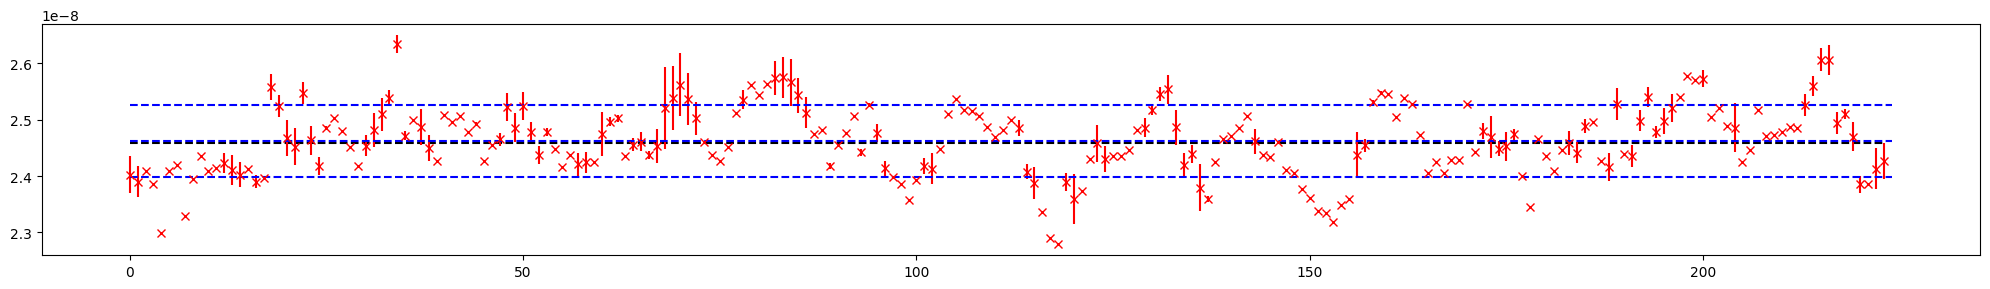

tensor(2.1113e-08, dtype=torch.float64)
tensor(2.0833e-08, dtype=torch.float64)
tensor(2.0833e-08, dtype=torch.float64)
tensor(2.1106e-08, dtype=torch.float64)
tensor(2.1085e-08, dtype=torch.float64)

tensor(2.4590e-08, dtype=torch.float64)
tensor(2.4301e-08, dtype=torch.float64)
tensor(2.4301e-08, dtype=torch.float64)
tensor(2.4624e-08, dtype=torch.float64)
tensor(2.4616e-08, dtype=torch.float64)



In [71]:
# Plot invariants for each monitor

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), BAG_IX.mean(-1).flatten().cpu().numpy(), yerr=BAG_IX.std(-1).cpu().numpy(), fmt=' ', color='red', marker='x')

plt.hlines(ix.mean(), 0, model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.hlines([BAG_IX.mean() - BAG_IX.std(), BAG_IX.mean(), BAG_IX.mean() + BAG_IX.std()], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), BAG_IY.mean(-1).flatten().cpu().numpy(), yerr=BAG_IY.std(-1).cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(iy.mean(), 0, model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.hlines([BAG_IY.mean() - BAG_IY.std(), BAG_IY.mean(), BAG_IY.mean() + BAG_IY.std()], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.tight_layout()
plt.show()

print(ix.mean())
print(twiss.action['center_jx'])
print(invariant['ix_value'])
print(ix_out.mean())
print(BAG_IX.mean())
print()

print(iy.mean())
print(twiss.action['center_jy'])
print(invariant['iy_value'])
print(iy_out.mean())
print(BAG_IY.mean())
print()

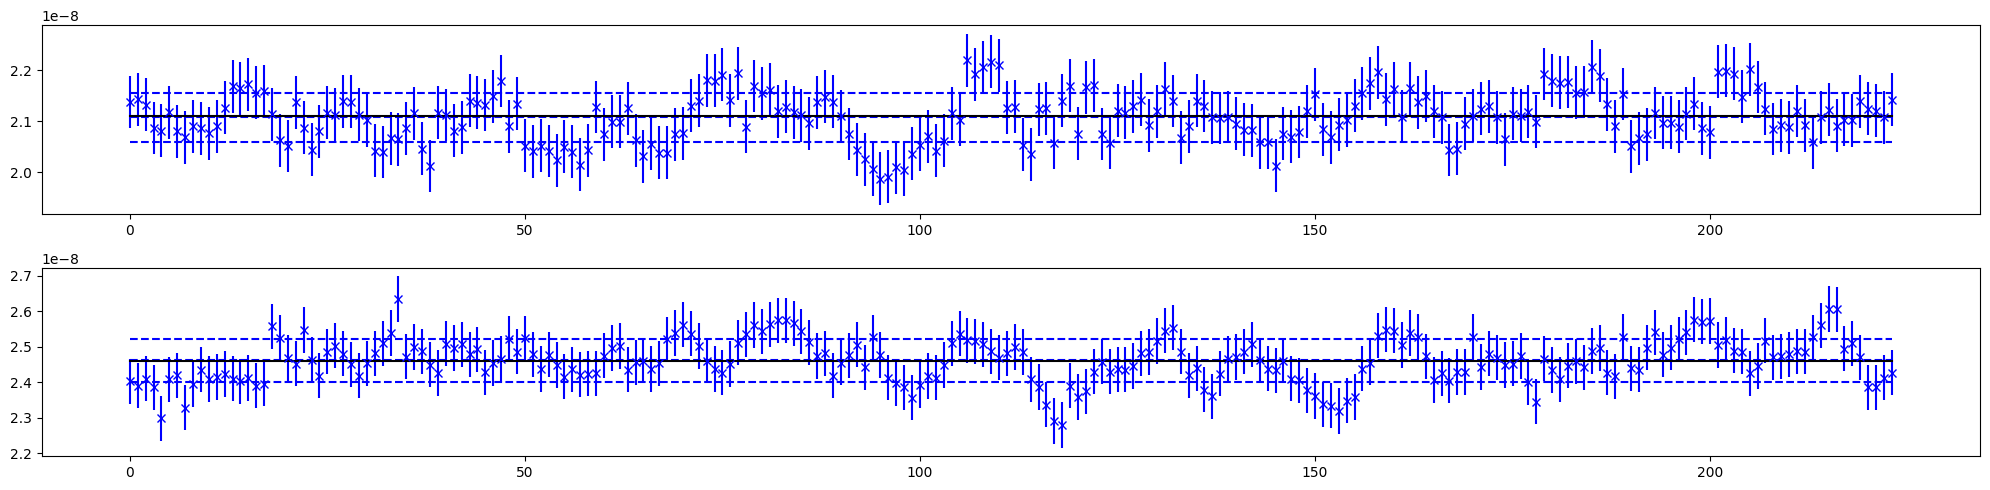

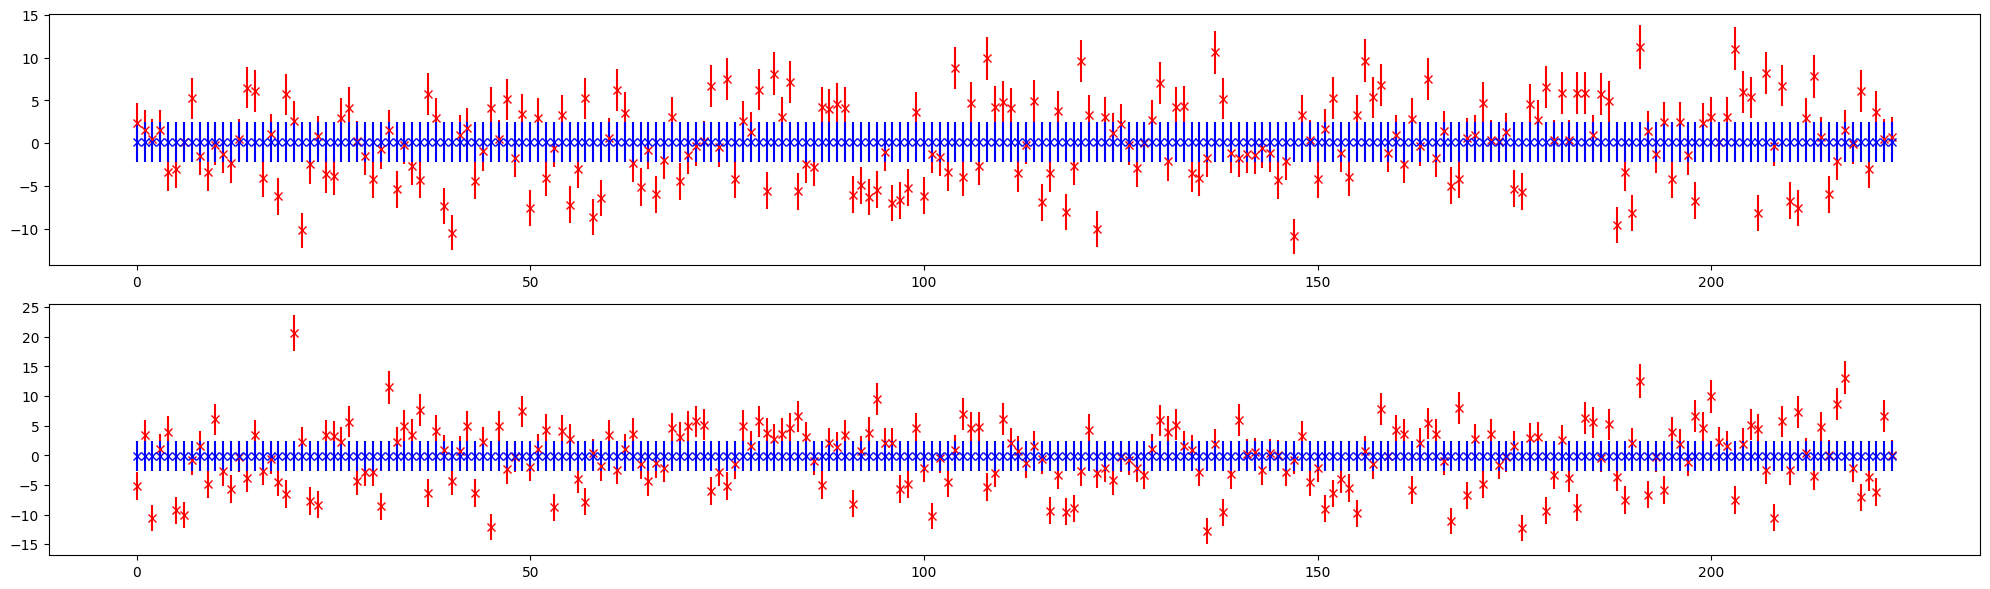

tensor(4.6422, dtype=torch.float64)
tensor(5.3168, dtype=torch.float64)

tensor(0.1301, dtype=torch.float64)
tensor(0.1069, dtype=torch.float64)



In [72]:
# Estimate twiss from amplitude (use invariants from coupled twiss)

twiss.get_action(jx=BAG_IX.mean(-1), jy=BAG_IY.mean(-1), sigma_jx=BAG_IX.std(), sigma_jy=BAG_IY.std())
twiss.get_twiss_from_amplitude()

# Compare estimated invariants

plt.figure(figsize=(20, 5))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), ix.cpu().numpy(), fmt='-', color='black')
ax.errorbar(range(model.monitor_count), twiss.action['jx'].cpu().numpy(), yerr=twiss.action['sigma_jx'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.hlines([(twiss.action['center_jx'] - twiss.action['spread_jx']).cpu().numpy(), twiss.action['center_jx'].cpu().numpy(), (twiss.action['center_jx'] + twiss.action['spread_jx']).cpu().numpy()], 0, model.monitor_count - 1, color='blue', linestyle='dashed')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), iy.cpu().numpy(), fmt='-', color='black')
ax.errorbar(range(model.monitor_count), twiss.action['jy'].cpu().numpy(), yerr=twiss.action['sigma_jy'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax.hlines([(twiss.action['center_jy'] - twiss.action['spread_jy']).cpu().numpy(), twiss.action['center_jy'].cpu().numpy(), (twiss.action['center_jy'] + twiss.action['spread_jy']).cpu().numpy()], 0, model.monitor_count - 1, color='blue', linestyle='dashed')
plt.tight_layout()
plt.show()

# Compare estimated twiss

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx)/bx).cpu().numpy(), yerr=100/bx*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['bx'] - bx_bpm)/bx_bpm).cpu().numpy(), yerr=100/bx_bpm*twiss.data_amplitude['sigma_bx'].cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by)/by).cpu().numpy(), yerr=100/by*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((twiss.data_amplitude['by'] - by_bpm)/by_bpm).cpu().numpy(), yerr=100/by_bpm*twiss.data_amplitude['sigma_by'].cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx)/bx)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by)/by)))
print()

print(root_mean_square(100*((twiss.data_amplitude['bx'] - bx_bpm)/bx_bpm)))
print(root_mean_square(100*((twiss.data_amplitude['by'] - by_bpm)/by_bpm)))
print()

In [73]:
%%time

# Estimate twiss from invariant fit (fixed invariants)

count = 8

data = twiss.get_twiss_from_data(1,                # -- first turn
                                 256,              # -- total number of turns, orbits are computed for (start, start + total)
                                 parametric_normal,# -- normalization
                                 model.matrix,     # -- transport matrix generator
                                 twiss=None,       # -- initial twiss for each location or None (use model values)
                                 method='lstsq',   # -- momenta computation method
                                 limit=2,          # -- range limit or direction/shift
                                 product=True,     # -- flag to use product objective
                                 jacobian=False,   # -- flag to use objective jacobian
                                 count=count,      # -- number of samples
                                 fraction=0.75,    # -- sample length fraction
                                 ix=BAG_IX.mean(), # -- ix invariant value
                                 iy=BAG_IY.mean(), # -- iy invariant value  (both should present for fixed fit)
                                 n_jobs=4,         # -- number of parallel jobs (loop over samples)
                                 verbose=False)    # -- verbose flag

CPU times: user 8min 38s, sys: 1min 24s, total: 10min 2s
Wall time: 12min 15s


In [74]:
# Process twiss

value_n11 = data[:, 0, 0]
error_n11 = data[:, 1, 0]

value_n33 = data[:, 0, 1]
error_n33 = data[:, 1, 1]

value_n21 = data[:, 0, 2]
error_n21 = data[:, 1, 2]

value_n43 = data[:, 0, 3]
error_n43 = data[:, 1, 3]

value_n13 = data[:, 0, 4]
error_n13 = data[:, 1, 4]

value_n31 = data[:, 0, 5]
error_n31 = data[:, 1, 5]

value_n14 = data[:, 0, 6]
error_n14 = data[:, 1, 6]

value_n41 = data[:, 0, 7]
error_n41 = data[:, 1, 7]

value_n11, error_n11 = twiss.process(value_n11, error_n11)
value_n33, error_n33 = twiss.process(value_n33, error_n33)
value_n21, error_n21 = twiss.process(value_n21, error_n21)
value_n43, error_n43 = twiss.process(value_n43, error_n43)
value_n13, error_n13 = twiss.process(value_n13, error_n13)
value_n31, error_n31 = twiss.process(value_n31, error_n31)
value_n14, error_n14 = twiss.process(value_n14, error_n14)
value_n41, error_n41 = twiss.process(value_n41, error_n41)

value = torch.stack([value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41]).T
error = torch.stack([error_n11, error_n33, error_n21, error_n43, error_n13, error_n31, error_n14, error_n41]).T

cs_value, cs_error = [], []

for value_loc, error_loc in zip(value, error):
    table = value_loc.reshape(-1, 1) + error_loc.reshape(-1, 1)*torch.randn(1024, dtype=dtype, device=device)
    table = torch.stack([parametric_normal(*free) for free in table.T])
    table = normal_to_wolski(table)
    table = torch.stack([wolski_to_cs(w) for w in table]).T
    cs_value.append(table.mean(-1))
    cs_error.append(table.std(-1))
    
cs_value = torch.stack(cs_value)
cs_error = torch.stack(cs_error)

value_ax, value_bx, value_ay, value_by = cs_value.T
error_ax, error_bx, error_ay, error_by = cs_error.T

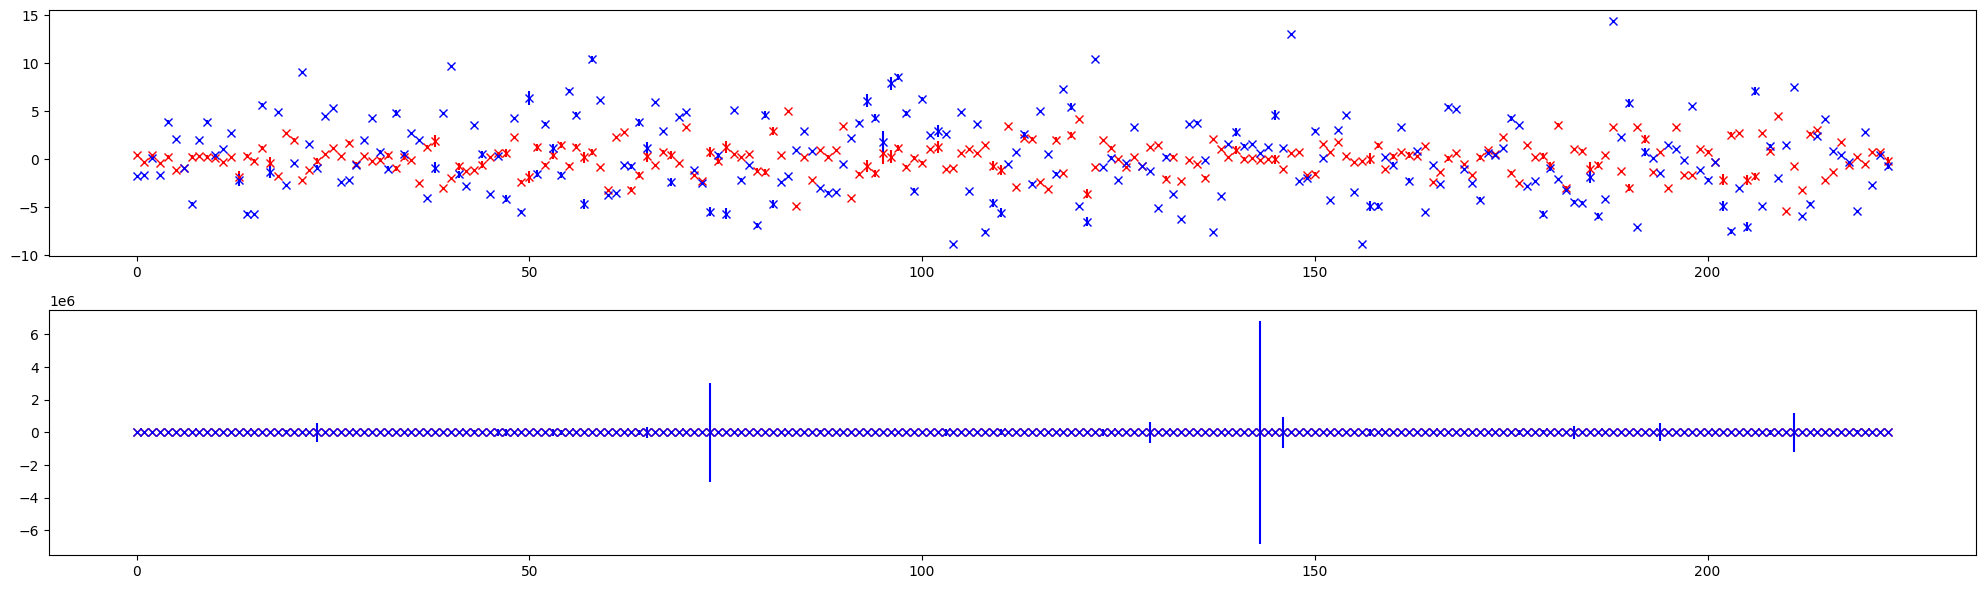

tensor(1.6892, dtype=torch.float64)
tensor(1.8373, dtype=torch.float64)

tensor(4.1468, dtype=torch.float64)
tensor(4.6418, dtype=torch.float64)



In [75]:
# Compare beta function values

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((value_bx - bx)/bx).cpu().numpy(), yerr=100/bx*error_bx.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((value_bx - bx_bpm)/bx_bpm).cpu().numpy(), yerr=100/bx_bpm*error_bx.cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((value_by - by)/by).cpu().numpy(), yerr=100/by*error_by.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((value_by - by_bpm)/by_bpm).cpu().numpy(), yerr=100/error_by.cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((value_bx - bx)/bx)))
print(root_mean_square(100*((value_by - by)/by)))
print()

print(root_mean_square(100*((value_bx - bx_bpm)/bx_bpm)))
print(root_mean_square(100*((value_by - by_bpm)/by_bpm)))
print()

tensor(0.0261, dtype=torch.float64)
tensor(0.0581, dtype=torch.float64)

tensor(0.0202, dtype=torch.float64)
tensor(0.0430, dtype=torch.float64)

tensor(0.0142, dtype=torch.float64)
tensor(0.0417, dtype=torch.float64)

tensor(0.0176, dtype=torch.float64)
tensor(0.0356, dtype=torch.float64)

tensor(0.0179, dtype=torch.float64)
tensor(0.0208, dtype=torch.float64)

tensor(0.0136, dtype=torch.float64)
tensor(0.0170, dtype=torch.float64)

tensor(0.0196, dtype=torch.float64)
tensor(0.0200, dtype=torch.float64)

tensor(0.0076, dtype=torch.float64)
tensor(0.0106, dtype=torch.float64)



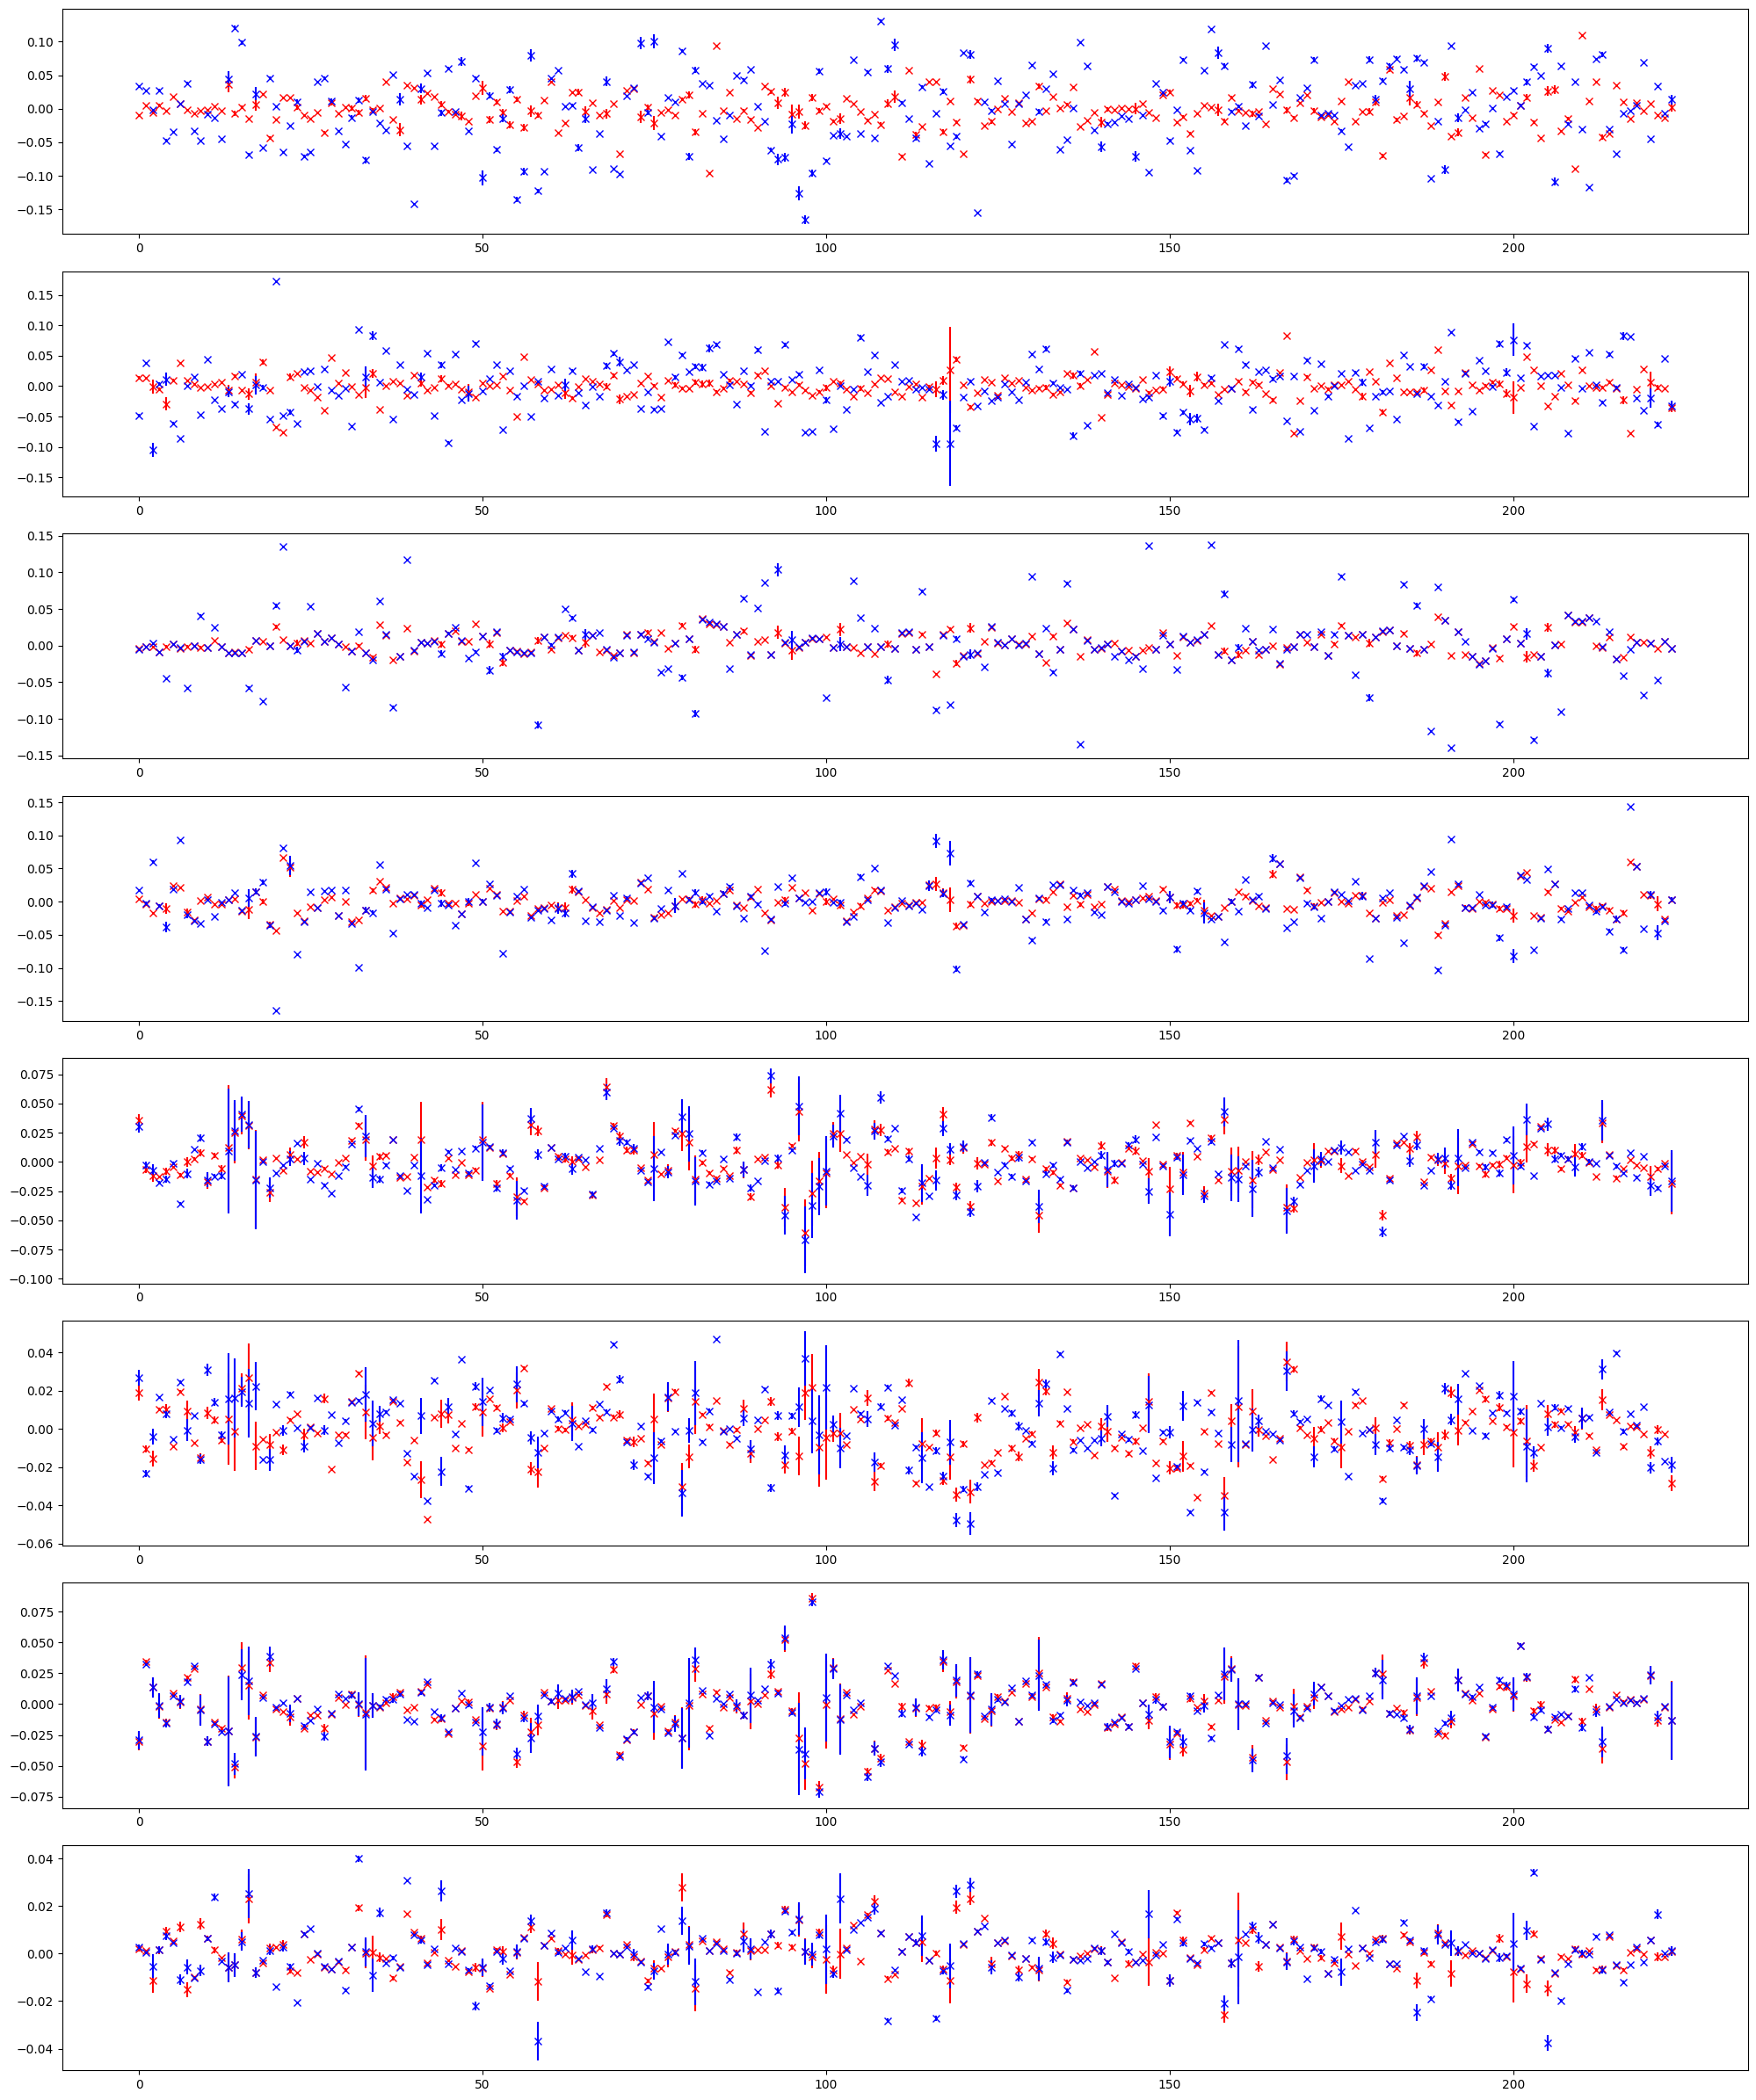

In [76]:
# Compare estimated normalization matrix elements

plt.figure(figsize=(20, 3*8))

ax = plt.subplot(811)
ax.errorbar(range(model.monitor_count), (n11 - value_n11).cpu().numpy(), yerr=error_n11.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n11_bpm - value_n11).cpu().numpy(), yerr=error_n11.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n11 - value_n11))
print(root_mean_square(n11_bpm - value_n11))
print()

ax = plt.subplot(812)
ax.errorbar(range(model.monitor_count), (n33 - value_n33).cpu().numpy(), yerr=error_n33.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n33_bpm - value_n33).cpu().numpy(), yerr=error_n33.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n33 - value_n33))
print(root_mean_square(n33_bpm - value_n33))
print()

ax = plt.subplot(813)
ax.errorbar(range(model.monitor_count), (n21 - value_n21).cpu().numpy(), yerr=error_n21.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n21_bpm - value_n21).cpu().numpy(), yerr=error_n21.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n21 - value_n21))
print(root_mean_square(n21_bpm - value_n21))
print()

ax = plt.subplot(814)
ax.errorbar(range(model.monitor_count), (n43 - value_n43).cpu().numpy(), yerr=error_n43.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n43_bpm - value_n43).cpu().numpy(), yerr=error_n43.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n43 - value_n43))
print(root_mean_square(n43_bpm - value_n43))
print()

ax = plt.subplot(815)
ax.errorbar(range(model.monitor_count), (n13 - value_n13).cpu().numpy(), yerr=error_n13.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n13_bpm - value_n13).cpu().numpy(), yerr=error_n13.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n13 - value_n13))
print(root_mean_square(n13_bpm - value_n13))
print()

ax = plt.subplot(816)
ax.errorbar(range(model.monitor_count), (n31 - value_n31).cpu().numpy(), yerr=error_n31.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n31_bpm - value_n31).cpu().numpy(), yerr=error_n31.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n31 - value_n31))
print(root_mean_square(n31_bpm - value_n31))
print()

ax = plt.subplot(817)
ax.errorbar(range(model.monitor_count), (n14 - value_n14).cpu().numpy(), yerr=error_n14.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n14_bpm - value_n14).cpu().numpy(), yerr=error_n14.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n14 - value_n14))
print(root_mean_square(n14_bpm - value_n14))
print()

ax = plt.subplot(818)
ax.errorbar(range(model.monitor_count), (n41 - value_n41).cpu().numpy(), yerr=error_n41.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n41_bpm - value_n41).cpu().numpy(), yerr=error_n41.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n41 - value_n41))
print(root_mean_square(n41_bpm - value_n41))
print()

plt.tight_layout()
plt.show()

In [77]:
# Estimate momenta at each monitor location

orbit = []
for location in range(model.monitor_count):
    orbit.append(twiss.get_momenta_lstsq(1, 256, location, 2, model.matrix))
orbit = torch.stack(orbit)
print(orbit.shape)

torch.Size([224, 4, 256])


In [78]:
# Use measured twiss to estimate invariants

s11, s33, s21, s43, s13, s31, s14, s41 = value.T
e11, e33, e21, e43, e13, e31, e14, e41 = error.T

BAG_IX = []
BAG_IY = []

for location in range(model.monitor_count):
    
    BAG_IX_MONITOR = []
    BAG_IY_MONITOR = []
    
    for _ in range(128):
        
        m11 = s11[location] + e11[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m33 = s33[location] + e33[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m21 = s21[location] + e21[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m43 = s43[location] + e43[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m13 = s13[location] + e13[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m31 = s31[location] + e31[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m14 = s14[location] + e14[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m41 = s41[location] + e41[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        
        normal = parametric_normal(m11, m33, m21, m43, m13, m31, m14, m41)
        
        QX, PX, QY, PY = normal.inverse() @ orbit[location]
        IX, IY = 0.5*(QX**2 + PX**2), 0.5*(QY**2 + PY**2)
        
        BAG_IX_MONITOR.append(IX)
        BAG_IY_MONITOR.append(IY)
        
    BAG_IX.append(BAG_IX_MONITOR)
    BAG_IY.append(BAG_IY_MONITOR)

BAG_IX = torch.stack([torch.stack(IX) for IX in BAG_IX]).reshape(model.monitor_count, -1)
BAG_IY = torch.stack([torch.stack(IY) for IY in BAG_IY]).reshape(model.monitor_count, -1)

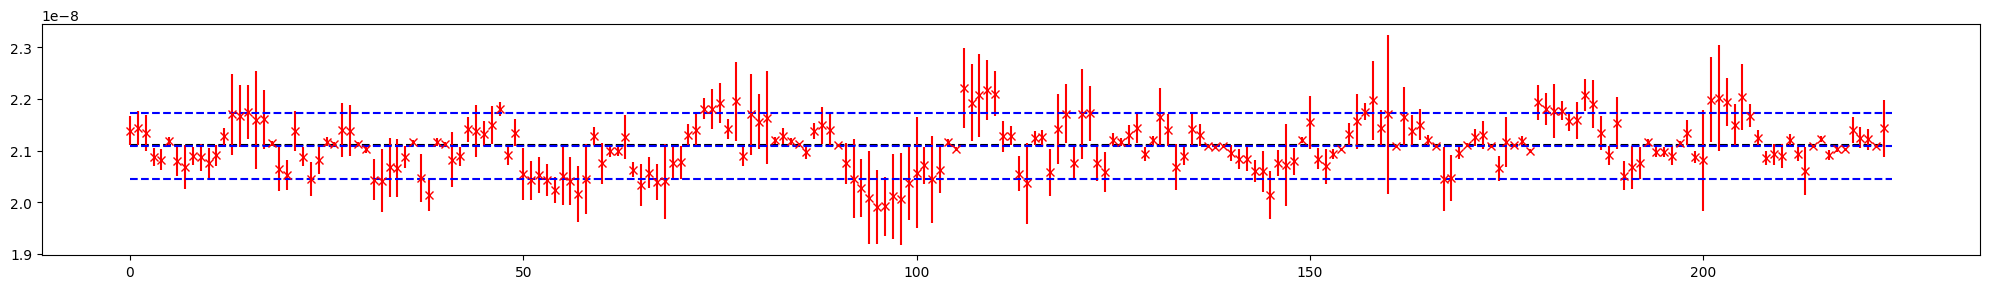

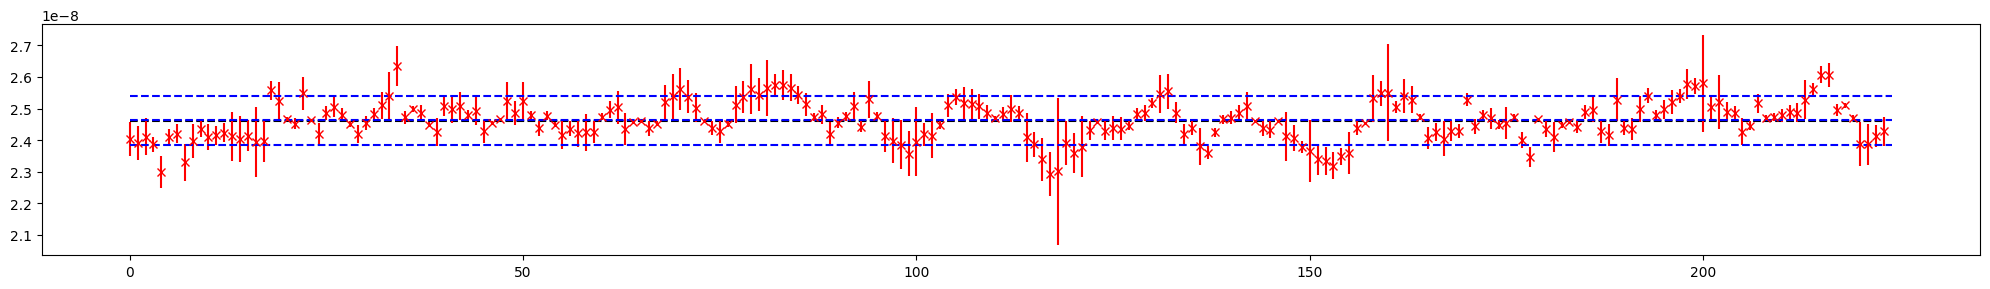

tensor(2.1113e-08, dtype=torch.float64)
tensor(2.1085e-08, dtype=torch.float64)
tensor(2.0833e-08, dtype=torch.float64)
tensor(2.1089e-08, dtype=torch.float64)

tensor(2.4590e-08, dtype=torch.float64)
tensor(2.4616e-08, dtype=torch.float64)
tensor(2.4301e-08, dtype=torch.float64)
tensor(2.4621e-08, dtype=torch.float64)



In [79]:
# Plot invariants for each monitor

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), BAG_IX.mean(-1).flatten().cpu().numpy(), yerr=BAG_IX.std(-1).cpu().numpy(), fmt=' ', color='red', marker='x')

plt.hlines(ix.mean(), 0, model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.hlines([BAG_IX.mean() - BAG_IX.std(), BAG_IX.mean(), BAG_IX.mean() + BAG_IX.std()], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), BAG_IY.mean(-1).flatten().cpu().numpy(), yerr=BAG_IY.std(-1).cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(iy.mean(), 0, model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.hlines([BAG_IY.mean() - BAG_IY.std(), BAG_IY.mean(), BAG_IY.mean() + BAG_IY.std()], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.tight_layout()
plt.show()

print(ix.mean())
print(twiss.action['center_jx'])
print(invariant['ix_value'])
print(BAG_IX.mean())
print()

print(iy.mean())
print(twiss.action['center_jy'])
print(invariant['iy_value'])
print(BAG_IY.mean())
print()

## Twiss from ratio fit

In [80]:
%%time

window = Window.cosine_window(128, 1.0, dtype=dtype, device=device)

data = twiss.get_twiss_from_ratio(1, 256, window, nux_bpm, nuy_bpm, parametric_normal, model.matrix, limit=2, method='lstsq', step=16, verbose=False, n_jobs=4)

CPU times: user 11min 4s, sys: 1min 49s, total: 12min 54s
Wall time: 18min 49s


In [81]:
# Process twiss

value_n11 = data[:, 0, 0]
error_n11 = data[:, 1, 0]

value_n33 = data[:, 0, 1]
error_n33 = data[:, 1, 1]

value_n21 = data[:, 0, 2]
error_n21 = data[:, 1, 2]

value_n43 = data[:, 0, 3]
error_n43 = data[:, 1, 3]

value_n13 = data[:, 0, 4]
error_n13 = data[:, 1, 4]

value_n31 = data[:, 0, 5]
error_n31 = data[:, 1, 5]

value_n14 = data[:, 0, 6]
error_n14 = data[:, 1, 6]

value_n41 = data[:, 0, 7]
error_n41 = data[:, 1, 7]

value_n11, error_n11 = twiss.process(value_n11, error_n11)
value_n33, error_n33 = twiss.process(value_n33, error_n33)
value_n21, error_n21 = twiss.process(value_n21, error_n21)
value_n43, error_n43 = twiss.process(value_n43, error_n43)
value_n13, error_n13 = twiss.process(value_n13, error_n13)
value_n31, error_n31 = twiss.process(value_n31, error_n31)
value_n14, error_n14 = twiss.process(value_n14, error_n14)
value_n41, error_n41 = twiss.process(value_n41, error_n41)

value = torch.stack([value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41]).T
error = torch.stack([error_n11, error_n33, error_n21, error_n43, error_n13, error_n31, error_n14, error_n41]).T

cs_value, cs_error = [], []

for value_loc, error_loc in zip(value, error):
    table = value_loc.reshape(-1, 1) + error_loc.reshape(-1, 1)*torch.randn(1024, dtype=dtype, device=device)
    table = torch.stack([parametric_normal(*free) for free in table.T])
    table = normal_to_wolski(table)
    table = torch.stack([wolski_to_cs(w) for w in table]).T
    cs_value.append(table.mean(-1))
    cs_error.append(table.std(-1))
    
cs_value = torch.stack(cs_value)
cs_error = torch.stack(cs_error)

value_ax, value_bx, value_ay, value_by = cs_value.T
error_ax, error_bx, error_ay, error_by = cs_error.T

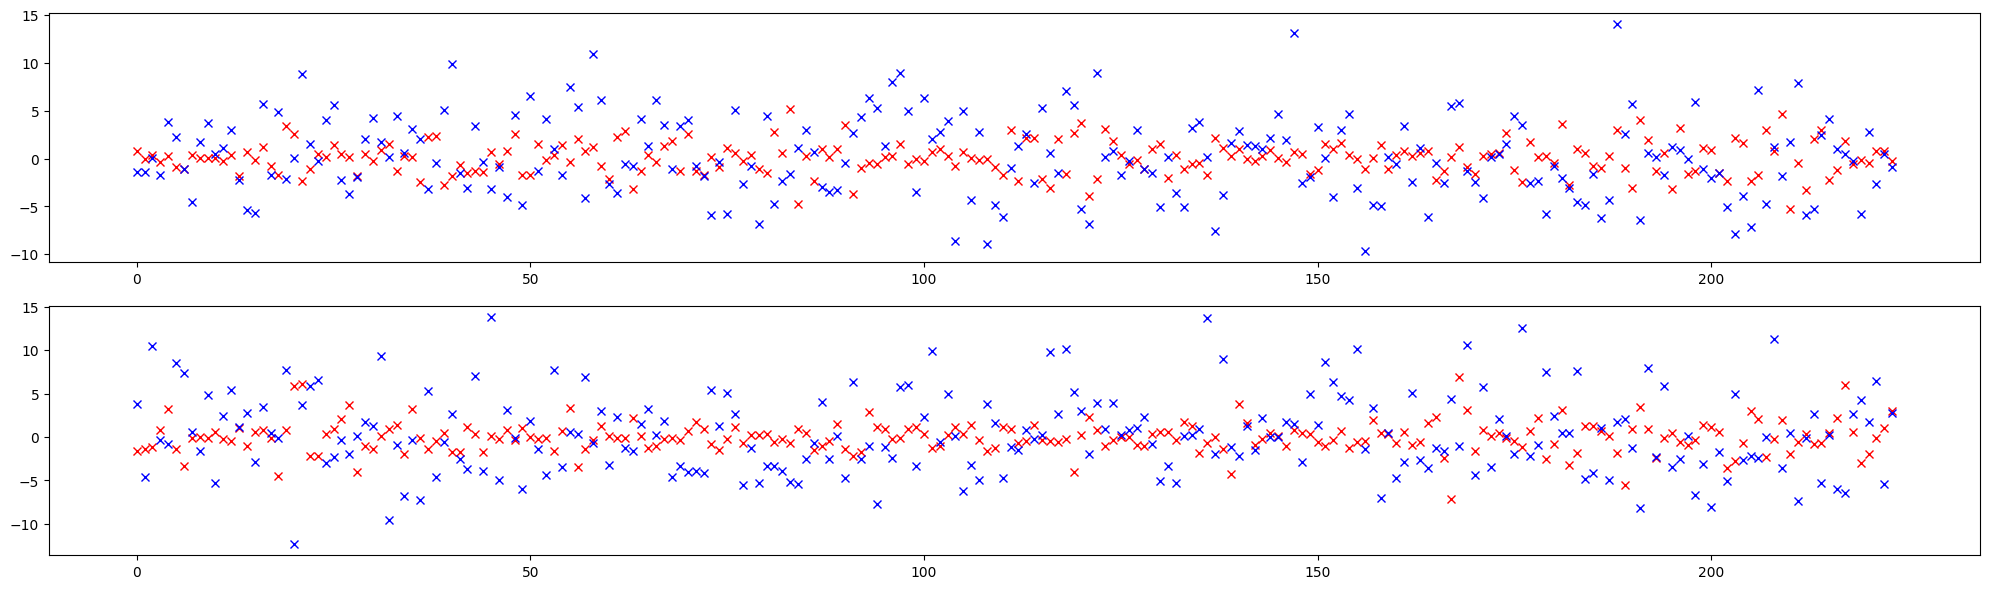

tensor(1.6890, dtype=torch.float64)
tensor(1.7952, dtype=torch.float64)

tensor(4.1913, dtype=torch.float64)
tensor(4.6371, dtype=torch.float64)



In [82]:
# Compare beta function values

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((value_bx - bx)/bx).cpu().numpy(), yerr=100/bx*error_bx.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((value_bx - bx_bpm)/bx_bpm).cpu().numpy(), yerr=100/bx_bpm*error_bx.cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((value_by - by)/by).cpu().numpy(), yerr=100/by*error_by.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((value_by - by_bpm)/by_bpm).cpu().numpy(), yerr=100/by_bpm*error_by.cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((value_bx - bx)/bx)))
print(root_mean_square(100*((value_by - by)/by)))
print()

print(root_mean_square(100*((value_bx - bx_bpm)/bx_bpm)))
print(root_mean_square(100*((value_by - by_bpm)/by_bpm)))
print()

tensor(0.0260, dtype=torch.float64)
tensor(0.0592, dtype=torch.float64)

tensor(0.0200, dtype=torch.float64)
tensor(0.0429, dtype=torch.float64)

tensor(0.0141, dtype=torch.float64)
tensor(0.0416, dtype=torch.float64)

tensor(0.0176, dtype=torch.float64)
tensor(0.0356, dtype=torch.float64)

tensor(0.0054, dtype=torch.float64)
tensor(0.0084, dtype=torch.float64)

tensor(0.0091, dtype=torch.float64)
tensor(0.0159, dtype=torch.float64)

tensor(0.0042, dtype=torch.float64)
tensor(0.0051, dtype=torch.float64)

tensor(0.0049, dtype=torch.float64)
tensor(0.0087, dtype=torch.float64)



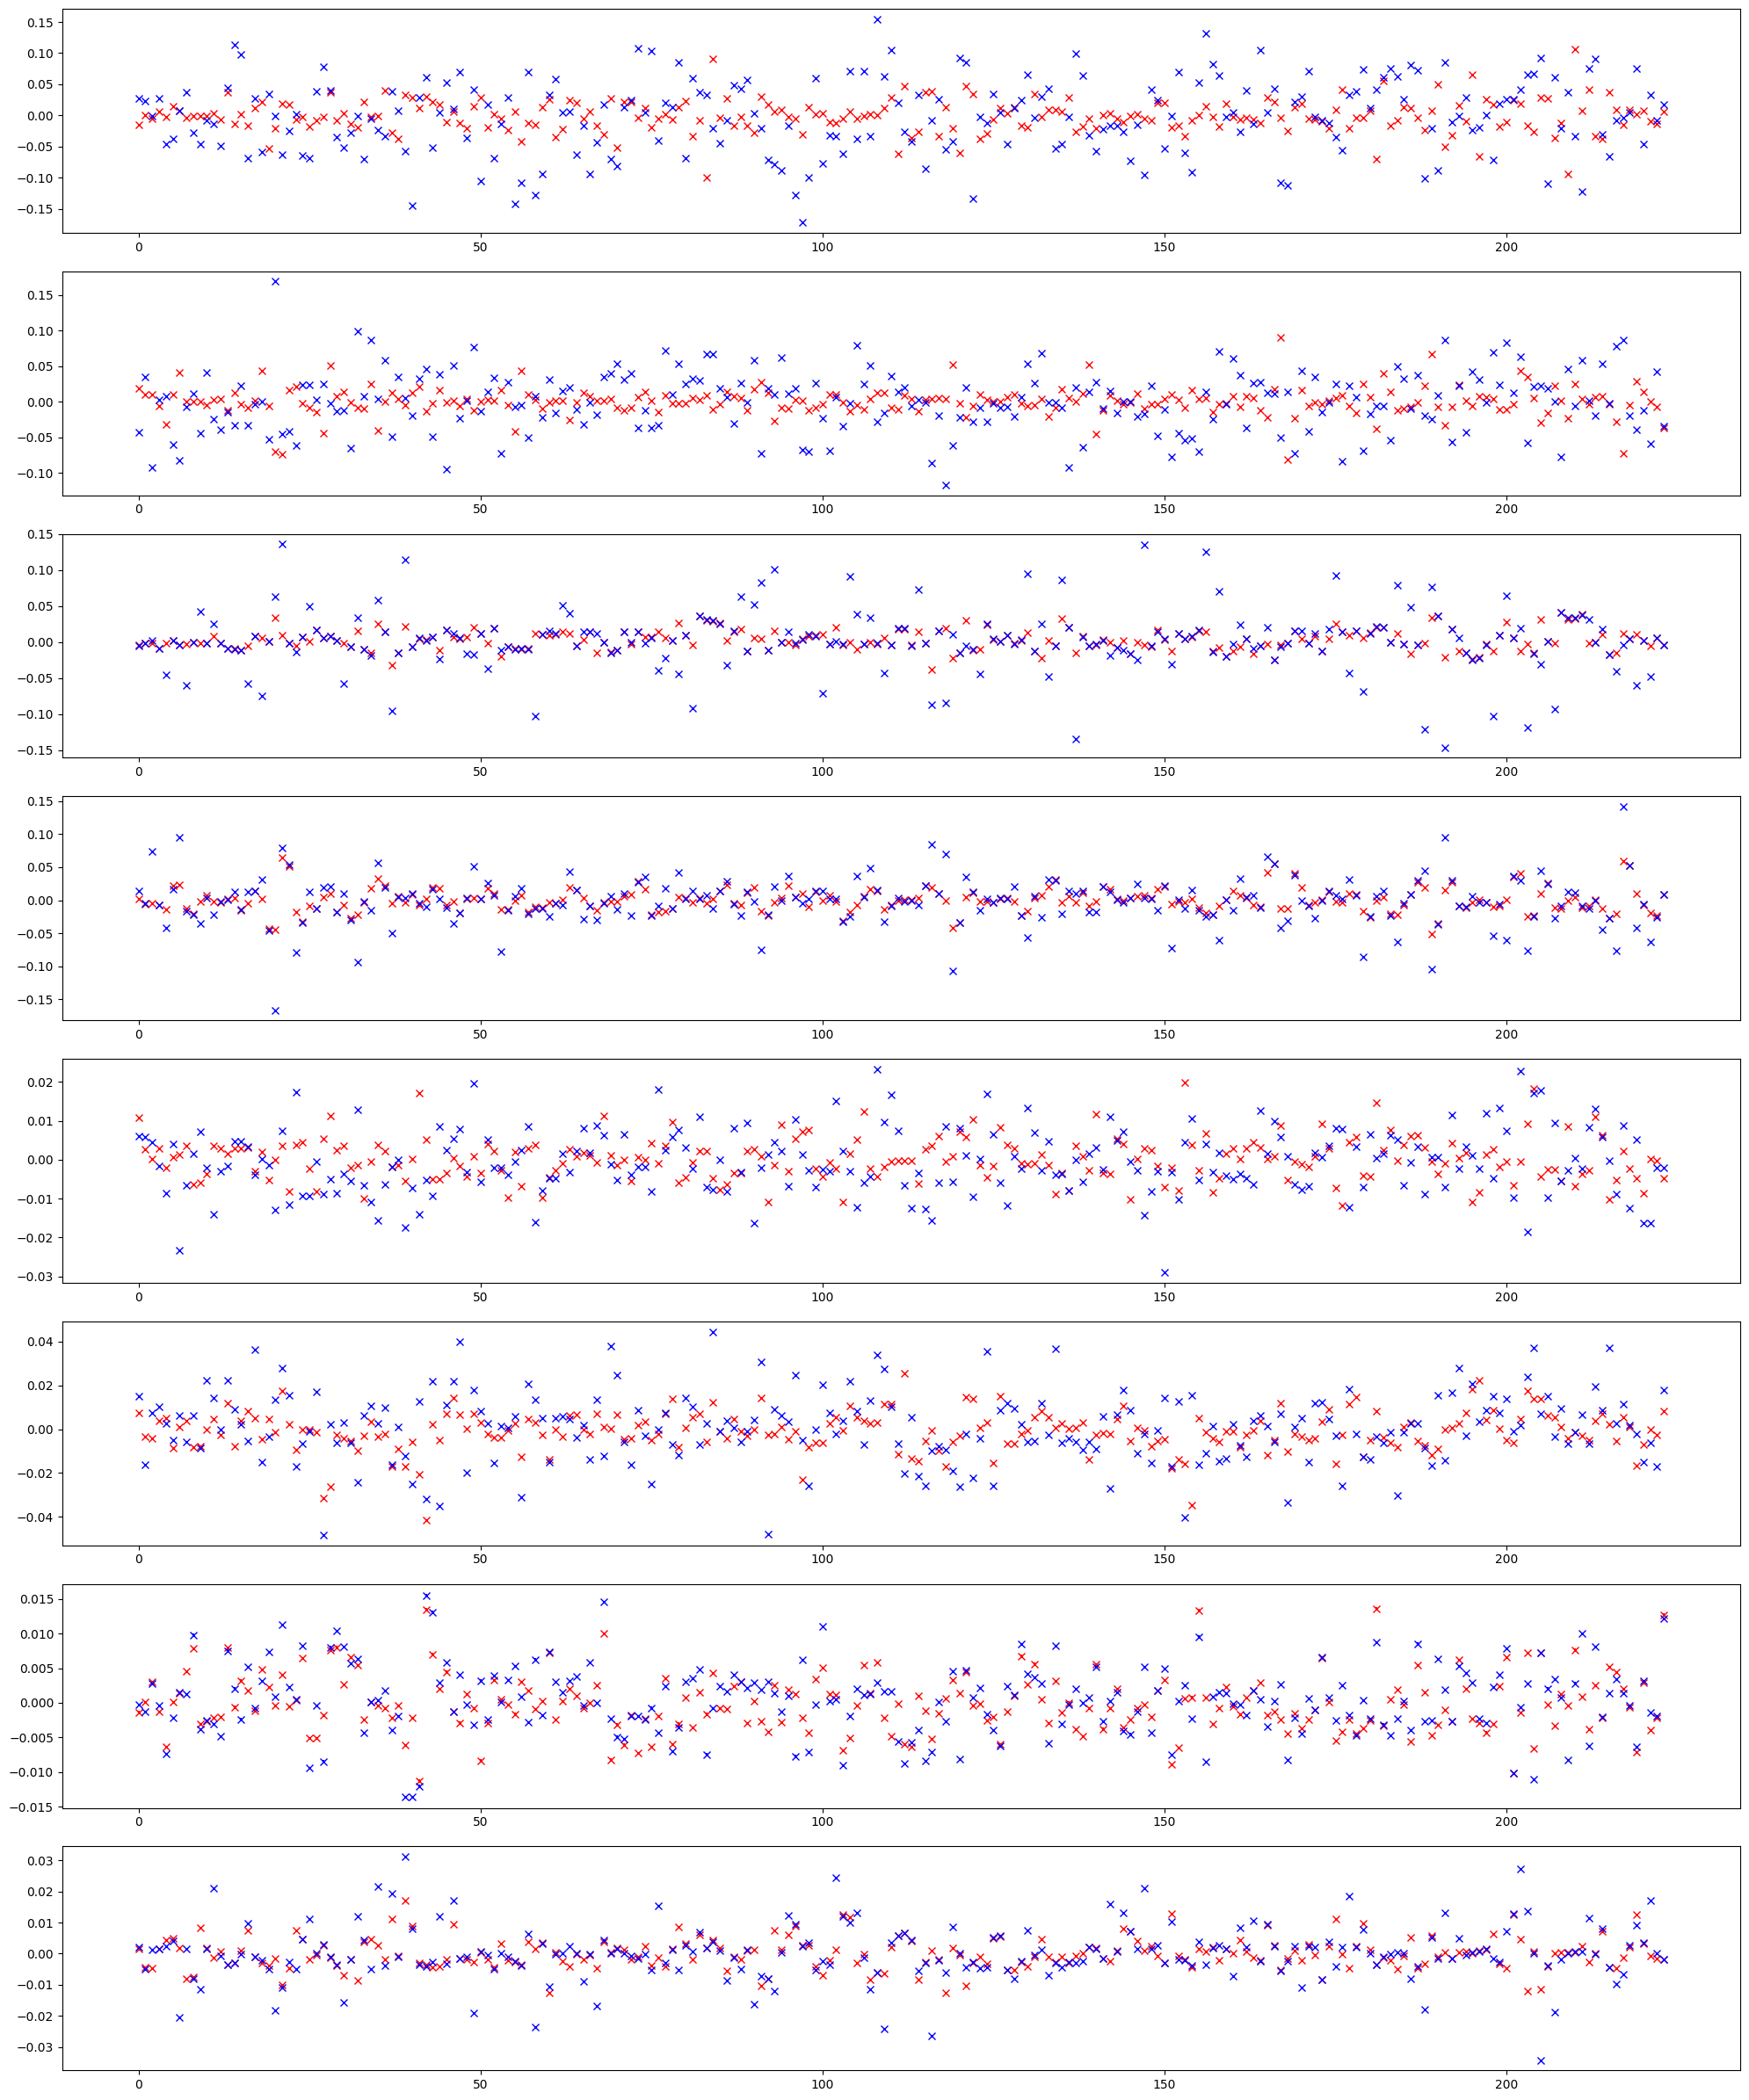

In [83]:
# Compare estimated normalization matrix elements

plt.figure(figsize=(20, 3*8))

ax = plt.subplot(811)
ax.errorbar(range(model.monitor_count), (n11 - value_n11).cpu().numpy(), yerr=error_n11.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n11_bpm - value_n11).cpu().numpy(), yerr=error_n11.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n11 - value_n11))
print(root_mean_square(n11_bpm - value_n11))
print()

ax = plt.subplot(812)
ax.errorbar(range(model.monitor_count), (n33 - value_n33).cpu().numpy(), yerr=error_n33.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n33_bpm - value_n33).cpu().numpy(), yerr=error_n33.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n33 - value_n33))
print(root_mean_square(n33_bpm - value_n33))
print()

ax = plt.subplot(813)
ax.errorbar(range(model.monitor_count), (n21 - value_n21).cpu().numpy(), yerr=error_n21.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n21_bpm - value_n21).cpu().numpy(), yerr=error_n21.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n21 - value_n21))
print(root_mean_square(n21_bpm - value_n21))
print()

ax = plt.subplot(814)
ax.errorbar(range(model.monitor_count), (n43 - value_n43).cpu().numpy(), yerr=error_n43.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n43_bpm - value_n43).cpu().numpy(), yerr=error_n43.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n43 - value_n43))
print(root_mean_square(n43_bpm - value_n43))
print()

ax = plt.subplot(815)
ax.errorbar(range(model.monitor_count), (n13 - value_n13).cpu().numpy(), yerr=error_n13.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n13_bpm - value_n13).cpu().numpy(), yerr=error_n13.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n13 - value_n13))
print(root_mean_square(n13_bpm - value_n13))
print()

ax = plt.subplot(816)
ax.errorbar(range(model.monitor_count), (n31 - value_n31).cpu().numpy(), yerr=error_n31.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n31_bpm - value_n31).cpu().numpy(), yerr=error_n31.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n31 - value_n31))
print(root_mean_square(n31_bpm - value_n31))
print()

ax = plt.subplot(817)
ax.errorbar(range(model.monitor_count), (n14 - value_n14).cpu().numpy(), yerr=error_n14.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n14_bpm - value_n14).cpu().numpy(), yerr=error_n14.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n14 - value_n14))
print(root_mean_square(n14_bpm - value_n14))
print()

ax = plt.subplot(818)
ax.errorbar(range(model.monitor_count), (n41 - value_n41).cpu().numpy(), yerr=error_n41.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n41_bpm - value_n41).cpu().numpy(), yerr=error_n41.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n41 - value_n41))
print(root_mean_square(n41_bpm - value_n41))
print()

plt.tight_layout()
plt.show()

In [84]:
# Estimate momenta at each monitor location

orbit = []
for location in range(model.monitor_count):
    orbit.append(twiss.get_momenta_lstsq(1, 256, location, 2, model.matrix))
orbit = torch.stack(orbit)
print(orbit.shape)

torch.Size([224, 4, 256])


In [85]:
# Use measured twiss to estimate invariants

s11, s33, s21, s43, s13, s31, s14, s41 = value.T
e11, e33, e21, e43, e13, e31, e14, e41 = error.T

BAG_IX = []
BAG_IY = []

for location in range(model.monitor_count):
    
    BAG_IX_MONITOR = []
    BAG_IY_MONITOR = []
    
    for _ in range(128):
        
        m11 = s11[location] + e11[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m33 = s33[location] + e33[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m21 = s21[location] + e21[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m43 = s43[location] + e43[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m13 = s13[location] + e13[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m31 = s31[location] + e31[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m14 = s14[location] + e14[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m41 = s41[location] + e41[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        
        normal = parametric_normal(m11, m33, m21, m43, m13, m31, m14, m41)
        
        QX, PX, QY, PY = normal.inverse() @ orbit[location]
        IX, IY = 0.5*(QX**2 + PX**2), 0.5*(QY**2 + PY**2)
        
        BAG_IX_MONITOR.append(IX)
        BAG_IY_MONITOR.append(IY)
        
    BAG_IX.append(BAG_IX_MONITOR)
    BAG_IY.append(BAG_IY_MONITOR)

BAG_IX = torch.stack([torch.stack(IX) for IX in BAG_IX]).reshape(model.monitor_count, -1)
BAG_IY = torch.stack([torch.stack(IY) for IY in BAG_IY]).reshape(model.monitor_count, -1)

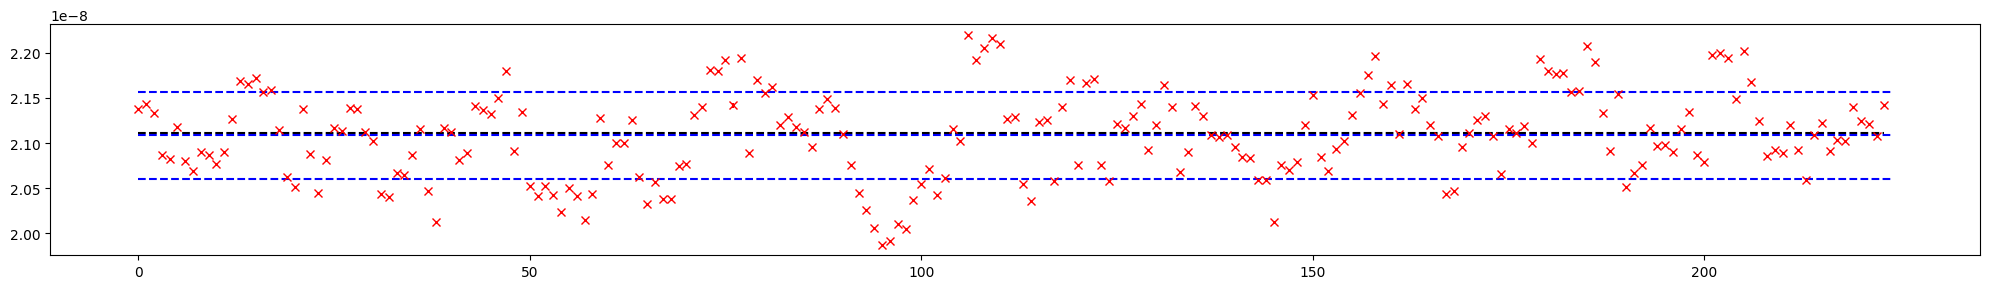

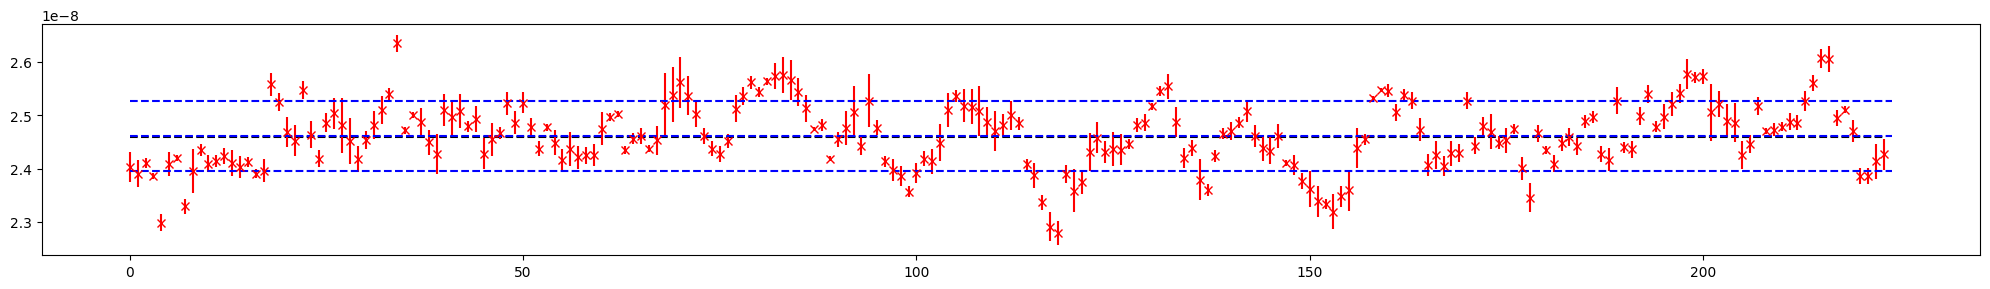

tensor(2.1113e-08, dtype=torch.float64)
tensor(2.1085e-08, dtype=torch.float64)

tensor(2.4590e-08, dtype=torch.float64)
tensor(2.4616e-08, dtype=torch.float64)



In [86]:
# Plot invariants for each monitor

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), BAG_IX.mean(-1).flatten().cpu().numpy(), yerr=BAG_IX.std(-1).cpu().numpy(), fmt=' ', color='red', marker='x')

plt.hlines(ix.mean(), 0, model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.hlines([BAG_IX.mean() - BAG_IX.std(), BAG_IX.mean(), BAG_IX.mean() + BAG_IX.std()], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), BAG_IY.mean(-1).flatten().cpu().numpy(), yerr=BAG_IY.std(-1).cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(iy.mean(), 0, model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.hlines([BAG_IY.mean() - BAG_IY.std(), BAG_IY.mean(), BAG_IY.mean() + BAG_IY.std()], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.tight_layout()
plt.show()

print(ix.mean())
print(BAG_IX.mean())
print()

print(iy.mean())
print(BAG_IY.mean())
print()

## Twiss from one-turn matrix fit

In [87]:
data = twiss.get_twiss_from_matrix(1, 512, model.matrix, power=1, limit=2, method='lstsq', count=512, fraction=0.75)

In [88]:
# Process twiss

value_nux = data[:, 0].mean(-1)
value_nuy = data[:, 1].mean(-1)
value_n11 = data[:, 2].mean(-1)
value_n33 = data[:, 3].mean(-1)
value_n21 = data[:, 4].mean(-1)
value_n43 = data[:, 5].mean(-1)
value_n13 = data[:, 6].mean(-1)
value_n31 = data[:, 7].mean(-1)
value_n14 = data[:, 8].mean(-1)
value_n41 = data[:, 9].mean(-1)

error_nux = data[:, 0].std(-1)
error_nuy = data[:, 1].std(-1)
error_n11 = data[:, 2].std(-1)
error_n33 = data[:, 3].std(-1)
error_n21 = data[:, 4].std(-1)
error_n43 = data[:, 5].std(-1)
error_n13 = data[:, 6].std(-1)
error_n31 = data[:, 7].std(-1)
error_n14 = data[:, 8].std(-1)
error_n41 = data[:, 9].std(-1)

value = torch.stack([value_n11, value_n33, value_n21, value_n43, value_n13, value_n31, value_n14, value_n41]).T
error = torch.stack([error_n11, error_n33, error_n21, error_n43, error_n13, error_n31, error_n14, error_n41]).T

cs_value, cs_error = [], []

for value_loc, error_loc in zip(value, error):
    table = value_loc.reshape(-1, 1) + error_loc.reshape(-1, 1)*torch.randn(1024, dtype=dtype, device=device)
    table = torch.stack([parametric_normal(*free) for free in table.T])
    table = normal_to_wolski(table)
    table = torch.stack([wolski_to_cs(w) for w in table]).T
    cs_value.append(table.mean(-1))
    cs_error.append(table.std(-1))
    
cs_value = torch.stack(cs_value)
cs_error = torch.stack(cs_error)

value_ax, value_bx, value_ay, value_by = cs_value.T
error_ax, error_bx, error_ay, error_by = cs_error.T

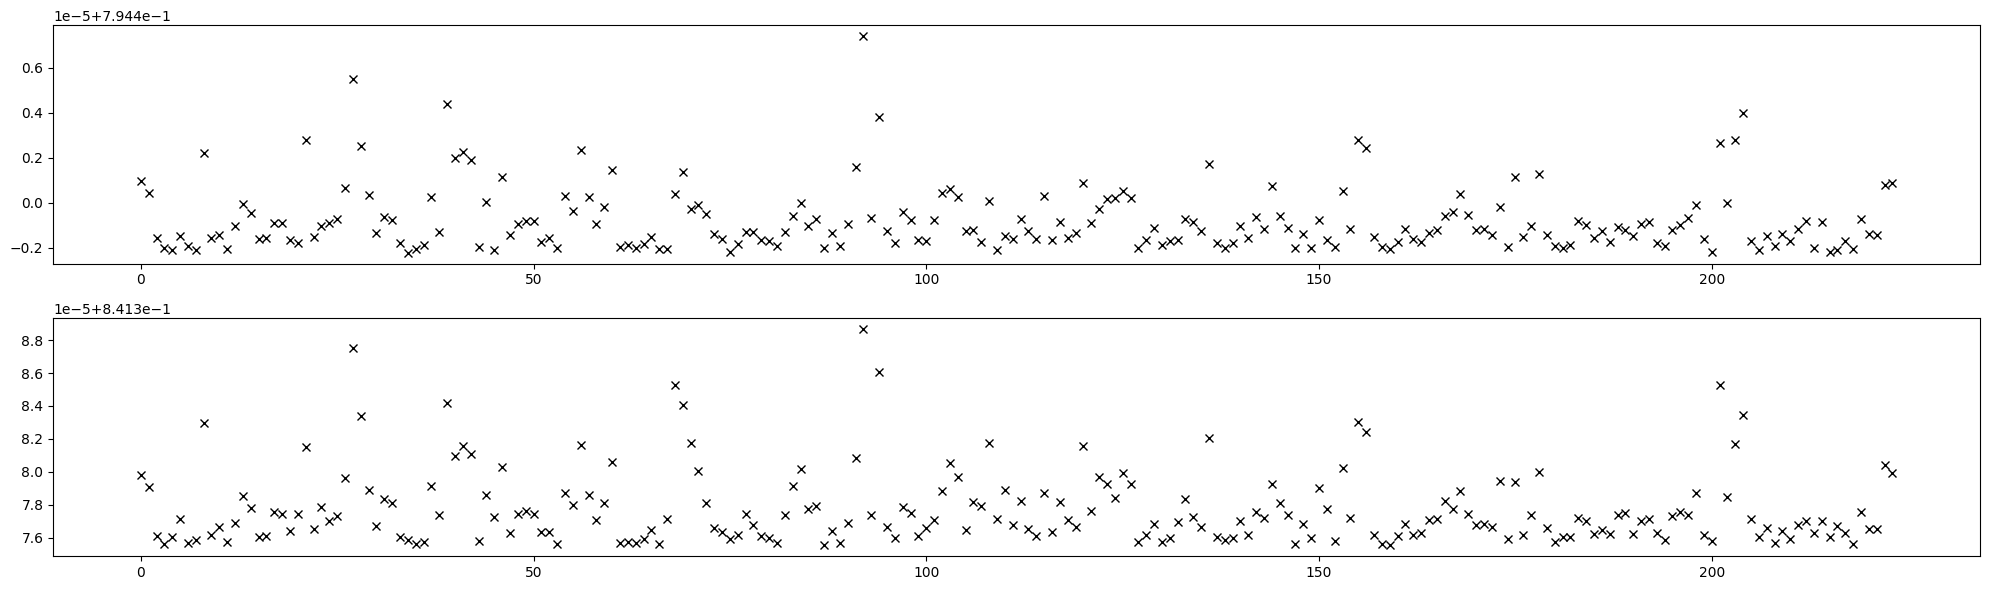

In [89]:
# Plot frequencies

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), value_nux.cpu().numpy(), fmt=' ', marker='x', color='black')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), value_nuy.cpu().numpy(), fmt=' ', marker='x', color='black')
plt.tight_layout()
plt.show()

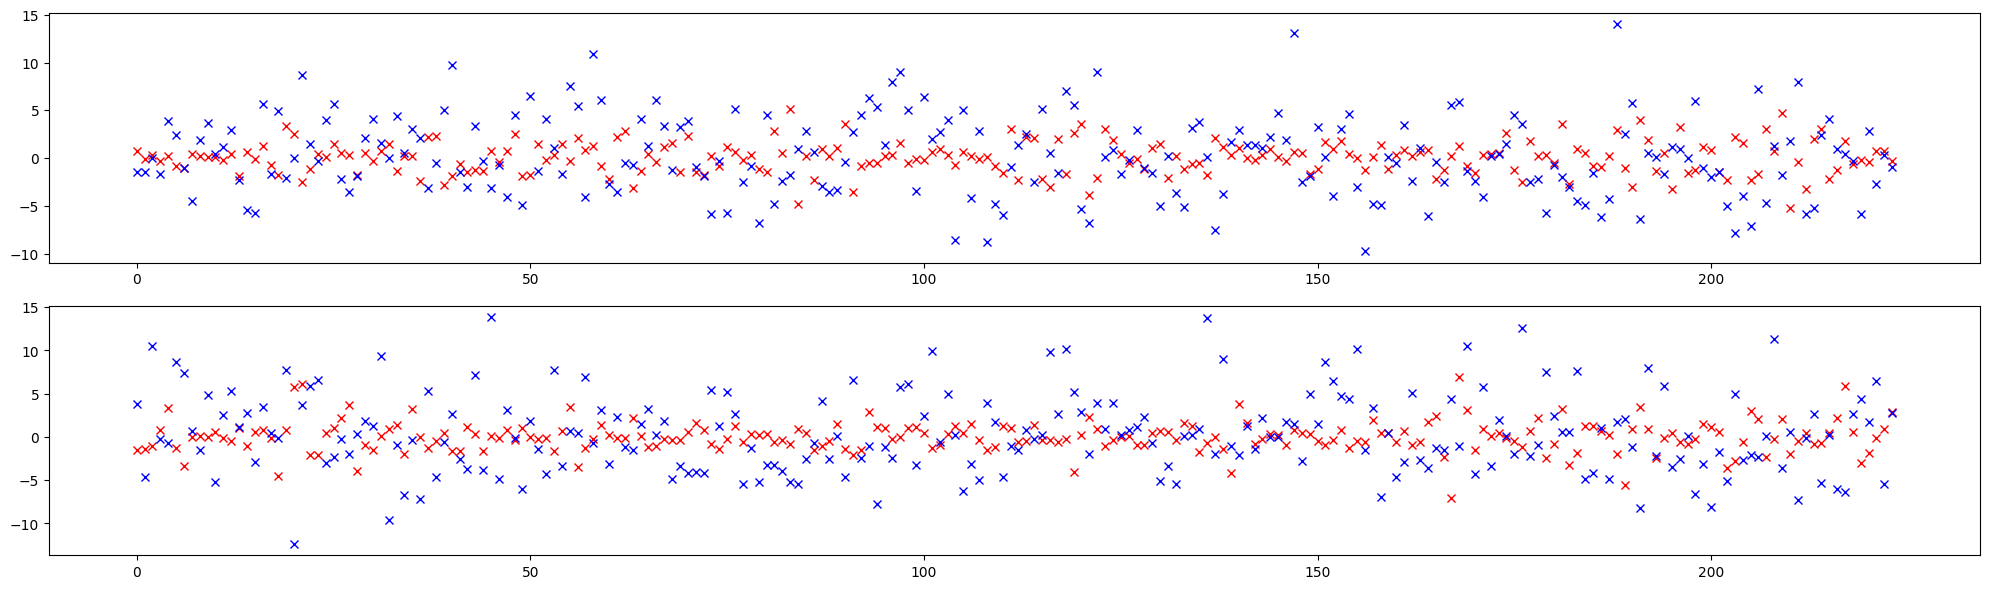

tensor(1.6834, dtype=torch.float64)
tensor(1.7897, dtype=torch.float64)

tensor(4.1914, dtype=torch.float64)
tensor(4.6449, dtype=torch.float64)



In [90]:
# Compare beta function values

plt.figure(figsize=(20, 3*2))
ax = plt.subplot(211)
ax.errorbar(range(model.monitor_count), 100*((value_bx - bx)/bx).cpu().numpy(), yerr=100/bx*error_bx.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((value_bx - bx_bpm)/bx_bpm).cpu().numpy(), yerr=100/bx_bpm*error_bx.cpu().numpy(), fmt=' ', marker='x', color='blue')
ax = plt.subplot(212)
ax.errorbar(range(model.monitor_count), 100*((value_by - by)/by).cpu().numpy(), yerr=100/by*error_by.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), 100*((value_by - by_bpm)/by_bpm).cpu().numpy(), yerr=100/by_bpm*error_by.cpu().numpy(), fmt=' ', marker='x', color='blue')
plt.tight_layout()
plt.show()

print(root_mean_square(100*((value_bx - bx)/bx)))
print(root_mean_square(100*((value_by - by)/by)))
print()

print(root_mean_square(100*((value_bx - bx_bpm)/bx_bpm)))
print(root_mean_square(100*((value_by - by_bpm)/by_bpm)))
print()

tensor(0.0259, dtype=torch.float64)
tensor(0.0591, dtype=torch.float64)

tensor(0.0199, dtype=torch.float64)
tensor(0.0430, dtype=torch.float64)

tensor(0.0141, dtype=torch.float64)
tensor(0.0415, dtype=torch.float64)

tensor(0.0175, dtype=torch.float64)
tensor(0.0355, dtype=torch.float64)

tensor(0.0051, dtype=torch.float64)
tensor(0.0091, dtype=torch.float64)

tensor(0.0071, dtype=torch.float64)
tensor(0.0123, dtype=torch.float64)

tensor(0.0030, dtype=torch.float64)
tensor(0.0045, dtype=torch.float64)

tensor(0.0038, dtype=torch.float64)
tensor(0.0086, dtype=torch.float64)



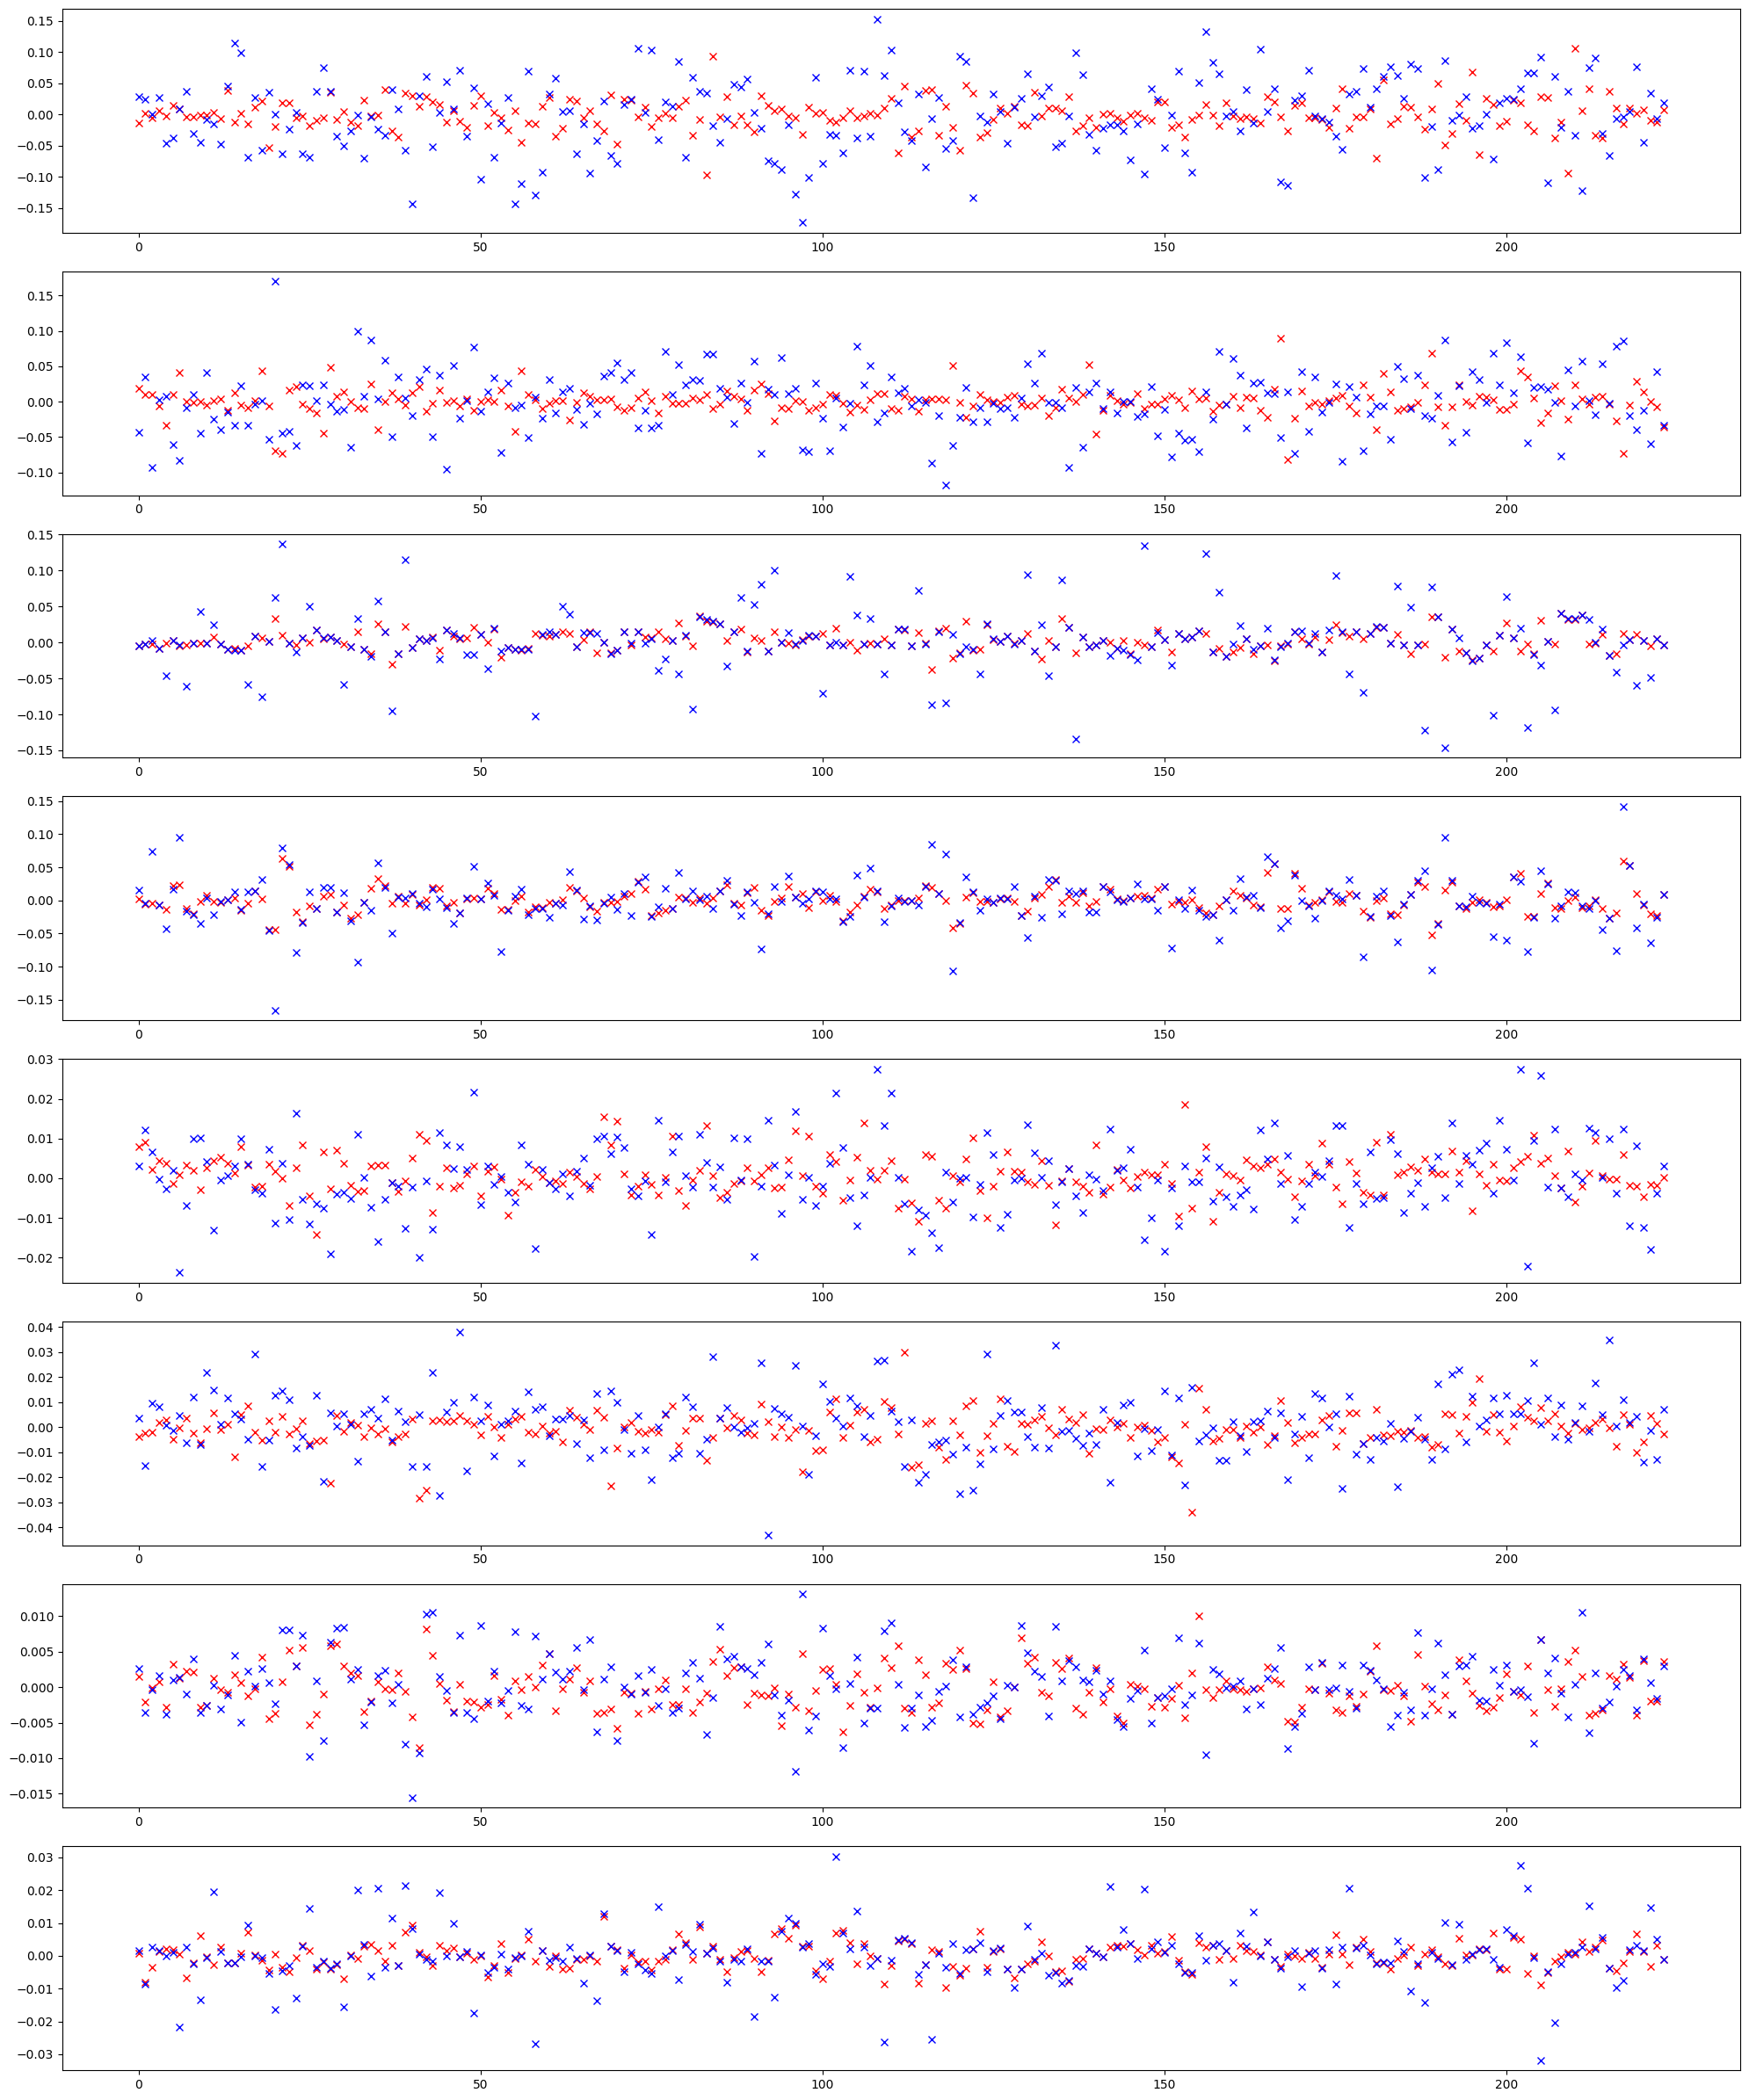

In [91]:
# Compare estimated normalization matrix elements

plt.figure(figsize=(20, 3*8))

ax = plt.subplot(811)
ax.errorbar(range(model.monitor_count), (n11 - value_n11).cpu().numpy(), yerr=error_n11.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n11_bpm - value_n11).cpu().numpy(), yerr=error_n11.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n11 - value_n11))
print(root_mean_square(n11_bpm - value_n11))
print()

ax = plt.subplot(812)
ax.errorbar(range(model.monitor_count), (n33 - value_n33).cpu().numpy(), yerr=error_n33.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n33_bpm - value_n33).cpu().numpy(), yerr=error_n33.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n33 - value_n33))
print(root_mean_square(n33_bpm - value_n33))
print()

ax = plt.subplot(813)
ax.errorbar(range(model.monitor_count), (n21 - value_n21).cpu().numpy(), yerr=error_n21.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n21_bpm - value_n21).cpu().numpy(), yerr=error_n21.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n21 - value_n21))
print(root_mean_square(n21_bpm - value_n21))
print()

ax = plt.subplot(814)
ax.errorbar(range(model.monitor_count), (n43 - value_n43).cpu().numpy(), yerr=error_n43.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n43_bpm - value_n43).cpu().numpy(), yerr=error_n43.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n43 - value_n43))
print(root_mean_square(n43_bpm - value_n43))
print()

ax = plt.subplot(815)
ax.errorbar(range(model.monitor_count), (n13 - value_n13).cpu().numpy(), yerr=error_n13.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n13_bpm - value_n13).cpu().numpy(), yerr=error_n13.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n13 - value_n13))
print(root_mean_square(n13_bpm - value_n13))
print()

ax = plt.subplot(816)
ax.errorbar(range(model.monitor_count), (n31 - value_n31).cpu().numpy(), yerr=error_n31.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n31_bpm - value_n31).cpu().numpy(), yerr=error_n31.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n31 - value_n31))
print(root_mean_square(n31_bpm - value_n31))
print()

ax = plt.subplot(817)
ax.errorbar(range(model.monitor_count), (n14 - value_n14).cpu().numpy(), yerr=error_n14.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n14_bpm - value_n14).cpu().numpy(), yerr=error_n14.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n14 - value_n14))
print(root_mean_square(n14_bpm - value_n14))
print()

ax = plt.subplot(818)
ax.errorbar(range(model.monitor_count), (n41 - value_n41).cpu().numpy(), yerr=error_n41.cpu().numpy(), fmt=' ', marker='x', color='red')
ax.errorbar(range(model.monitor_count), (n41_bpm - value_n41).cpu().numpy(), yerr=error_n41.cpu().numpy(), fmt=' ', marker='x', color='blue')
print(root_mean_square(n41 - value_n41))
print(root_mean_square(n41_bpm - value_n41))
print()

plt.tight_layout()
plt.show()

In [92]:
# Estimate momenta at each monitor location

orbit = []
for location in range(model.monitor_count):
    orbit.append(twiss.get_momenta_lstsq(1, 256, location, 2, model.matrix))
orbit = torch.stack(orbit)
print(orbit.shape)

torch.Size([224, 4, 256])


In [93]:
# Use measured twiss to estimate invariants

s11, s33, s21, s43, s13, s31, s14, s41 = value.T
e11, e33, e21, e43, e13, e31, e14, e41 = error.T

BAG_IX = []
BAG_IY = []

for location in range(model.monitor_count):
    
    BAG_IX_MONITOR = []
    BAG_IY_MONITOR = []
    
    for _ in range(128):
        
        m11 = s11[location] + e11[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m33 = s33[location] + e33[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m21 = s21[location] + e21[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m43 = s43[location] + e43[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m13 = s13[location] + e13[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m31 = s31[location] + e31[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m14 = s14[location] + e14[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        m41 = s41[location] + e41[location]*torch.randn(1, dtype=dtype, device=device).squeeze()
        
        normal = parametric_normal(m11, m33, m21, m43, m13, m31, m14, m41)
        
        QX, PX, QY, PY = normal.inverse() @ orbit[location]
        IX, IY = 0.5*(QX**2 + PX**2), 0.5*(QY**2 + PY**2)
        
        BAG_IX_MONITOR.append(IX)
        BAG_IY_MONITOR.append(IY)
        
    BAG_IX.append(BAG_IX_MONITOR)
    BAG_IY.append(BAG_IY_MONITOR)

BAG_IX = torch.stack([torch.stack(IX) for IX in BAG_IX]).reshape(model.monitor_count, -1)
BAG_IY = torch.stack([torch.stack(IY) for IY in BAG_IY]).reshape(model.monitor_count, -1)

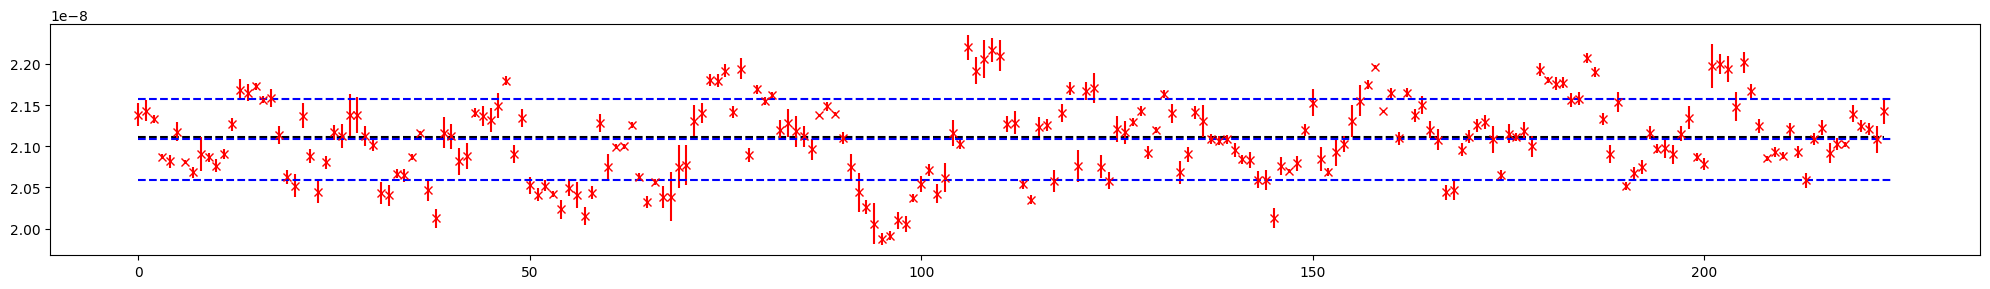

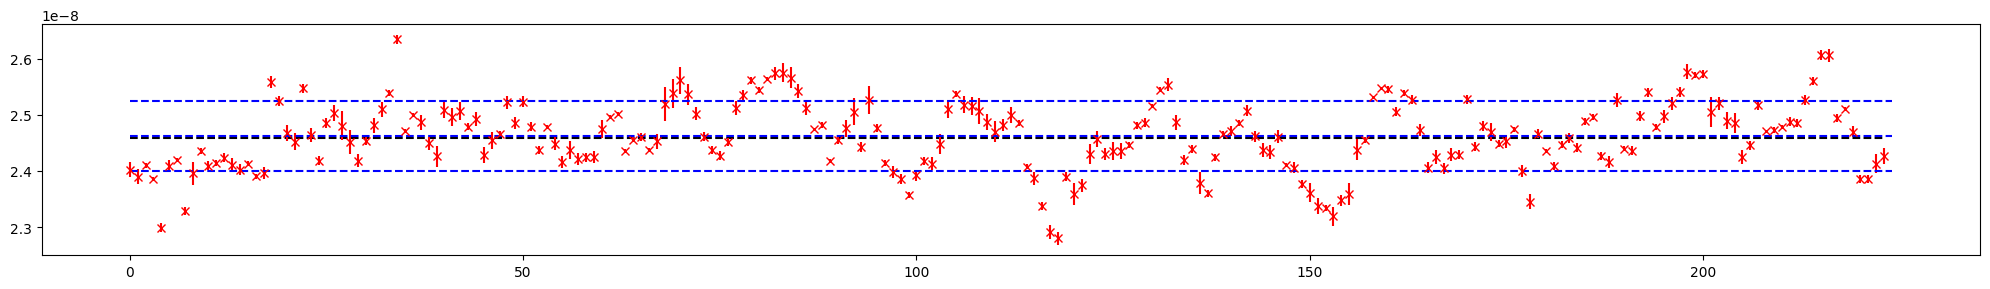

tensor(2.1113e-08, dtype=torch.float64)
tensor(2.1085e-08, dtype=torch.float64)

tensor(2.4590e-08, dtype=torch.float64)
tensor(2.4615e-08, dtype=torch.float64)



In [94]:
# Plot invariants for each monitor

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), BAG_IX.mean(-1).flatten().cpu().numpy(), yerr=BAG_IX.std(-1).cpu().numpy(), fmt=' ', color='red', marker='x')

plt.hlines(ix.mean(), 0, model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.hlines([BAG_IX.mean() - BAG_IX.std(), BAG_IX.mean(), BAG_IX.mean() + BAG_IX.std()], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(model.monitor_count), BAG_IY.mean(-1).flatten().cpu().numpy(), yerr=BAG_IY.std(-1).cpu().numpy(), fmt=' ', color='red', marker='x')
plt.hlines(iy.mean(), 0, model.monitor_count - 1, linestyles='dashed', color='black',  zorder=1)
plt.hlines([BAG_IY.mean() - BAG_IY.std(), BAG_IY.mean(), BAG_IY.mean() + BAG_IY.std()], 0, model.monitor_count, linestyles='dashed', color='blue')
plt.tight_layout()
plt.show()

print(ix.mean())
print(BAG_IX.mean())
print()

print(iy.mean())
print(BAG_IY.mean())
print()